In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import polars as pl
import polars.selectors as selectors

from src.config import RAW_TRAIN_DATA_DIR, TARGET_PATH, USED_DATASET_PATH

In [3]:
data_lazy = (
    pl.scan_parquet(RAW_TRAIN_DATA_DIR)
    .with_columns(
        selectors.integer().exclude("id").cast(pl.Int16),
        pl.col("id").cast(pl.Int32),
        selectors.float().cast(pl.Float16),
    )
)

target_lazy = pl.scan_csv(
    TARGET_PATH,
    schema_overrides={"id": pl.Int32, "flag": pl.Int8},
)

data = (
    data_lazy
    .join(target_lazy, on="id", how="inner")
    .collect(engine="streaming")
    .sample(n=2_000_000, seed=0)
)

In [4]:
data = data.drop(["pre_fterm", "pre_till_fclose", "fclose_flag"])

- `pre_fterm`: True duration. Known only if the loan is already closed → leakage.
- `pre_till_fclose`:Remaining days until the true end. Needs to know the real closure date → leakage.
- `fclose_flag`: Indicates if the loan is already closed at the collect.

**Decision:** Drop those columns

In [5]:
data.write_parquet(USED_DATASET_PATH)

# EXPLORATORY DATA ANALYSIS

## OVERVIEW

- target: `flag`

Shape: 2 000 000, 62

In [6]:
data.shape

(2000000, 59)

## Description

In [7]:
data.describe()

statistic,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6,2e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.5462e6,7.0497905,9.358704,8.2201555,8.36446,7.1427585,9.677454,2.3634465,2.995944,0.0,2.0052675,4.6173375,5.974592,15.871778,5.0012745,3.999829,8.003332,0.9186135,0.8325055,0.957608,0.975644,0.9761225,13.828107,2.2119295,15.688263,0.6976525,0.930224,0.855924,0.164635,0.379871,0.519077,0.64898,0.781672,0.913411,1.0735825,1.227999,1.341933,1.4506205,1.5785725,2.7084055,1.842588,1.964624,2.0278635,2.0774675,2.1219225,2.163728,2.208685,2.2491835,3.283821,2.3157565,2.3476845,2.381234,3.529625,1.034228,2.692749,3.5182415,1.0017735,0.148961,0.033592
"""std""",867761.890883,5.396257,5.776004,4.713354,5.325169,5.152641,5.825352,1.309991,0.711036,0.0,0.282124,3.310172,0.387458,1.182279,0.073136,0.022538,0.148603,0.273428,0.373417,0.201482,0.154152,0.152668,4.386573,0.860547,3.980111,0.459275,0.254769,0.351167,0.630008,0.932826,1.084277,1.19156,1.278448,1.346732,1.408458,1.448326,1.466966,1.476663,1.477578,1.466983,1.443433,1.410108,1.388391,1.369115,1.350209,1.330897,1.308162,1.286009,1.265845,1.246103,1.225213,1.202184,1.081171,0.305029,0.499751,1.038695,0.04941,0.35605,0.180177
"""min""",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",796631.0,3.0,4.0,4.0,4.0,2.0,5.0,2.0,3.0,0.0,2.0,2.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,15.0,2.0,17.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,3.0,3.0,3.0,4.0,1.0,2.0,3.0,1.0,0.0,0.0
"""50%""",1.569234e6,6.0,9.0,9.0,8.0,7.0,10.0,2.0,3.0,0.0,2.0,4.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""75%""",2.304109e6,10.0,14.0,12.0,14.0,12.0,15.0,2.0,3.0,0.0,2.0,7.0,6.0,16.0,5.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,16.0,2.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
"""max""",2.999999e6,49.0,19.0,17.0,17.0,16.0,19.0,6.0,5.0,0.0,3.0,13.0,16.0,19.0,9.0,4.0,19.0,1.0,1.0,1.0,1.0,1.0,19.0,19.0,19.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,6.0,6.0,7.0,3.0,1.0,1.0


In [8]:
data.glimpse()

Rows: 2000000
Columns: 59
$ id                            <i32> 514515, 719549, 540373, 141438, 1013450, 34326, 2316970, 2044705, 2871864, 219114
$ rn                            <i16> 9, 8, 12, 11, 3, 13, 3, 1, 9, 23
$ pre_since_opened              <i16> 19, 17, 19, 1, 0, 5, 6, 10, 9, 12
$ pre_since_confirmed           <i16> 9, 13, 9, 9, 10, 9, 14, 4, 5, 0
$ pre_pterm                     <i16> 4, 16, 4, 2, 0, 4, 6, 6, 7, 8
$ pre_till_pclose               <i16> 1, 11, 1, 12, 12, 1, 0, 0, 2, 1
$ pre_loans_credit_limit        <i16> 6, 1, 14, 8, 11, 15, 14, 13, 6, 19
$ pre_loans_next_pay_summ       <i16> 1, 2, 5, 4, 0, 5, 2, 2, 2, 2
$ pre_loans_outstanding         <i16> 3, 3, 4, 2, 5, 2, 3, 3, 3, 3
$ pre_loans_total_overdue       <i16> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ pre_loans_max_overdue_sum     <i16> 2, 2, 2, 2, 2, 1, 2, 2, 2, 2
$ pre_loans_credit_cost_rate    <i16> 1, 2, 5, 0, 7, 5, 2, 2, 4, 4
$ pre_loans5                    <i16> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6
$ pre_loans530              

## Target distribution
- 0: 96.637%
- 1: 3.363%

In [9]:
target_dist = data.select(
    [
        (pl.col("flag").eq(0).sum() / pl.col("flag").len()).alias("0 flag"),
        (pl.col("flag").eq(1).sum() / pl.col("flag").len()).alias("1 flag"),
    ]
)

target_dist

0 flag,1 flag
f64,f64
0.966408,0.033592


## Missing value

No missing values

In [10]:
missing_dataset = data.select(
    (pl.all().exclude(["id", "flag"]).is_nan().sum() / len(data))
)
missing_dataset

rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data visualization

In [11]:
categorical_features = [f"enc_paym_{i}" for i in range(25)]
categorical_features.extend(
    [
        "is_zero_loans5",
        "is_zero_loans530",
        "is_zero_loans3060",
        "is_zero_loans6090",
        "is_zero_loans90",
        "is_zero_util",
        "is_zero_over2limit",
        "is_zero_maxover2limit",
        "enc_loans_account_holder_type",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "enc_loans_account_cur",
        "pclose_flag",
    ]
)

In [12]:
numerical_features = [
    "rn",
    "pre_since_opened",
    "pre_since_confirmed",
    "pre_pterm",
    "pre_till_pclose",
    "pre_loans_credit_limit",
    "pre_loans_next_pay_summ",
    "pre_loans_outstanding",
    "pre_loans_total_overdue",
    "pre_loans_max_overdue_sum",
    "pre_loans_credit_cost_rate"
]

In [13]:
def feature_distribution(df: pd.DataFrame, features: list, categorical: bool):
    df = df.select(
        pl.col(features)
    ).to_pandas()

    if categorical:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.countplot(data=df, x=feature)
            plt.xticks(rotation=45)
            plt.show()
    else:
        for feature in features:
            plt.figure(figsize=(10, 5))
            plt.title(feature)
            sb.histplot(df[feature], kde=True)
            plt.show()


### Numerical features
- The `rn` seems show me that the more the loan is older the more we have customers
- the `pre_since_confirmed` seems have a main value
- `pre_pterm`: has 2 main values (maybe the client prefer theses durations?)
- `pre_till_pclose`: most customers seem closed her loan at a certain time before the planed closure
- `pre_till_fclose`: has also a main value occurences
- `pre_loans_credit_cost_rate`: 2 main values occur
- `pre_loans_next_pay_summ` and `pre_loans_outstanding`, `pre_loans_total_overdue` seem constraint between a few values(Is it normal or another thing?)
- `pre_loans_credit_cost_rate`: has 2 predominant values
- `pre_loans_max_overdue_sum` is not pertinent we must have to drop it

**Observations:** Some features seem restraint in a few values. If it's a standard we can try to convert it into categorical value, and it seems have a lot of outlier. We can have to manage that(winsorizer or robustscaler).

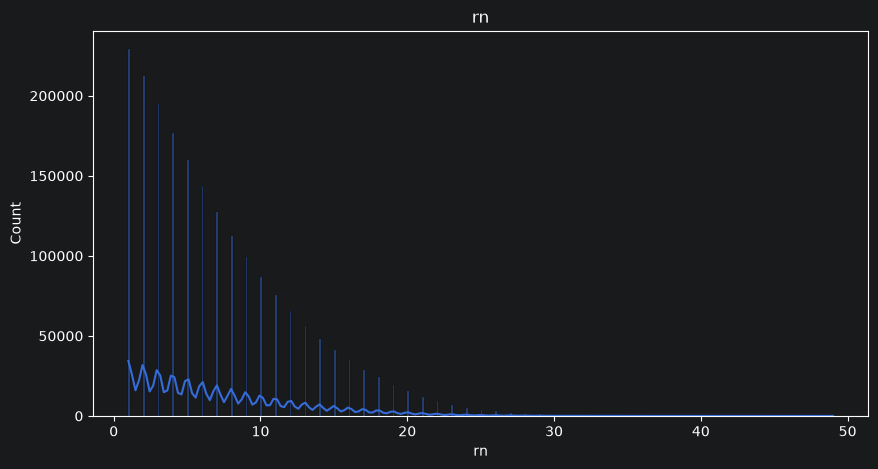

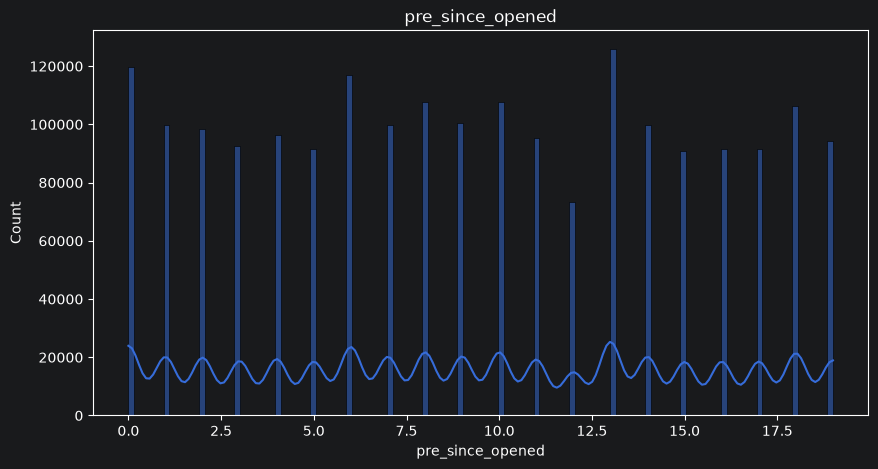

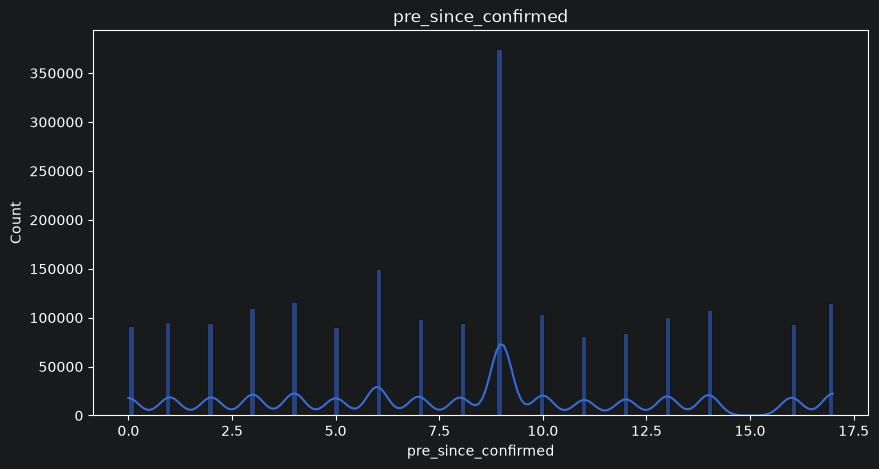

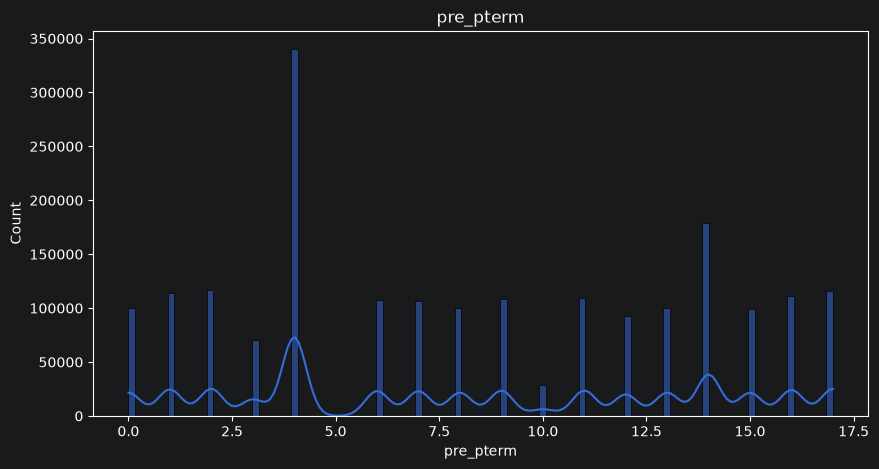

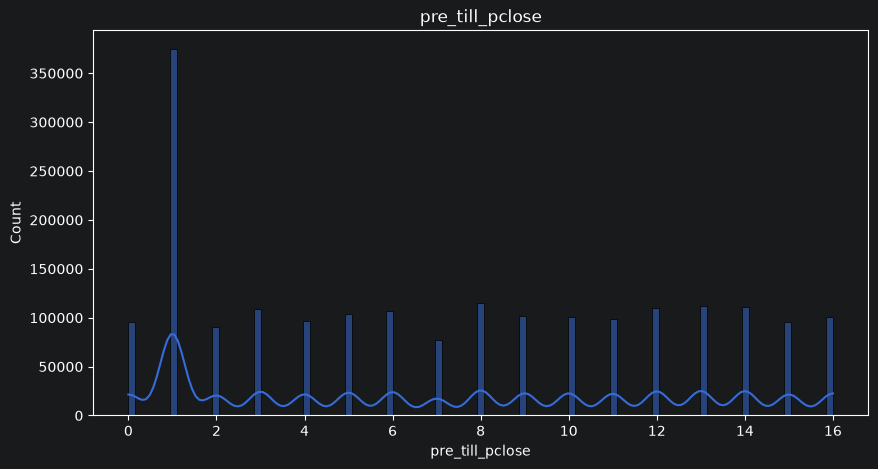

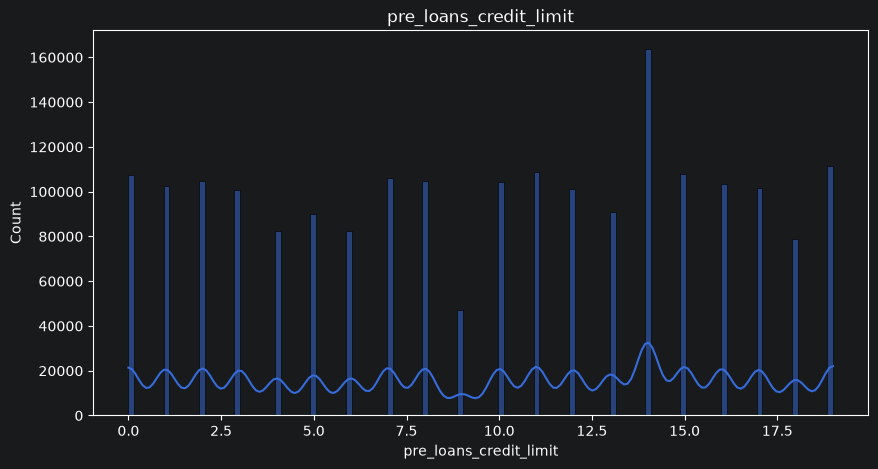

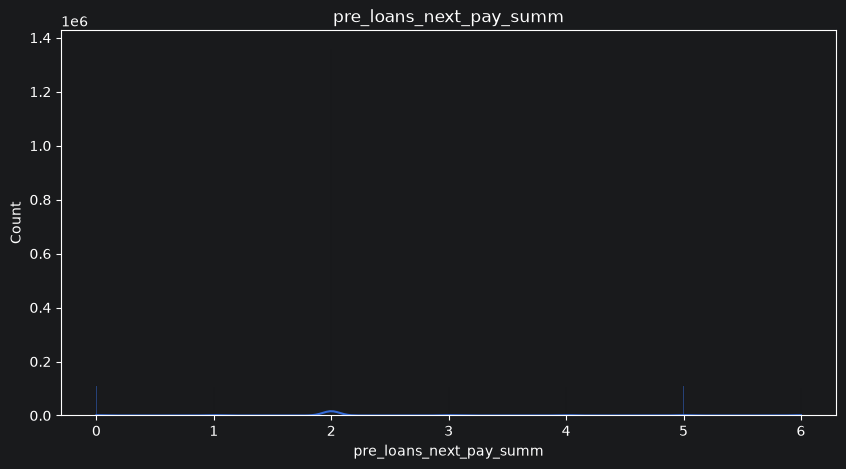

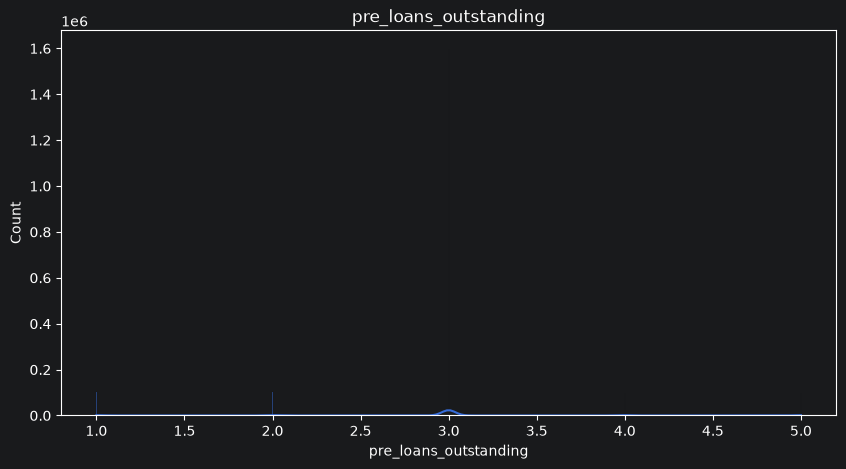

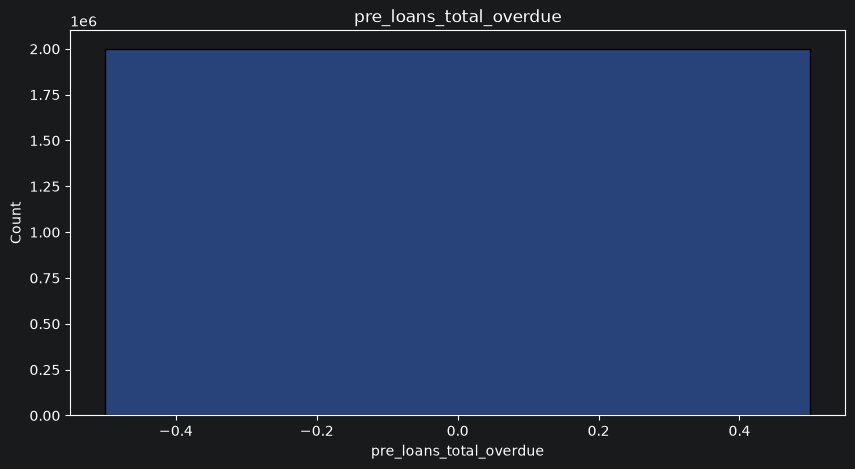

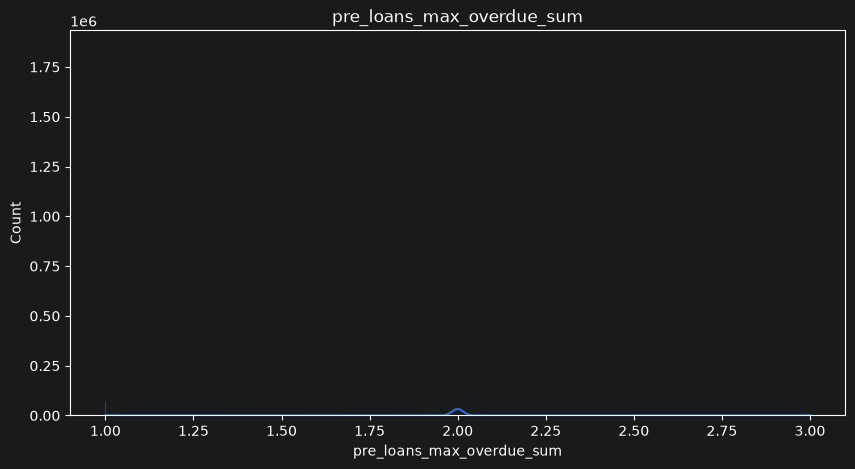

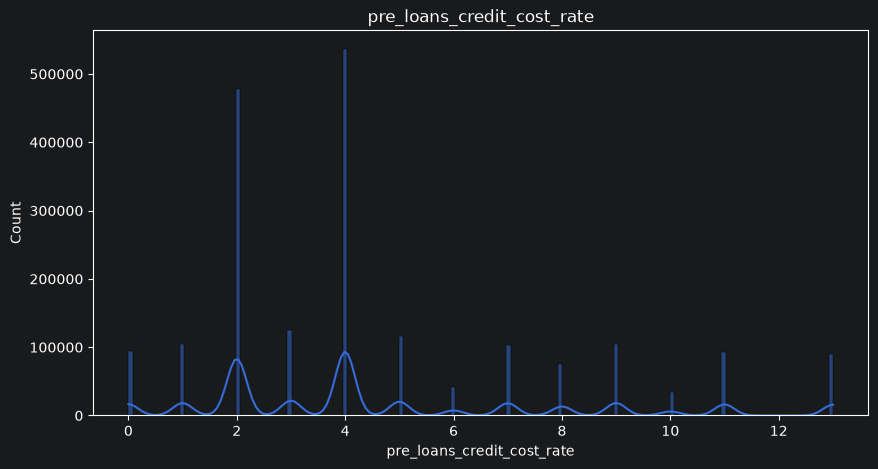

In [14]:
feature_distribution(df= data, features=numerical_features, categorical=False)

### Categorical features

Most of data are very imbalanced

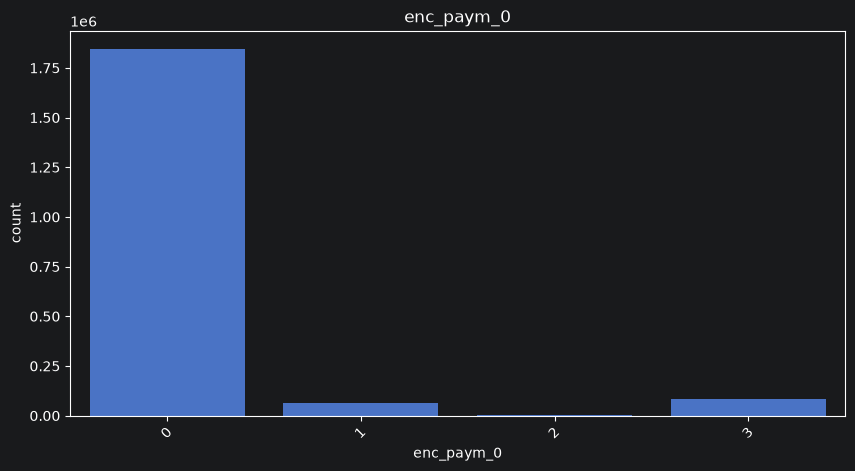

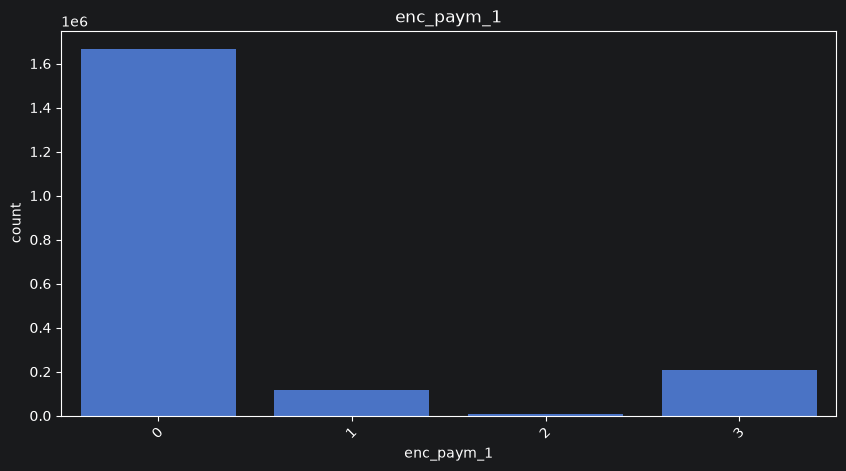

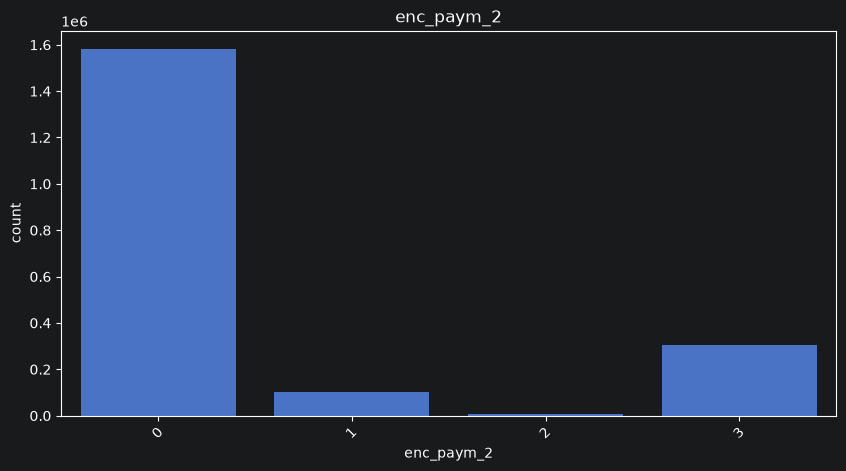

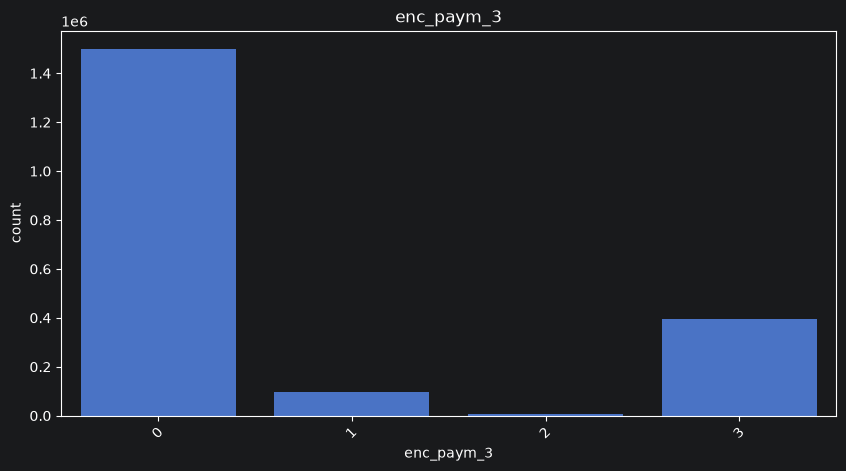

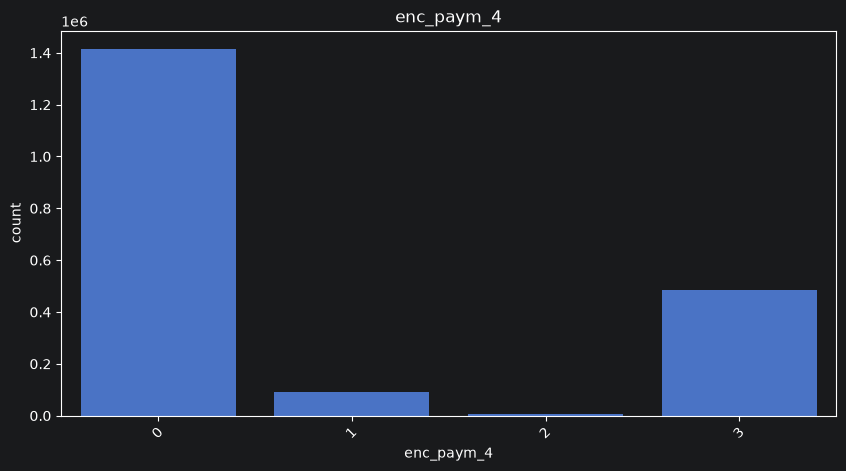

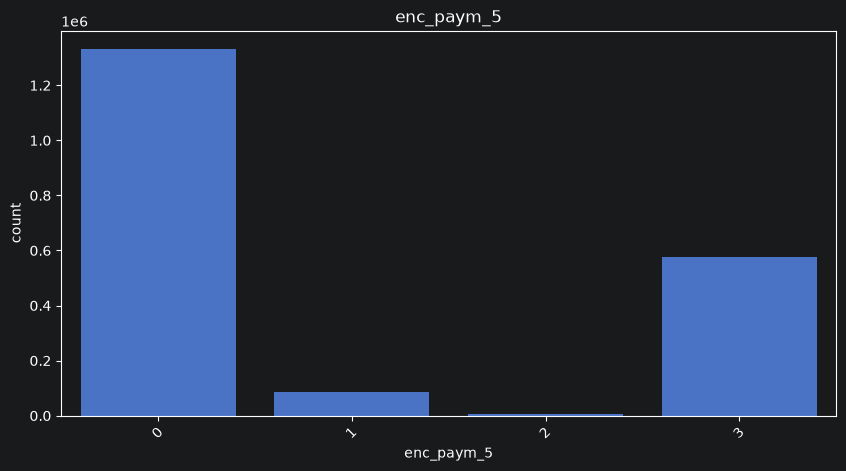

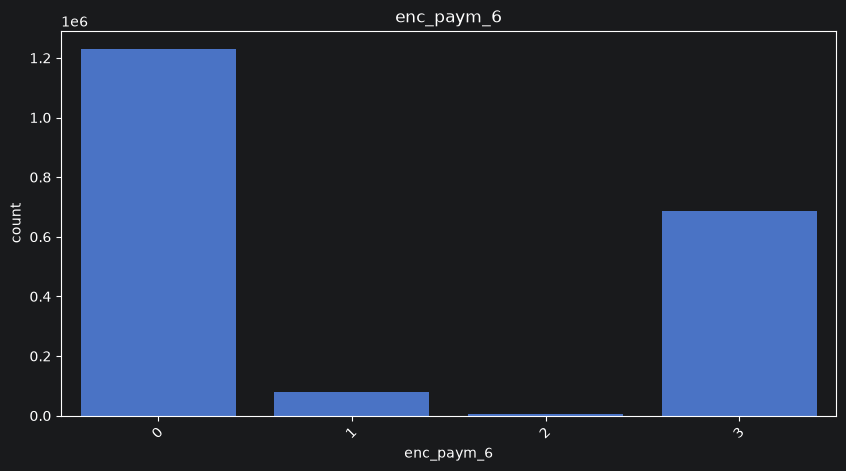

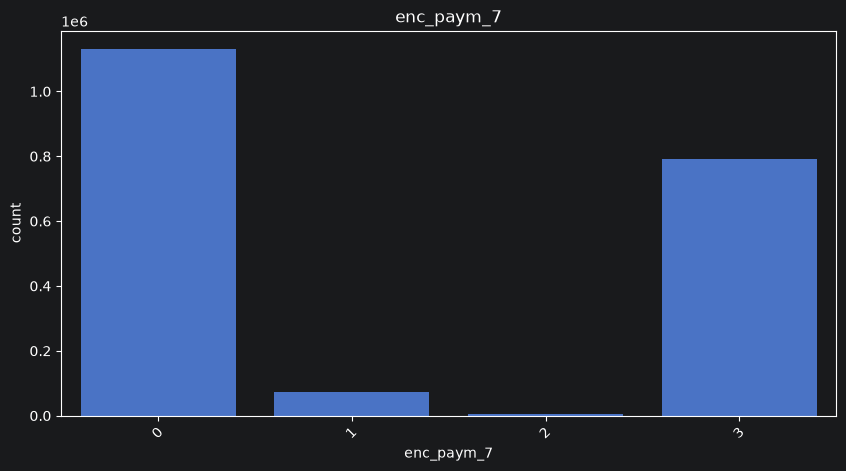

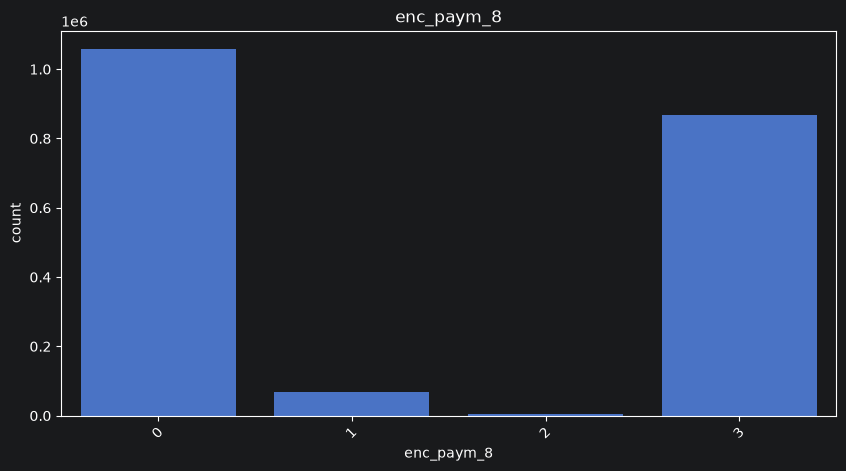

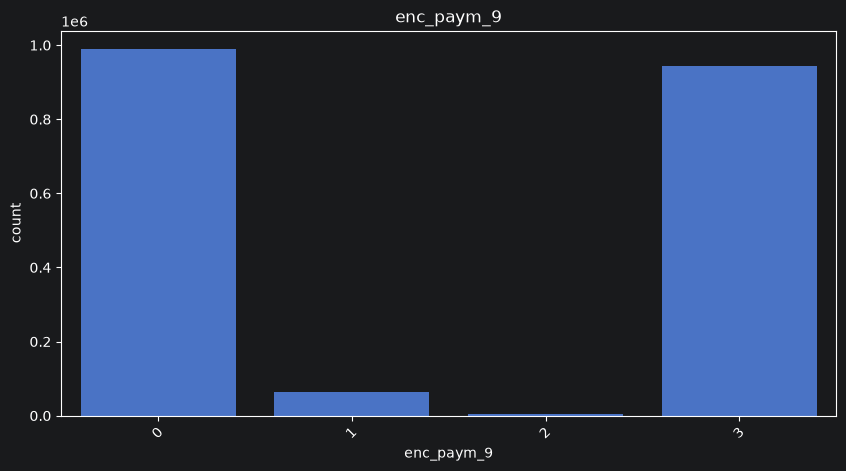

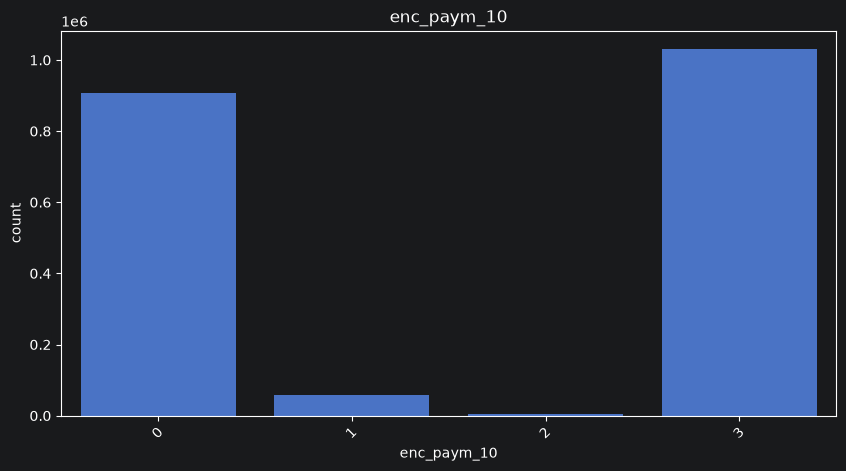

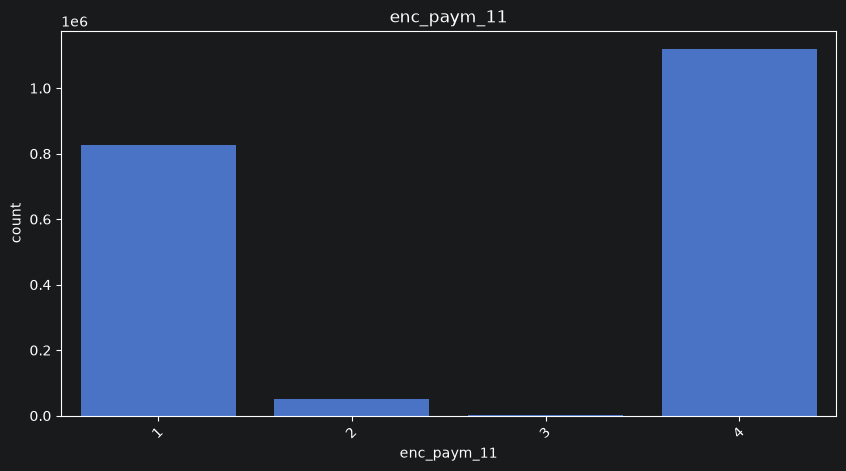

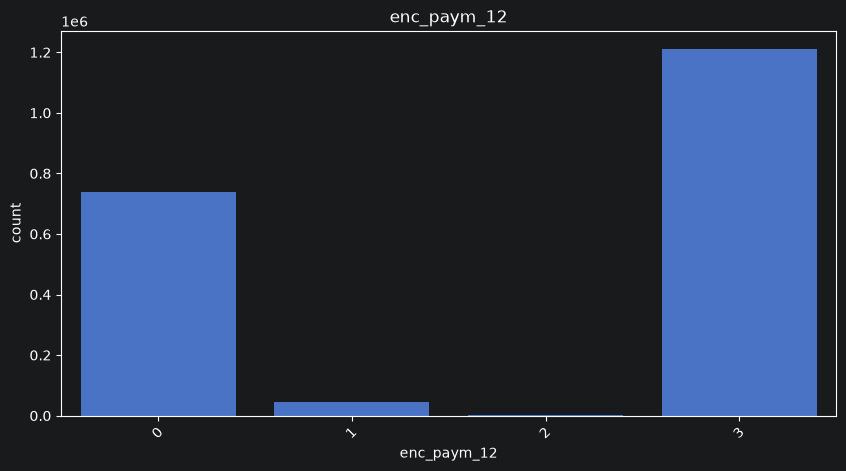

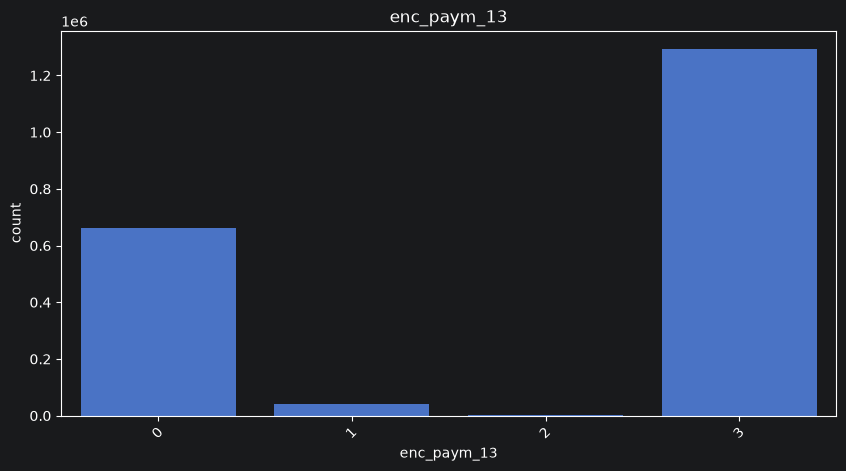

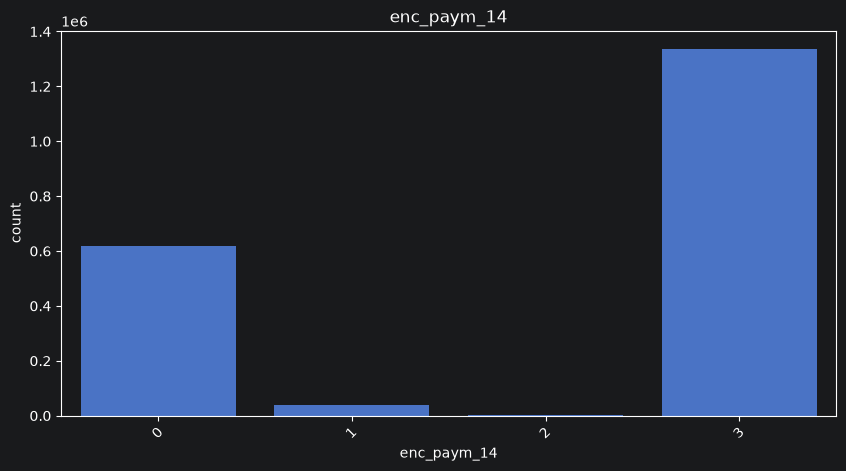

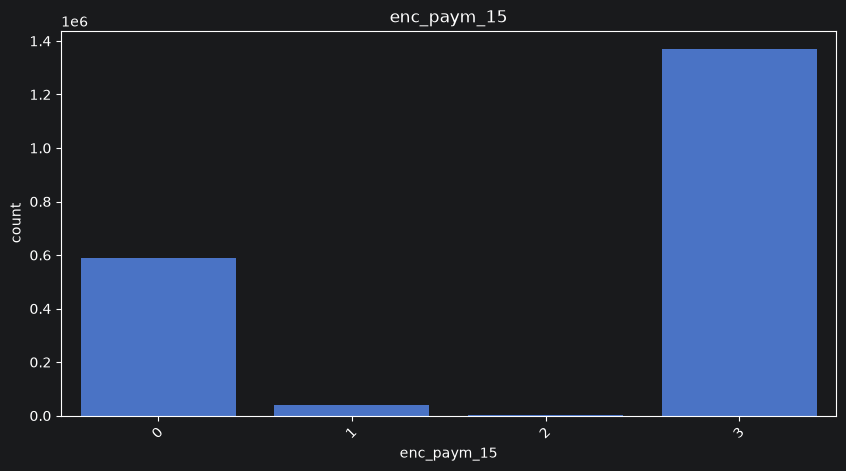

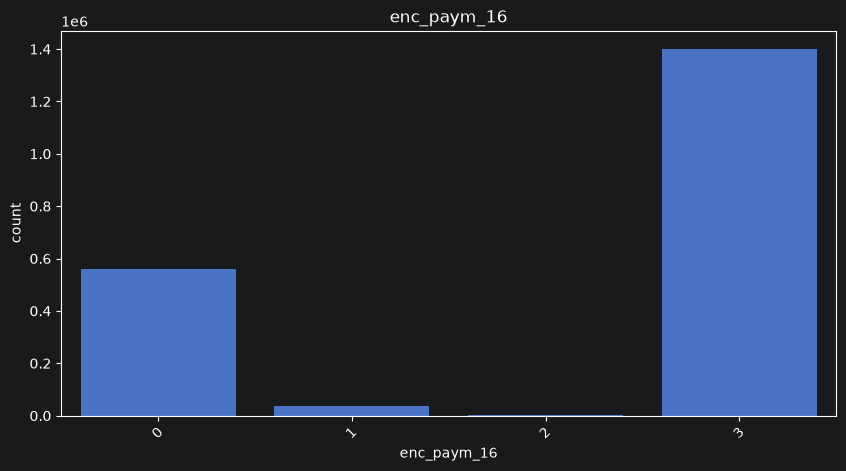

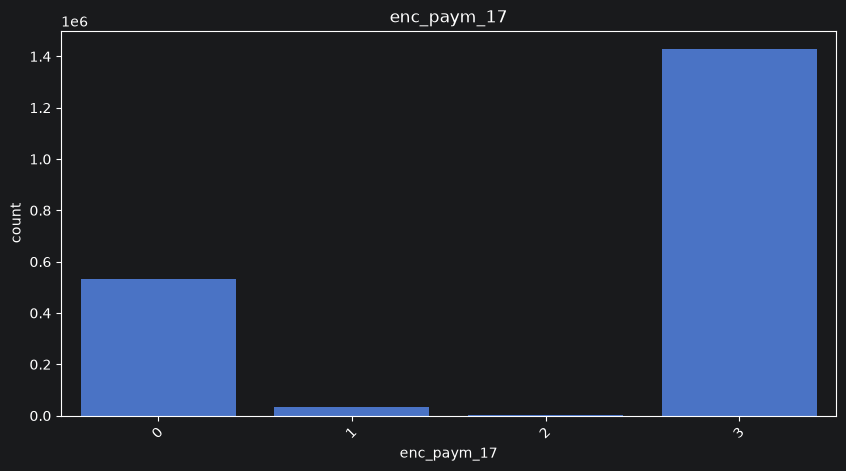

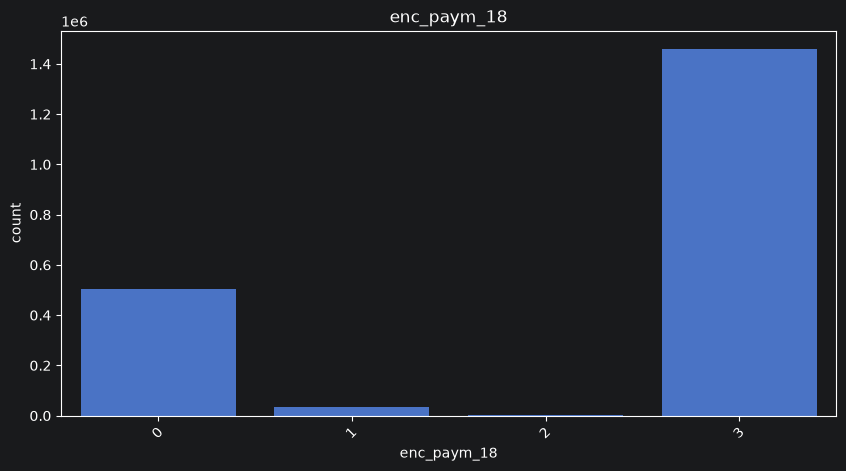

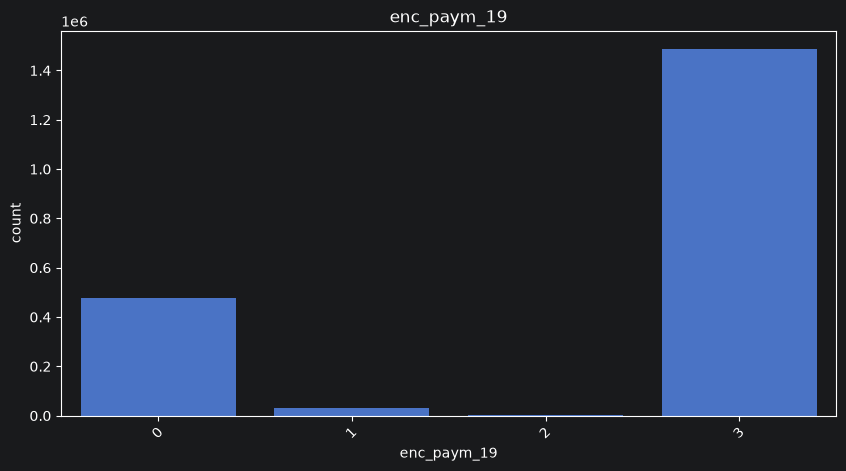

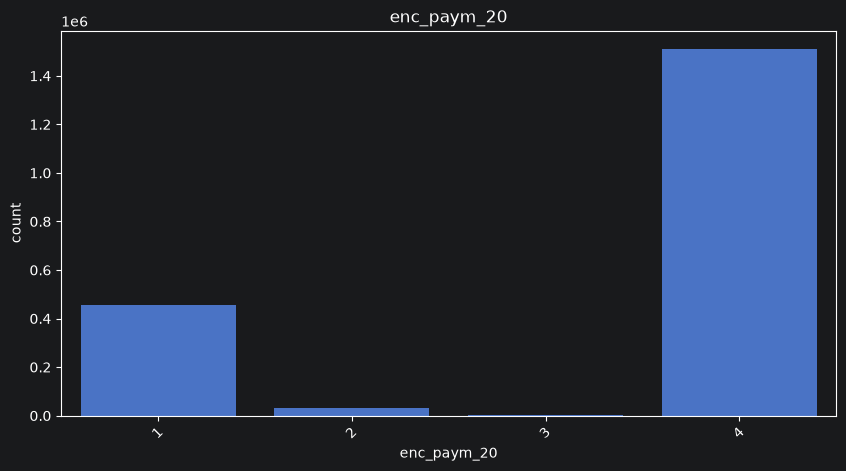

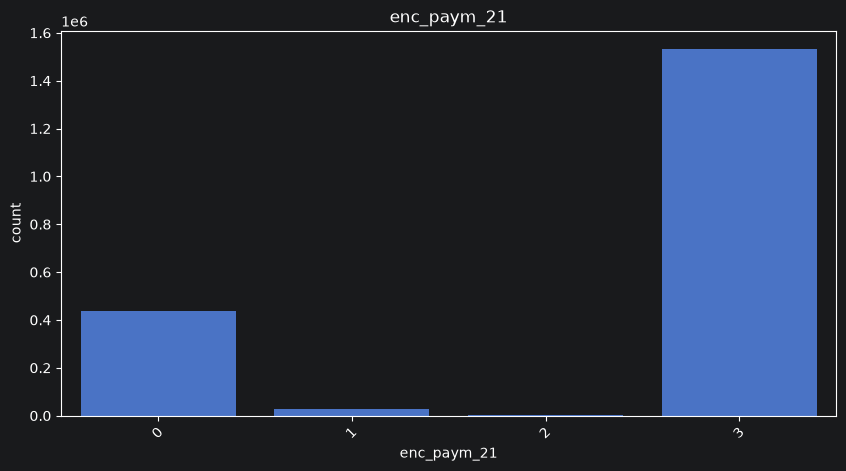

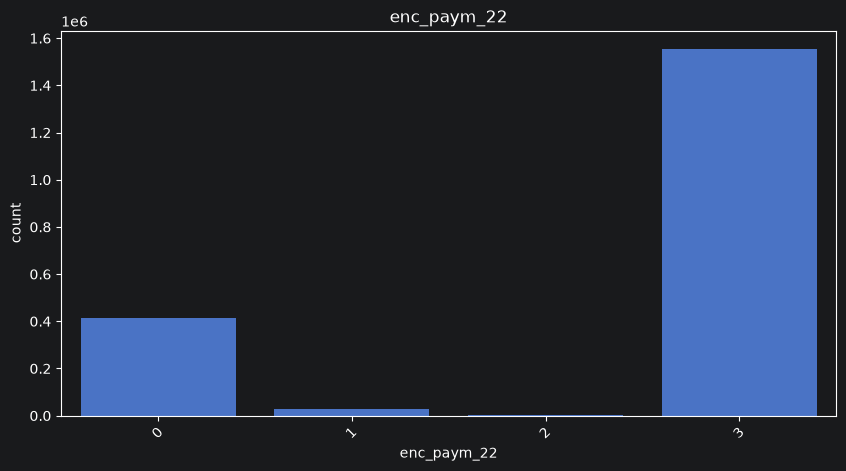

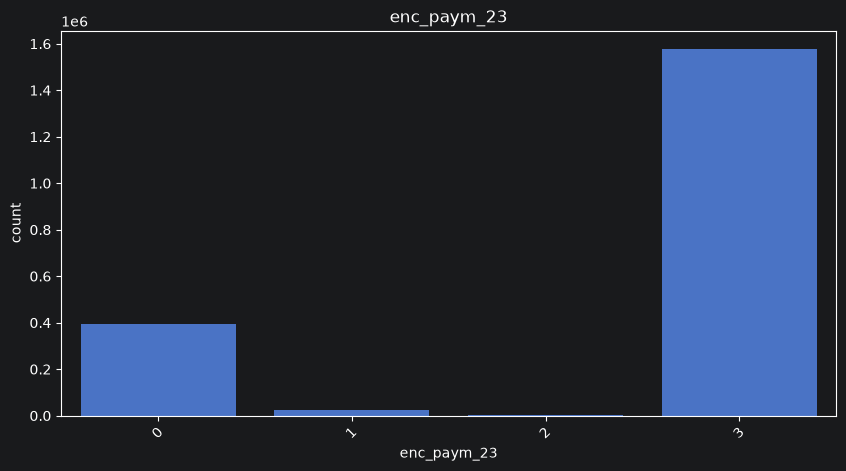

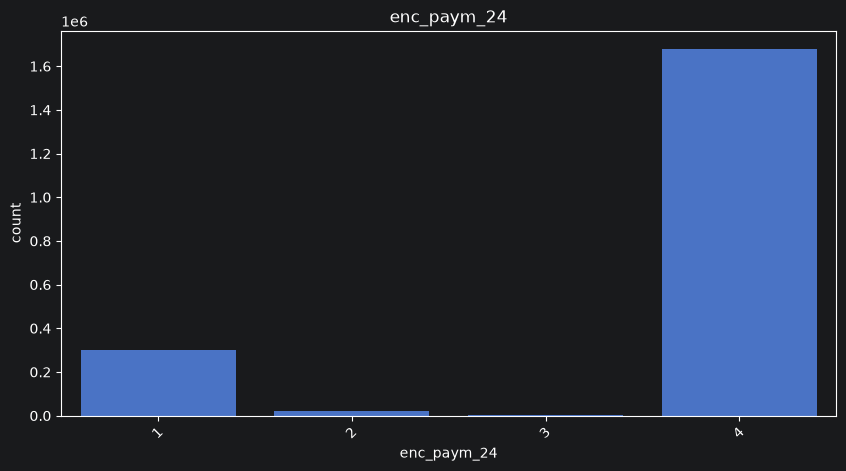

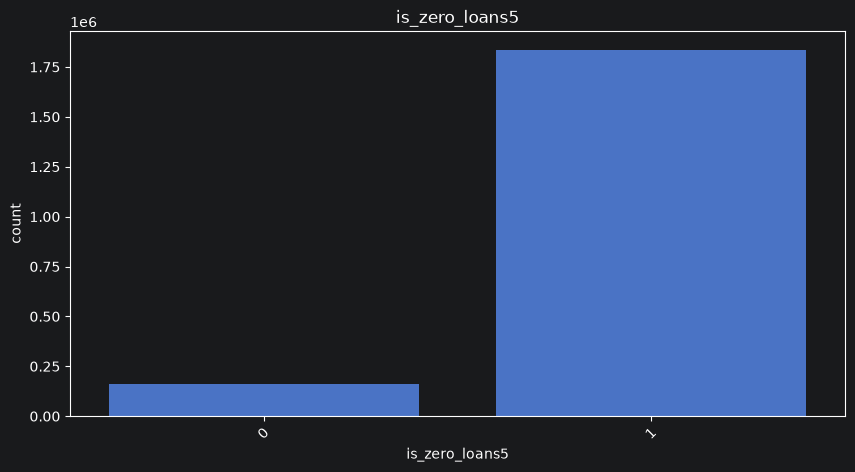

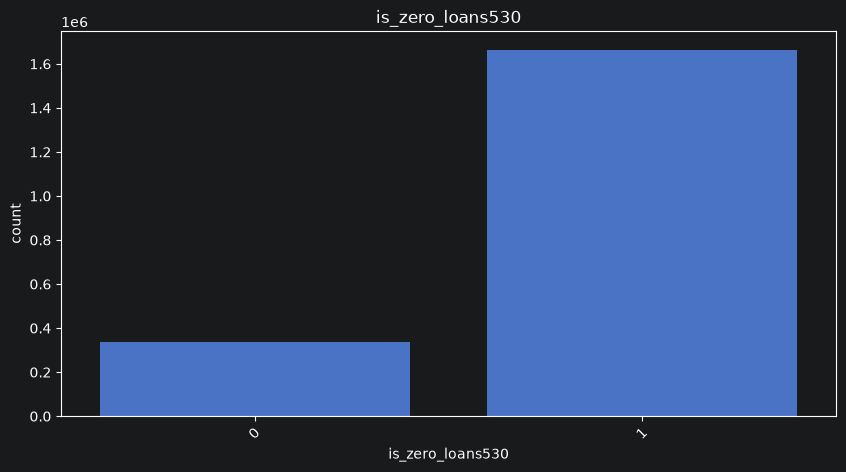

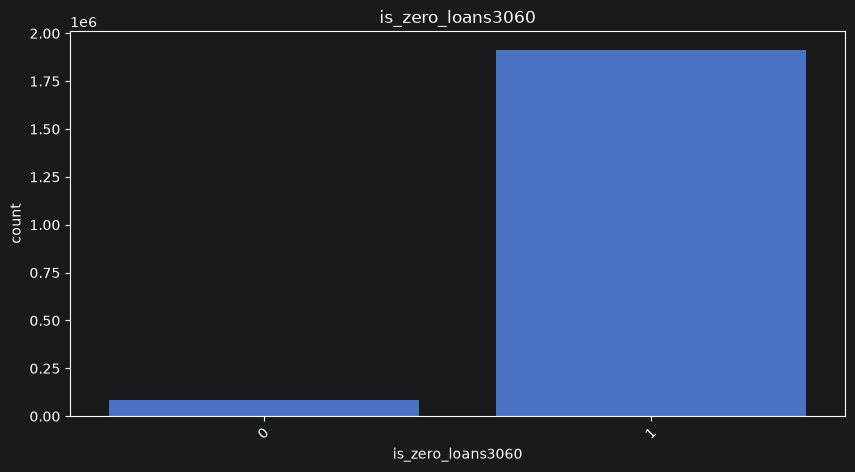

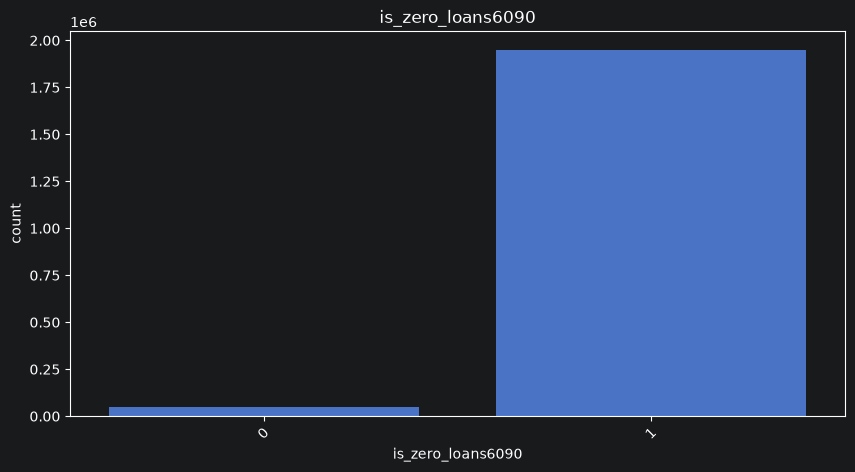

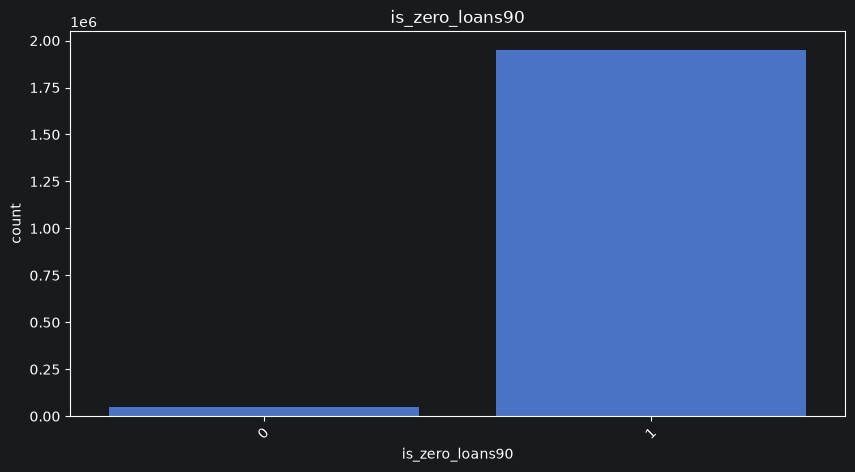

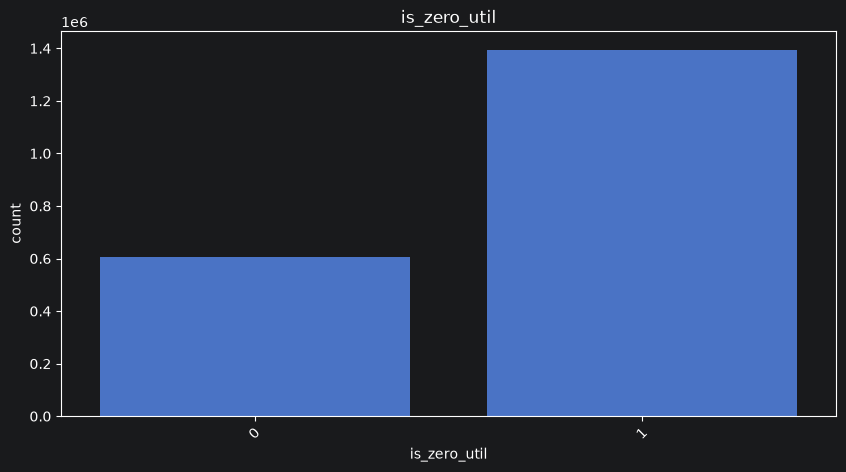

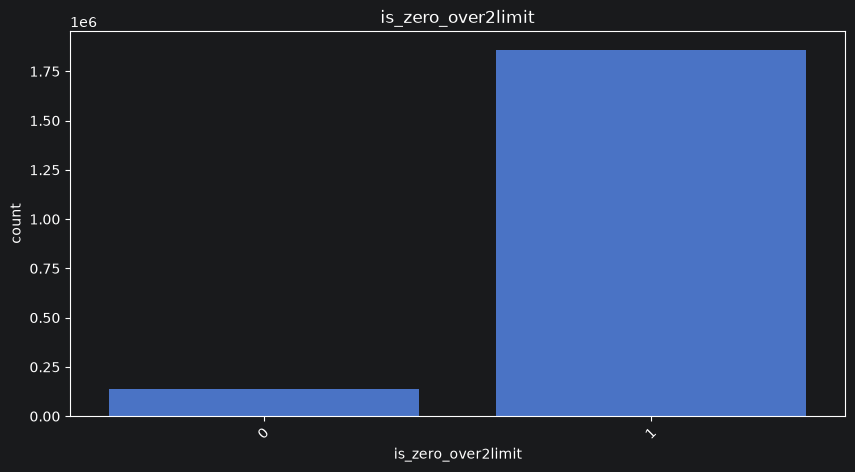

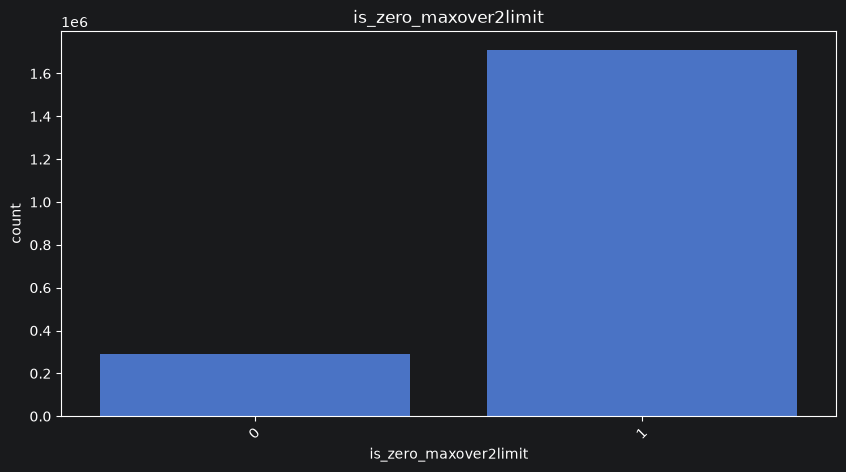

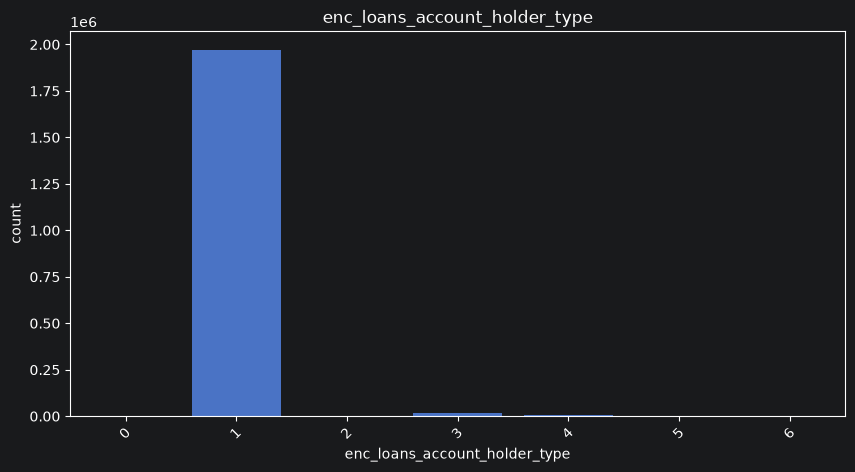

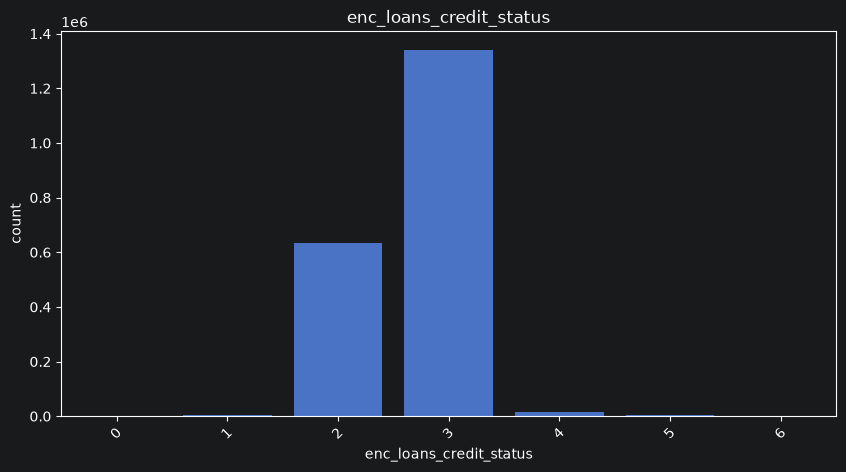

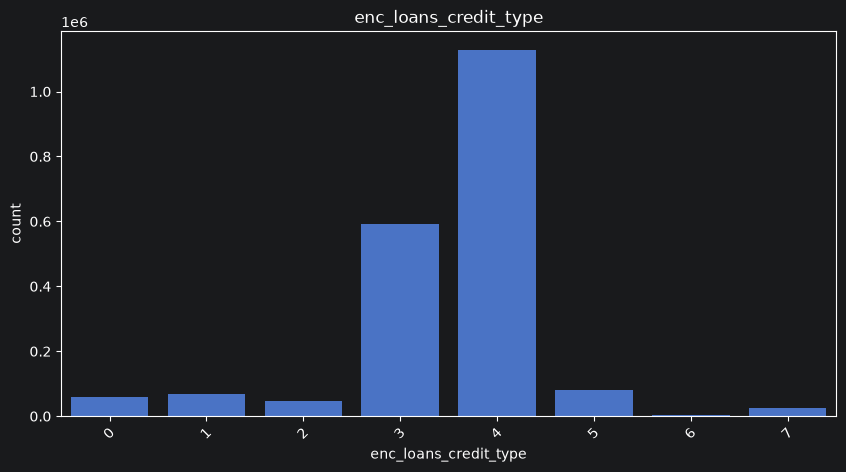

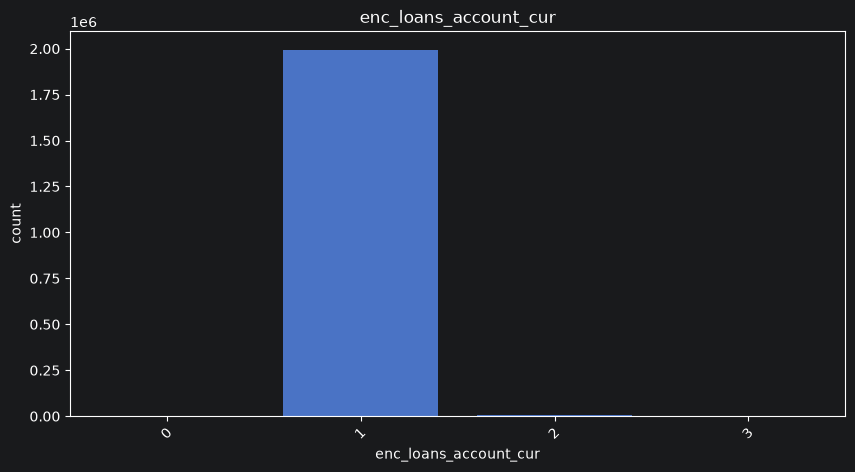

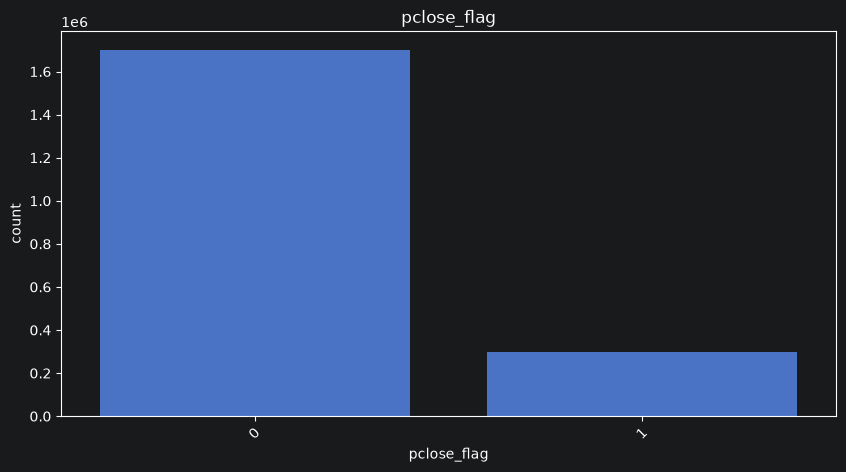

In [15]:
feature_distribution(df=data, features=categorical_features, categorical=True)

### Relations features / target

In [16]:
categorical_features = categorical_features + [ "pre_loans_next_pay_summ", "pre_loans_outstanding", "pre_loans_total_overdue"]
numerical_features.remove("pre_loans_next_pay_summ")
numerical_features.remove("pre_loans_outstanding")
numerical_features.remove("pre_loans_total_overdue")

In [17]:
def plot_relation_feature_target(df: pl.DataFrame, categorical: bool, features: list):
    if categorical:
        for feature in features:
            counts = (
                df.group_by([feature, "flag"])
                .len()
                .with_columns(
                    (pl.col("len") / pl.col("len").sum().over(feature) * 100)
                    .alias("percentage")
                )
                .to_pandas()
            )

            pivot_df = counts.pivot(
                index=feature, columns="flag",  values="percentage"
            ).fillna(0)

            plt.figure(figsize=(10, 6))
            pivot_df.plot(kind="bar", stacked=True, color=["#2ca02c", "#d62728"])
            plt.title(f"Proportion of default by category : {feature}")
            plt.ylabel("Percentage (%)")
            plt.xlabel(feature)
            plt.legend(title="Loan status")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    else:
        for feature in features:
            plt.figure(figsize=(10, 8))
            sb.histplot(
                df.to_pandas(),
                x=feature,
                hue="flag",
                label="no default",
                palette={0: "green", 1: "red"},
                common_norm=False,
                discrete=True,
                stat="probability",
                multiple="dodge",
                shrink=0.8
            )
            plt.title(feature)
            plt.show()

#### Numerical features

**Observations:**

- The `rn` decreases exponentially
- In the most features, it seems that some values have a significant impact to the target

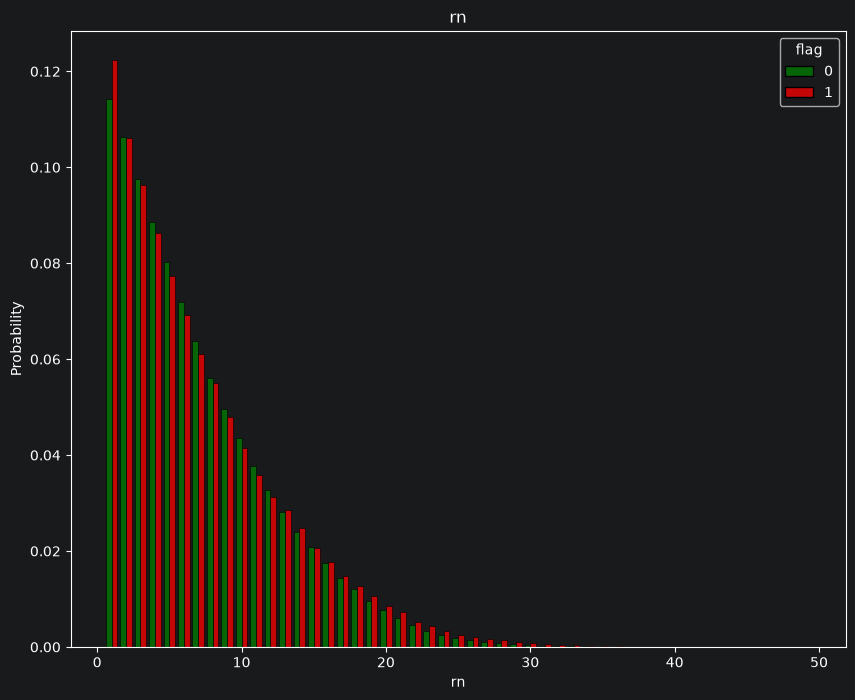

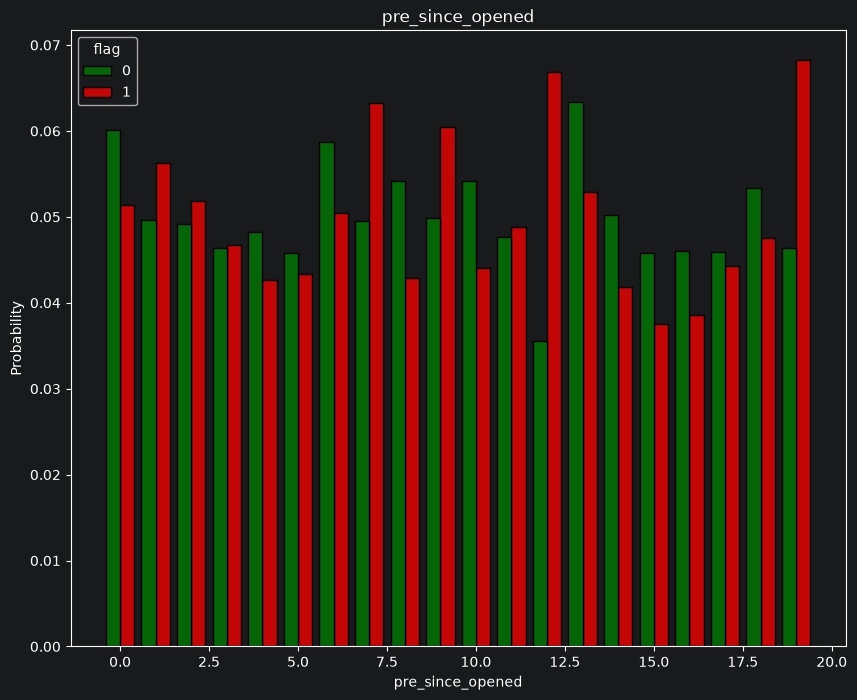

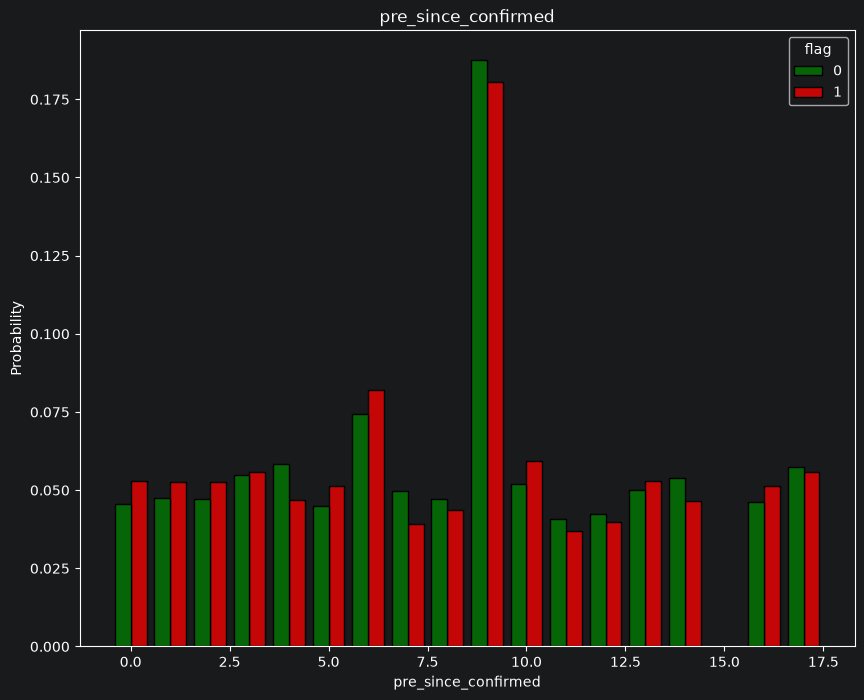

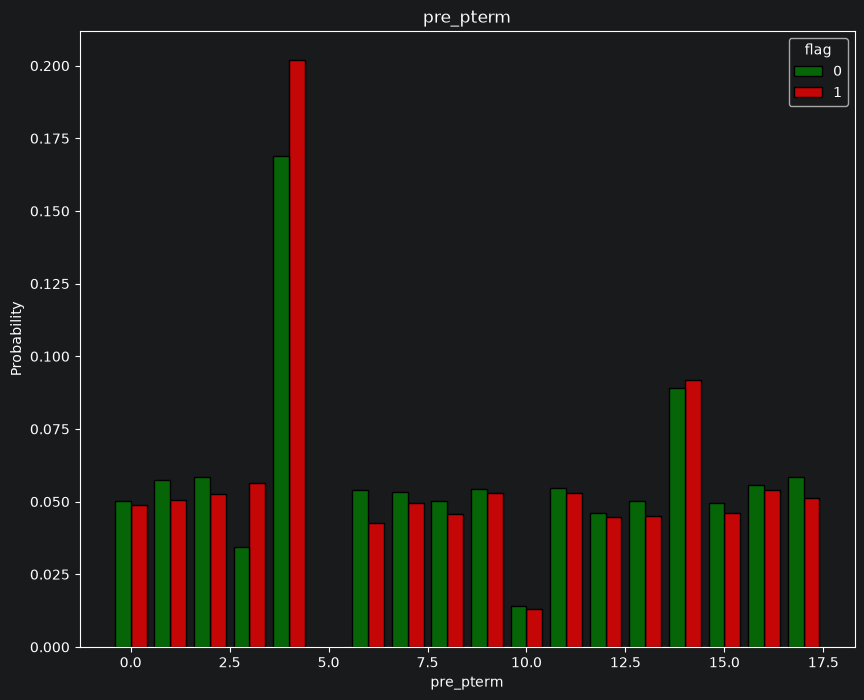

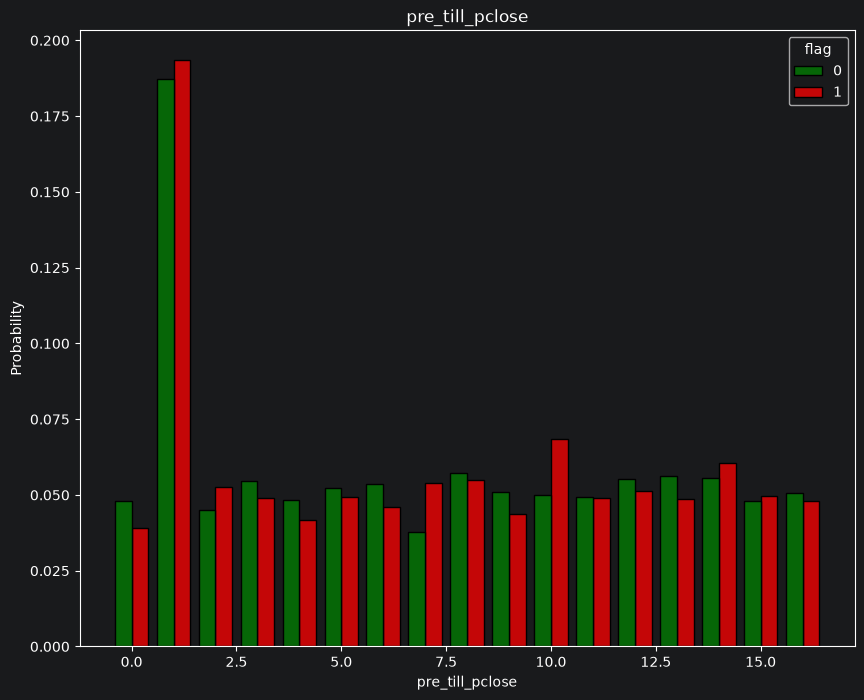

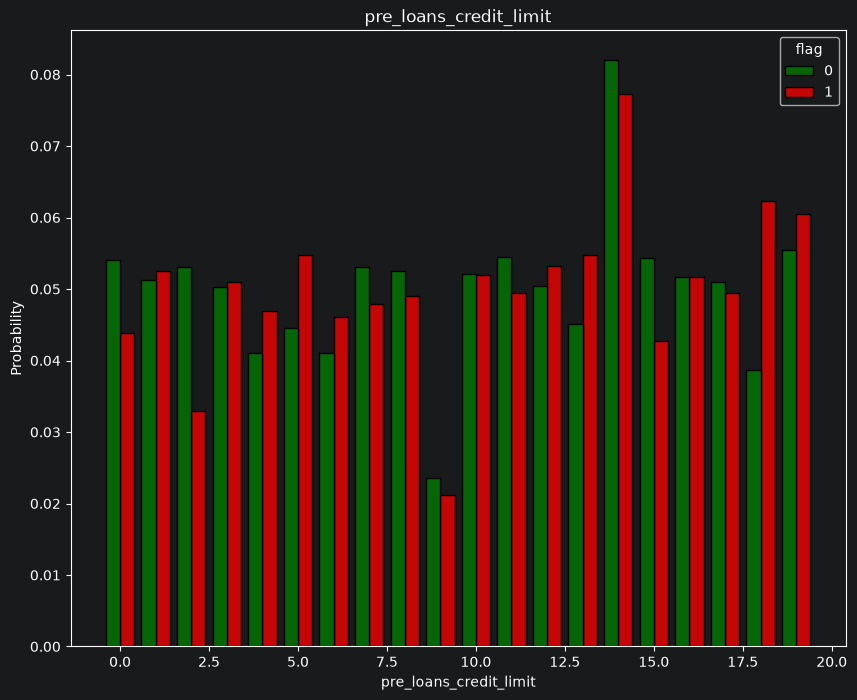

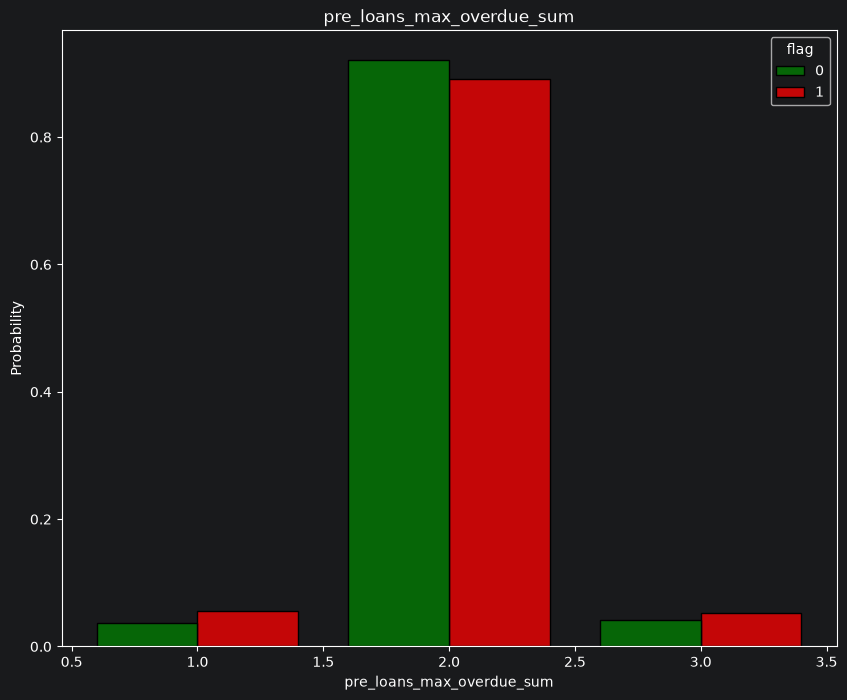

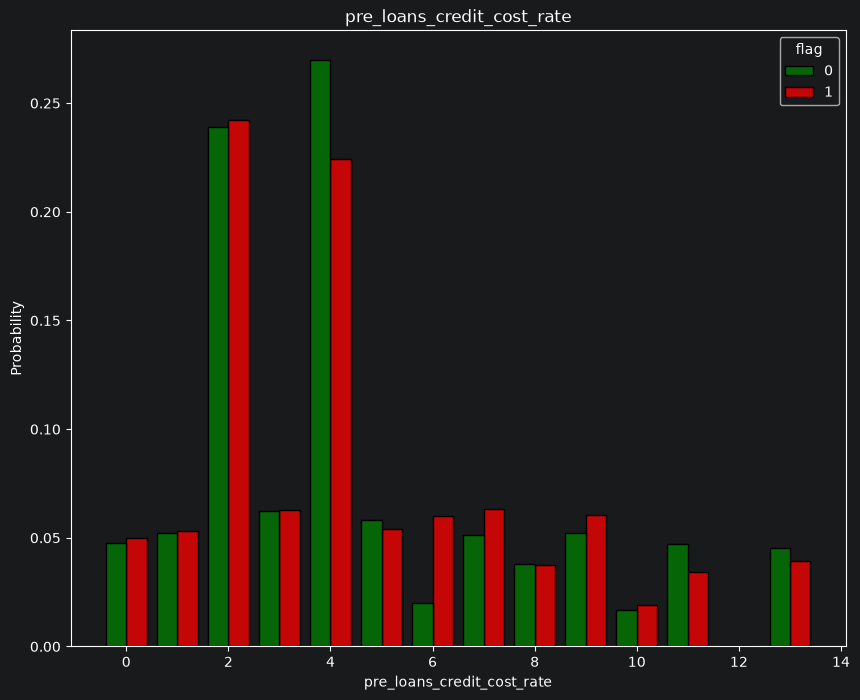

In [18]:
plot_relation_feature_target(df=data, categorical=False, features=numerical_features)

### Categorical features

**Observations:**
Most of the features have around 3 and 5% of differences between the value target. However some features like `enc_loan_credit_status` and `enc_loan_creadi_type` and some `enc_paym` seem have pertinent features

<Figure size 1000x600 with 0 Axes>

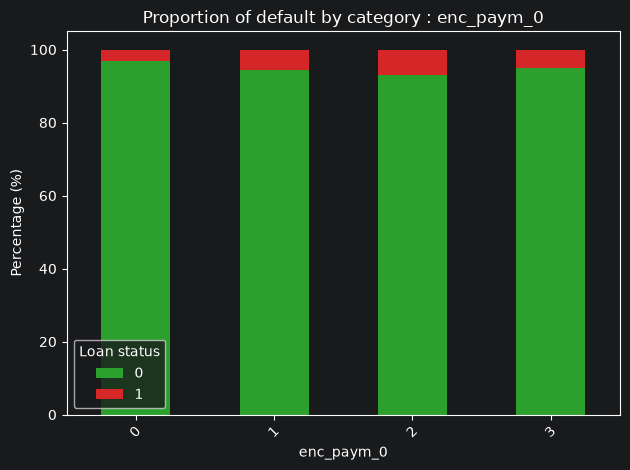

<Figure size 1000x600 with 0 Axes>

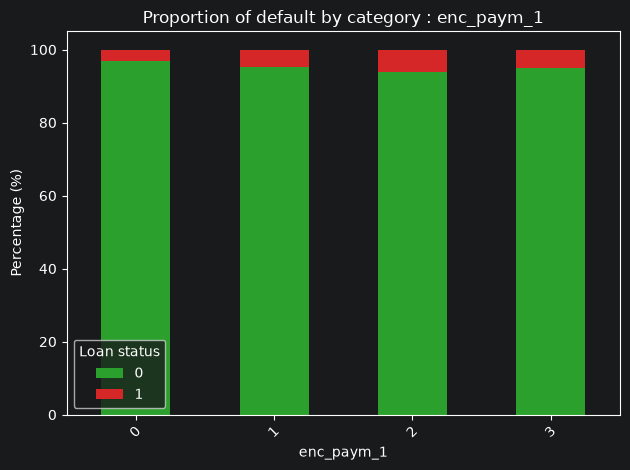

<Figure size 1000x600 with 0 Axes>

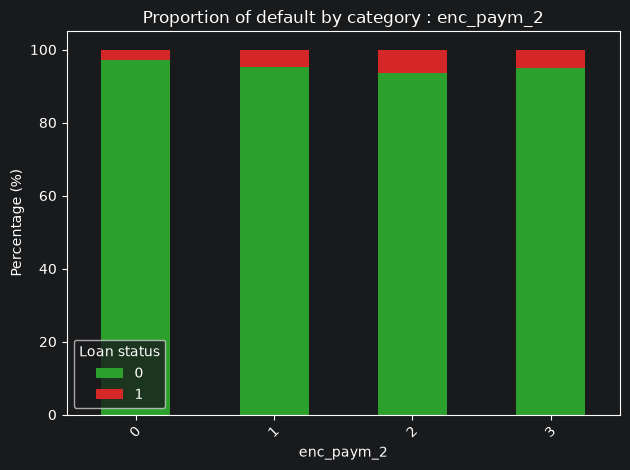

<Figure size 1000x600 with 0 Axes>

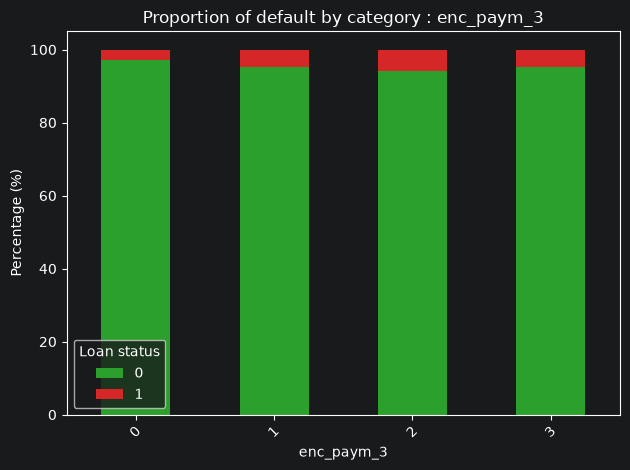

<Figure size 1000x600 with 0 Axes>

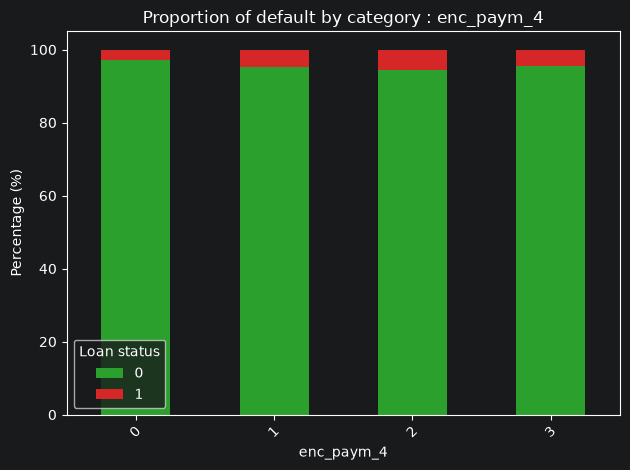

<Figure size 1000x600 with 0 Axes>

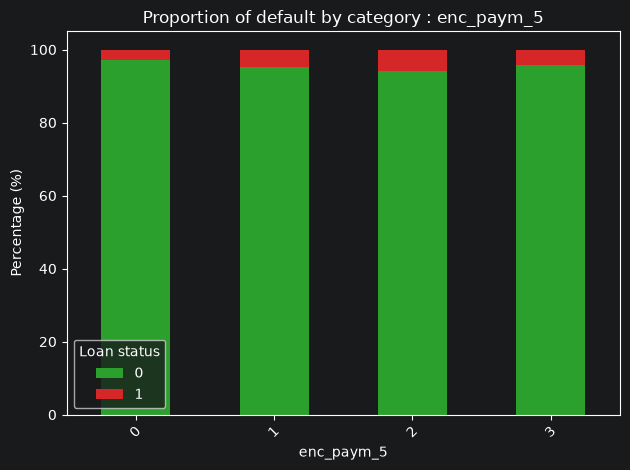

<Figure size 1000x600 with 0 Axes>

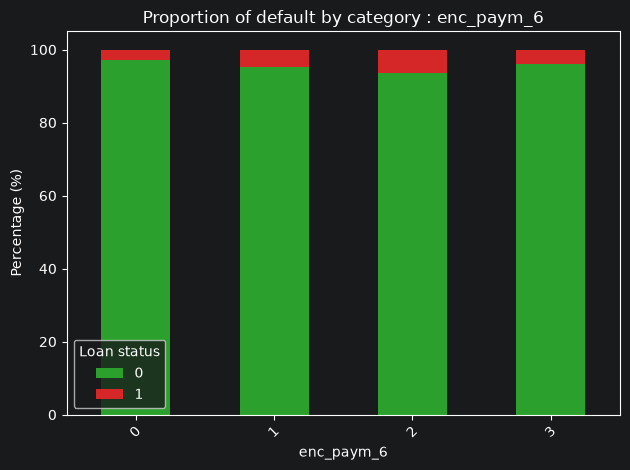

<Figure size 1000x600 with 0 Axes>

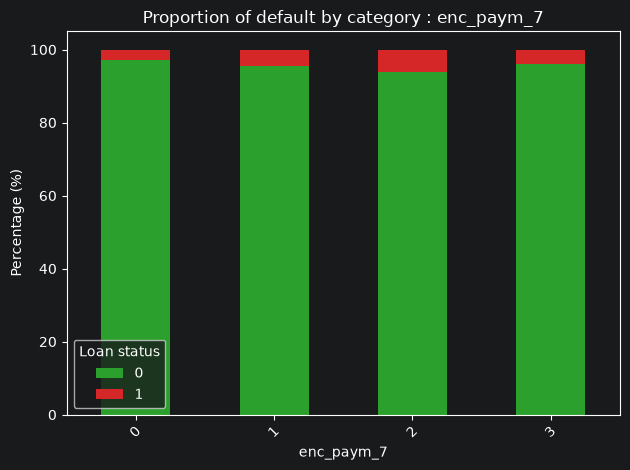

<Figure size 1000x600 with 0 Axes>

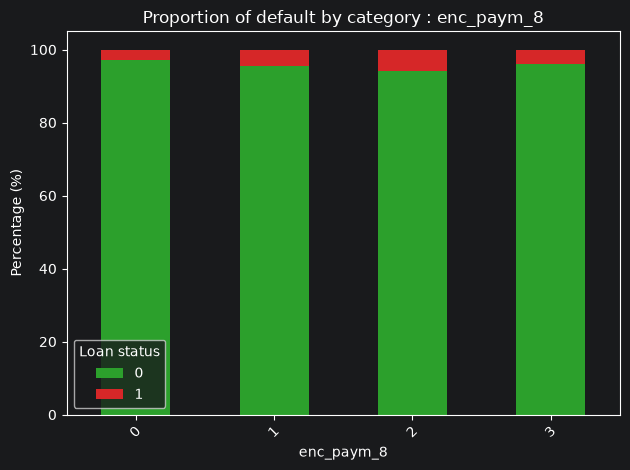

<Figure size 1000x600 with 0 Axes>

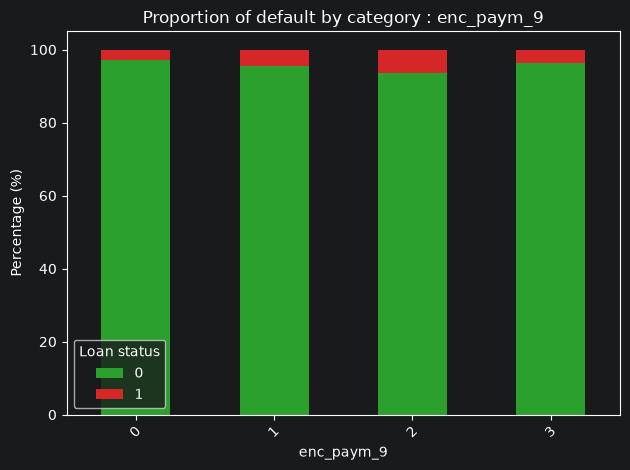

<Figure size 1000x600 with 0 Axes>

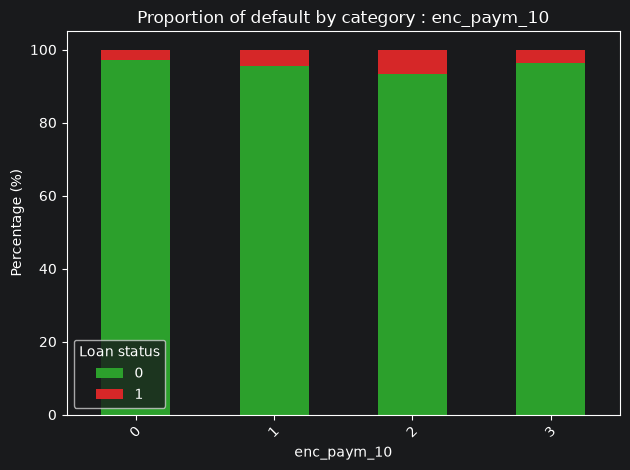

<Figure size 1000x600 with 0 Axes>

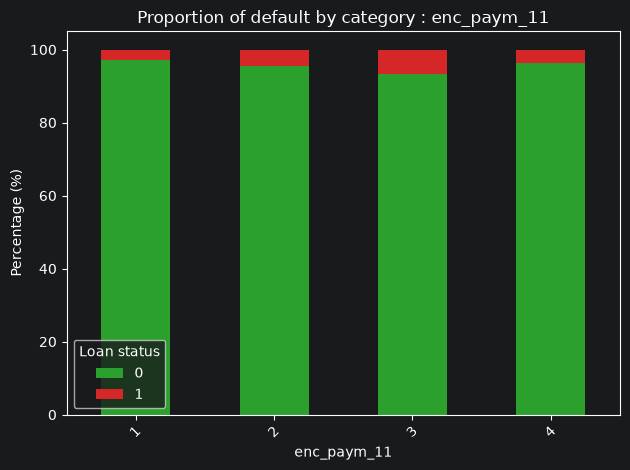

<Figure size 1000x600 with 0 Axes>

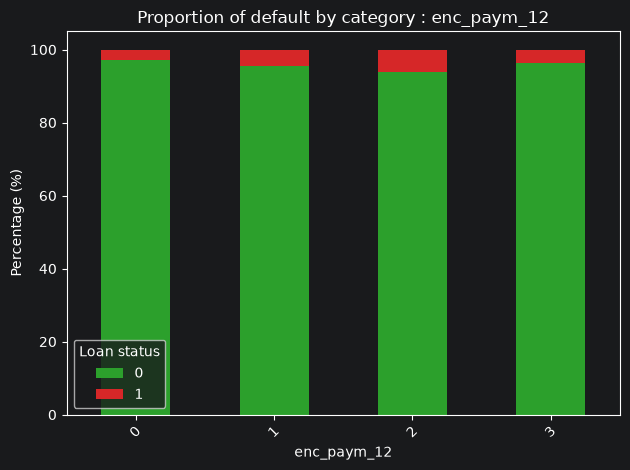

<Figure size 1000x600 with 0 Axes>

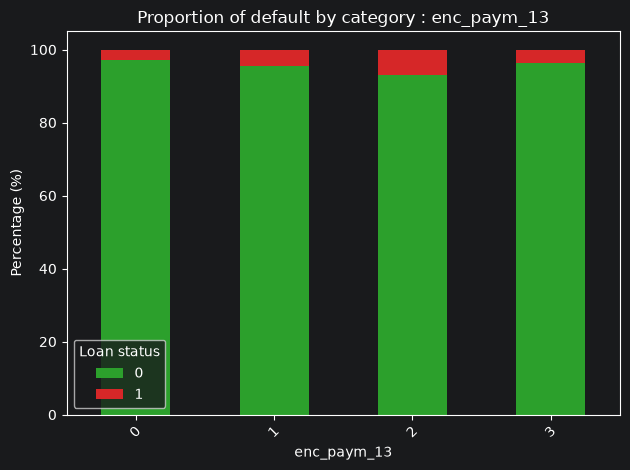

<Figure size 1000x600 with 0 Axes>

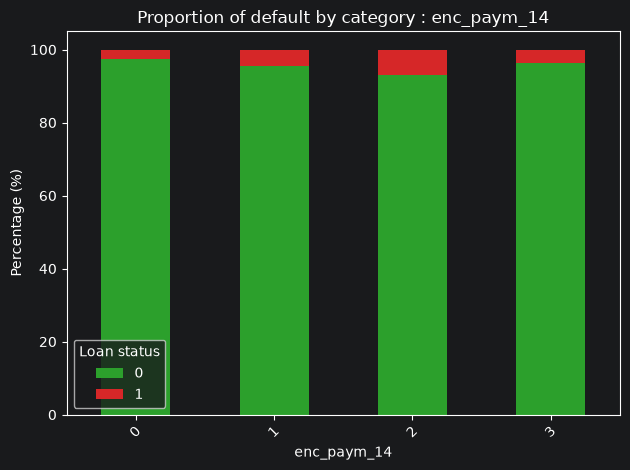

<Figure size 1000x600 with 0 Axes>

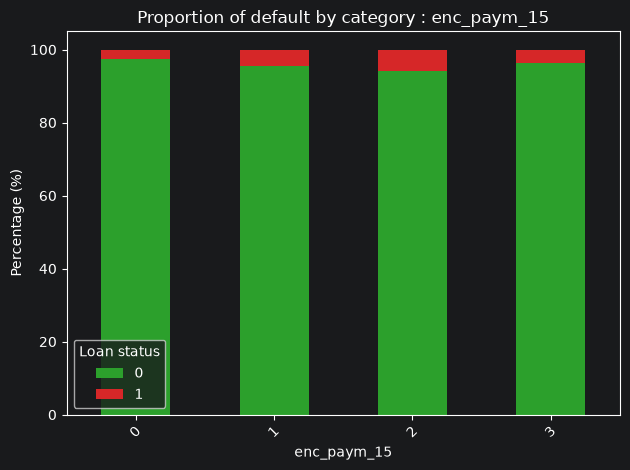

<Figure size 1000x600 with 0 Axes>

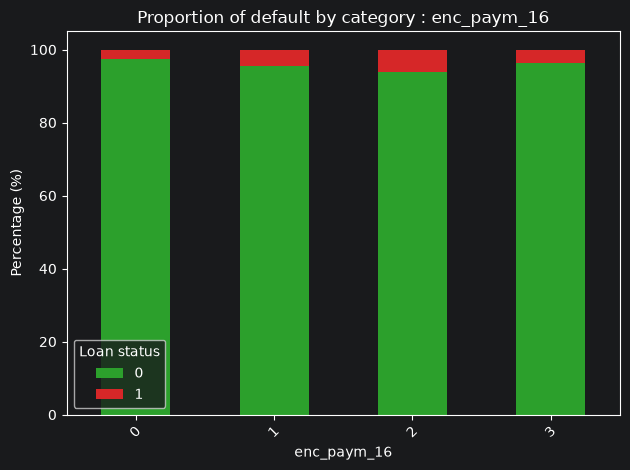

<Figure size 1000x600 with 0 Axes>

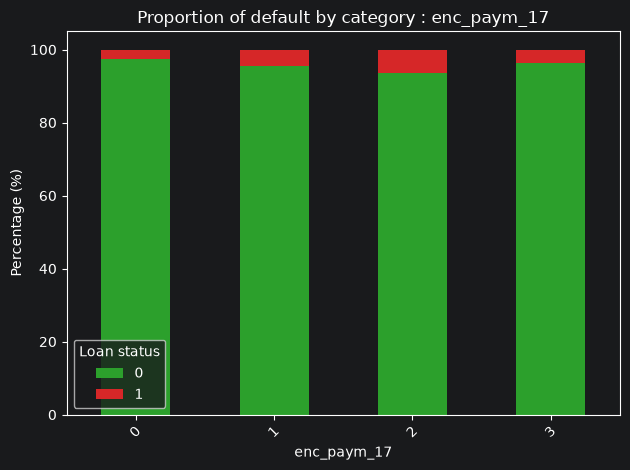

<Figure size 1000x600 with 0 Axes>

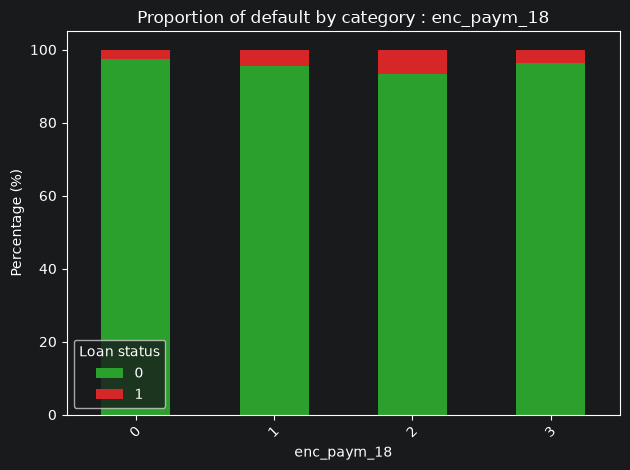

<Figure size 1000x600 with 0 Axes>

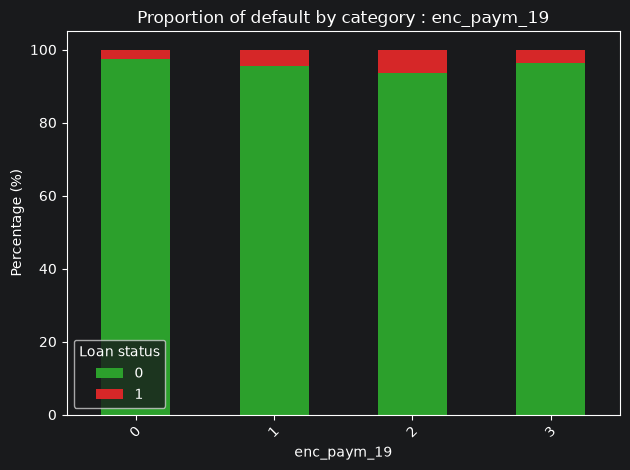

<Figure size 1000x600 with 0 Axes>

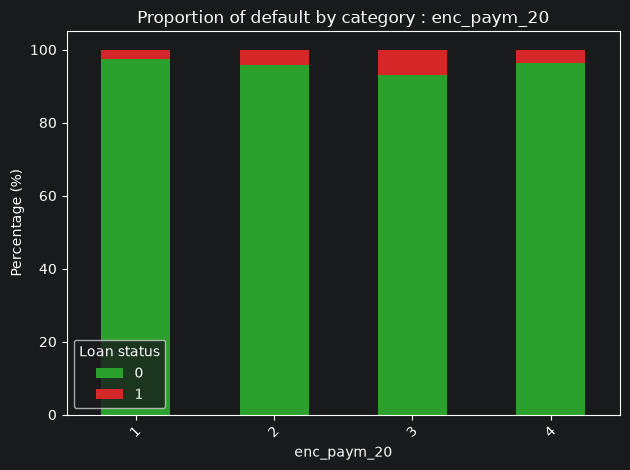

<Figure size 1000x600 with 0 Axes>

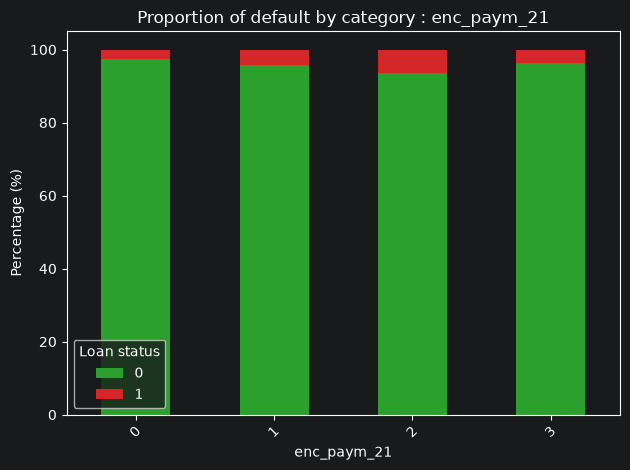

<Figure size 1000x600 with 0 Axes>

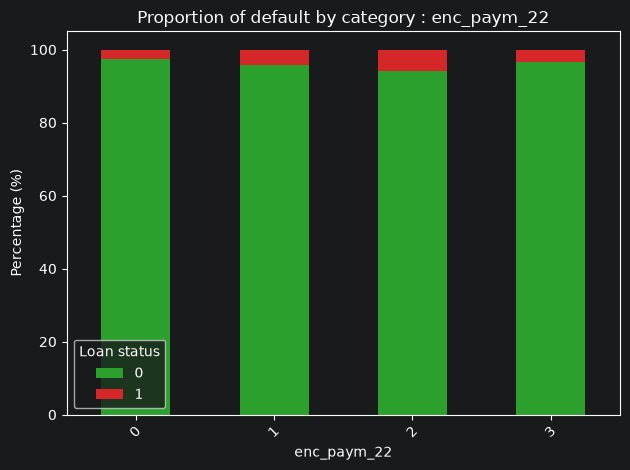

<Figure size 1000x600 with 0 Axes>

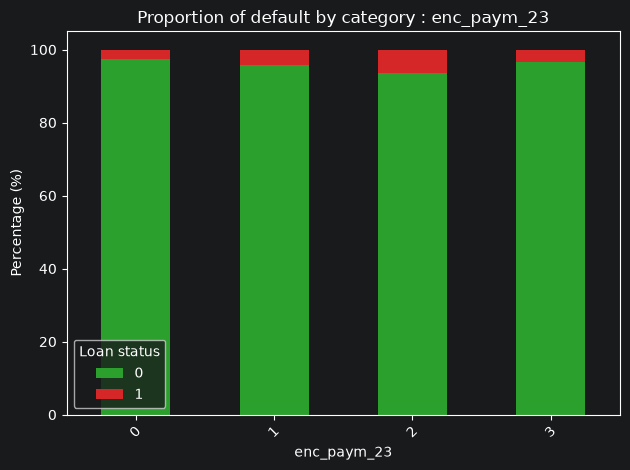

<Figure size 1000x600 with 0 Axes>

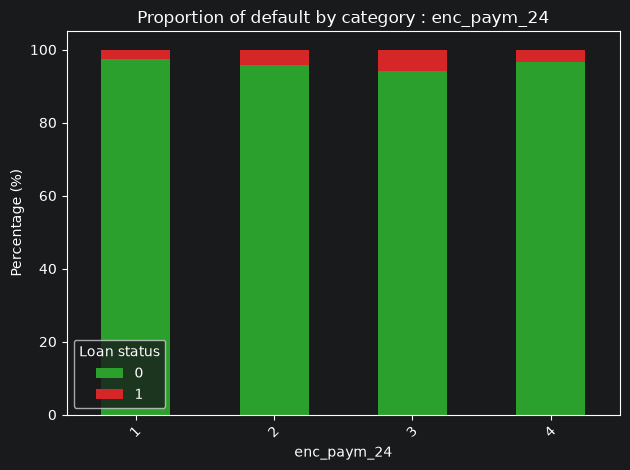

<Figure size 1000x600 with 0 Axes>

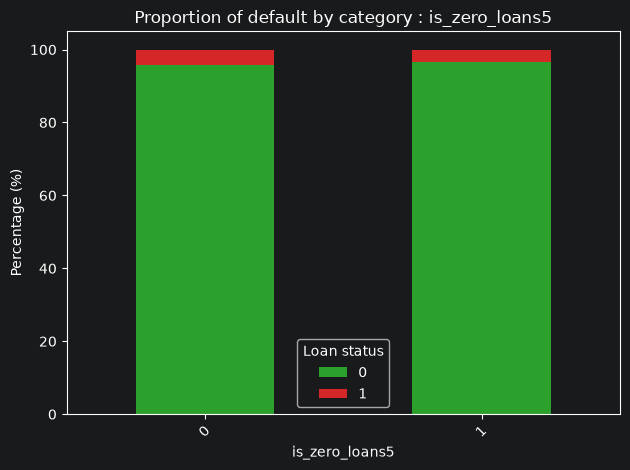

<Figure size 1000x600 with 0 Axes>

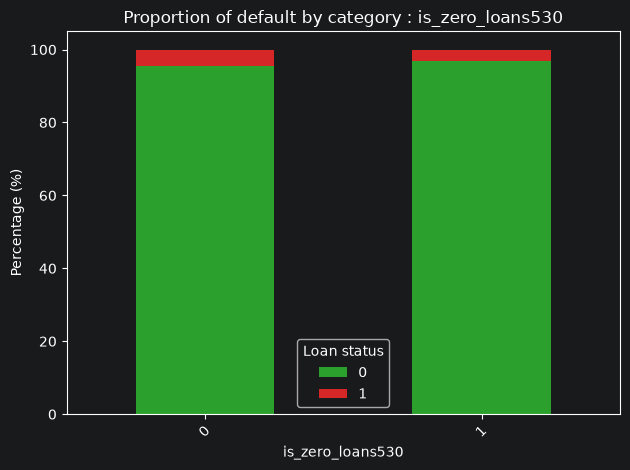

<Figure size 1000x600 with 0 Axes>

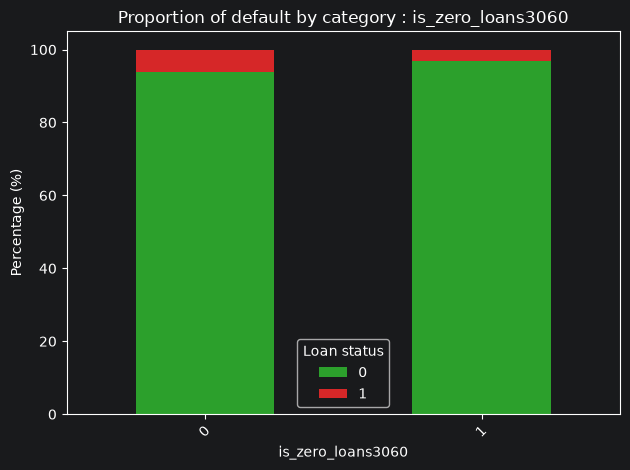

<Figure size 1000x600 with 0 Axes>

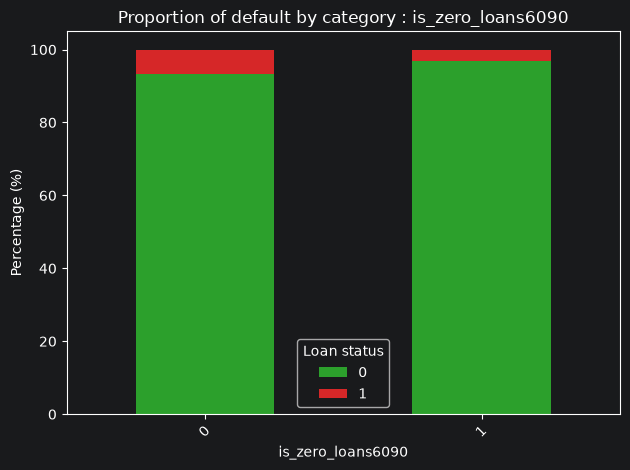

<Figure size 1000x600 with 0 Axes>

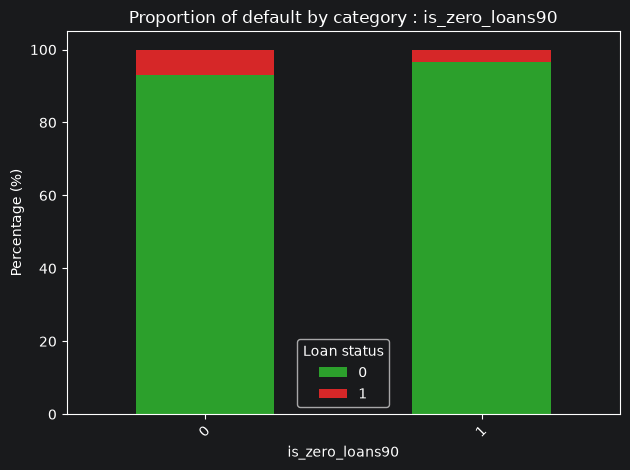

<Figure size 1000x600 with 0 Axes>

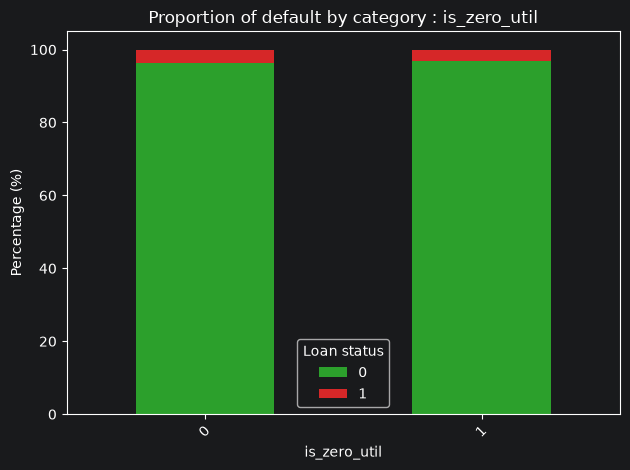

<Figure size 1000x600 with 0 Axes>

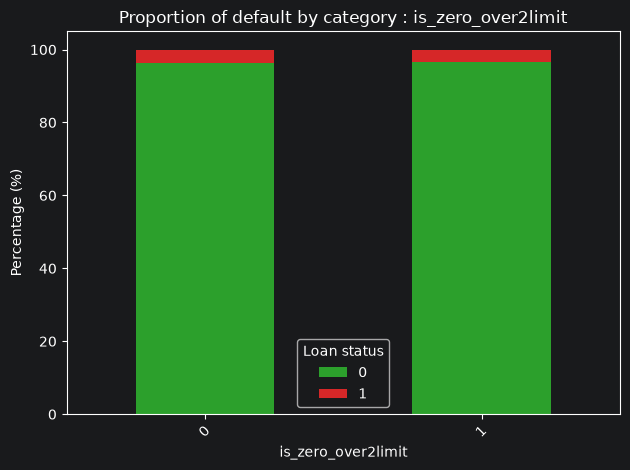

<Figure size 1000x600 with 0 Axes>

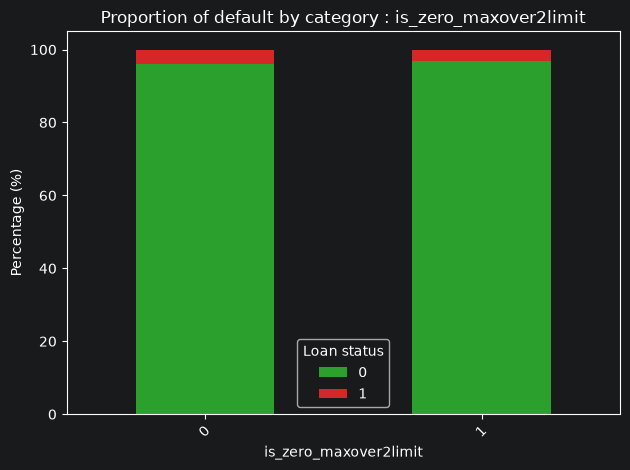

<Figure size 1000x600 with 0 Axes>

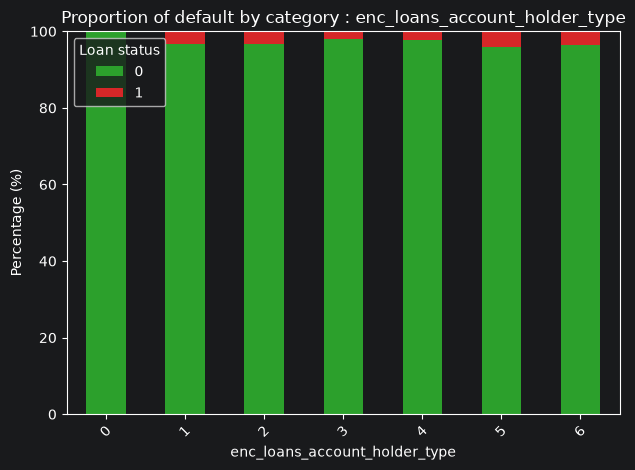

<Figure size 1000x600 with 0 Axes>

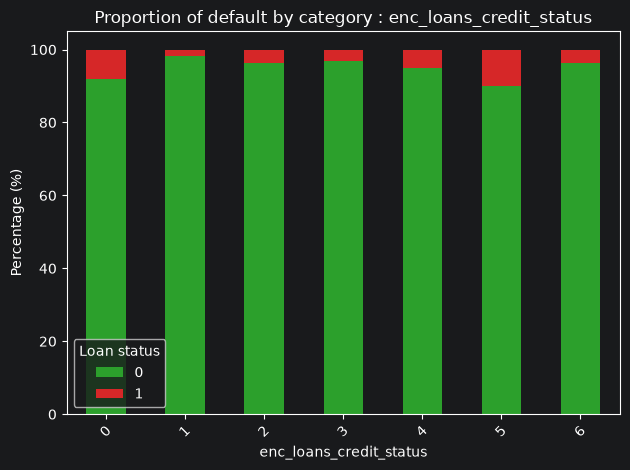

<Figure size 1000x600 with 0 Axes>

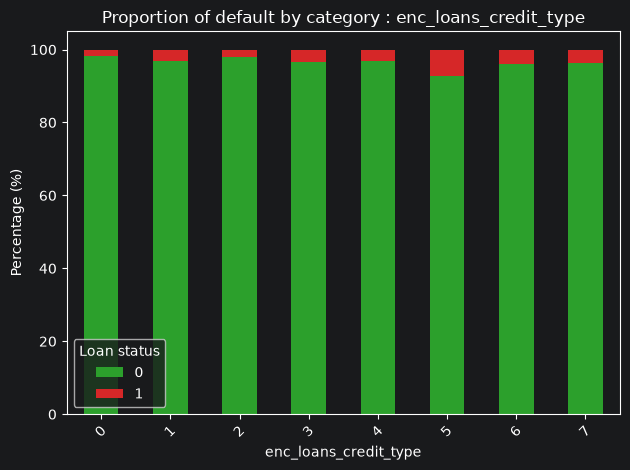

<Figure size 1000x600 with 0 Axes>

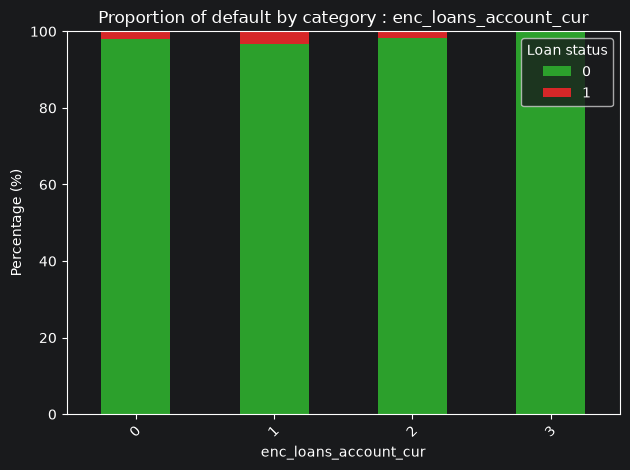

<Figure size 1000x600 with 0 Axes>

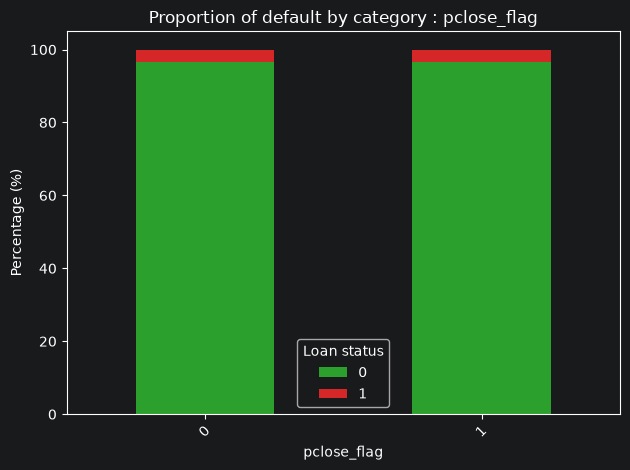

<Figure size 1000x600 with 0 Axes>

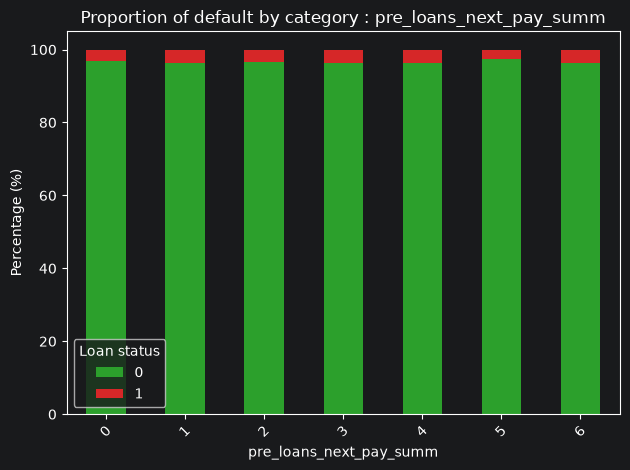

<Figure size 1000x600 with 0 Axes>

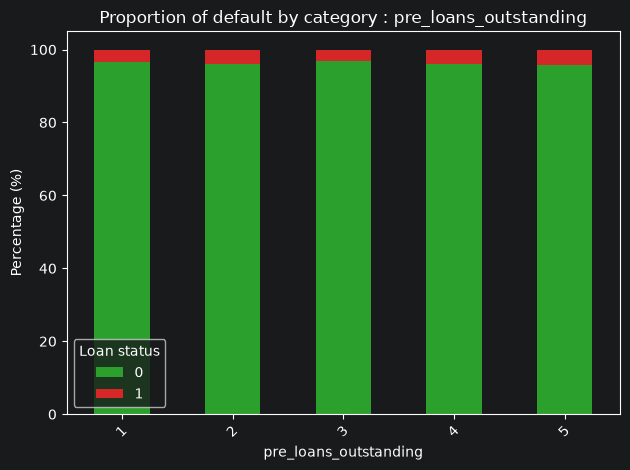

<Figure size 1000x600 with 0 Axes>

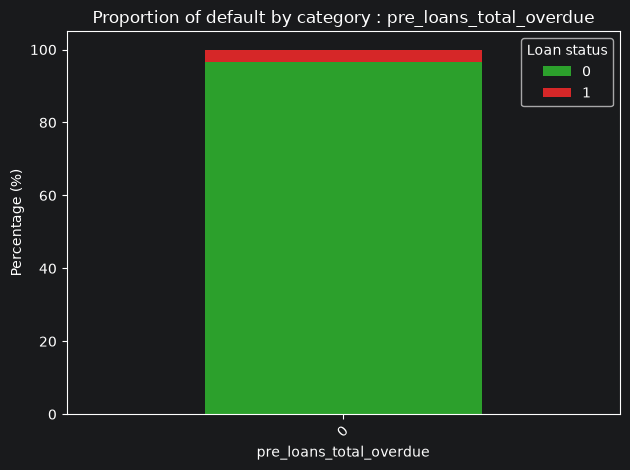

In [19]:
plot_relation_feature_target(df=data, categorical=True, features=categorical_features)

In [20]:
paym_cols = [c for c in data.columns if c.startswith("enc_paym_")]

df_aggregated = data.with_columns(
    # Worst payment status ever reached
    pl.max_horizontal(paym_cols).alias("paym_max_status"),
    # Mean status over the total period
    pl.concat_list(paym_cols)
    .list.eval(pl.element().mean())
    .list.first()
    .alias("paym_mean_status"),
    # Number of months with delay  / incidents (assume > 0)
    pl.concat_list(paym_cols)
    .list.eval((pl.element() > 0).sum())
    .list.first()
    .alias("paym_count_incidents"),
    # Last known status (ex: The most recent month enc_paym_0)
    pl.col("enc_paym_0").alias("paym_latest_status"),
)

In [21]:
df_aggregated.head()

id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag,paym_max_status,paym_mean_status,paym_count_incidents,paym_latest_status
i32,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i8,i16,f64,u32,i16
514515,9,19,9,4,1,6,1,3,0,2,1,6,16,5,4,8,1,1,1,1,1,12,2,17,0,1,1,0,0,0,0,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,0,4,2.64,21,0
719549,8,17,13,16,11,1,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,3,1,0,0,4,3.0,24,0
540373,12,19,9,4,1,14,5,4,0,2,5,6,16,5,4,8,1,1,1,1,1,4,2,17,0,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,1,0,4,2.88,23,0
141438,11,1,9,2,12,8,4,2,0,2,0,6,16,5,4,8,1,1,1,1,1,0,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,4,1.8,14,0
1013450,3,0,10,0,12,11,0,5,0,2,7,6,13,5,4,8,1,0,0,1,1,6,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2,1,0,0,0,1,0,1,1,1,0,1,1,2,3,1,0,0,2,0.36,8,0


In [22]:
numerical_features.extend(["paym_mean_status", "paym_count_incidents"])
categorical_features.extend(["paym_max_status", "paym_latest_status"])

The new features seems to be very interesting

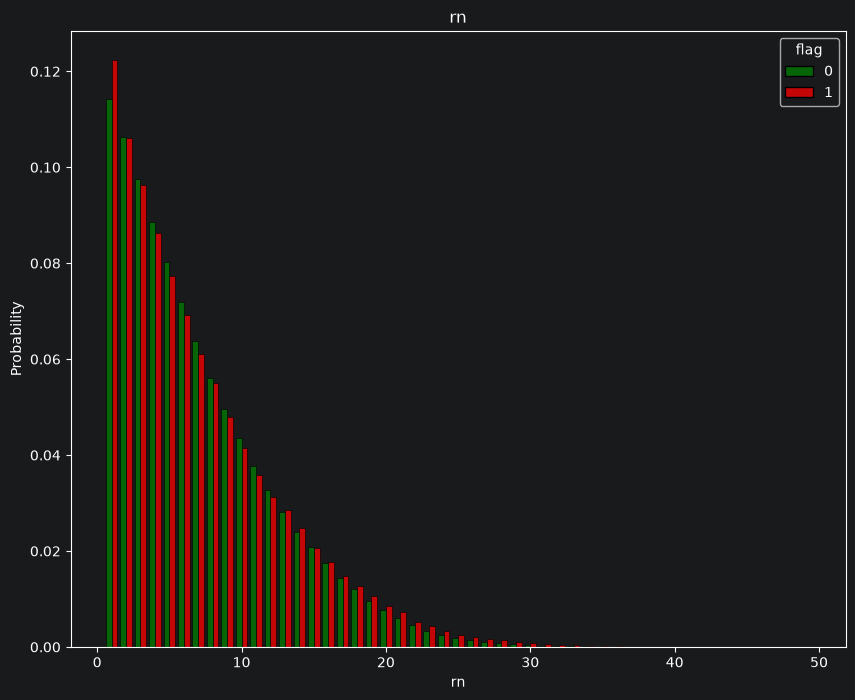

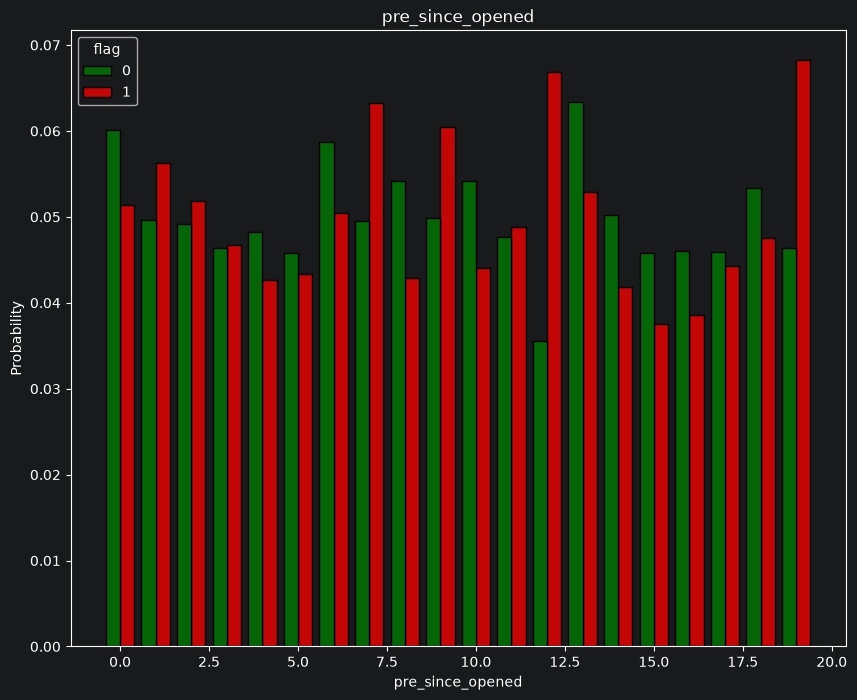

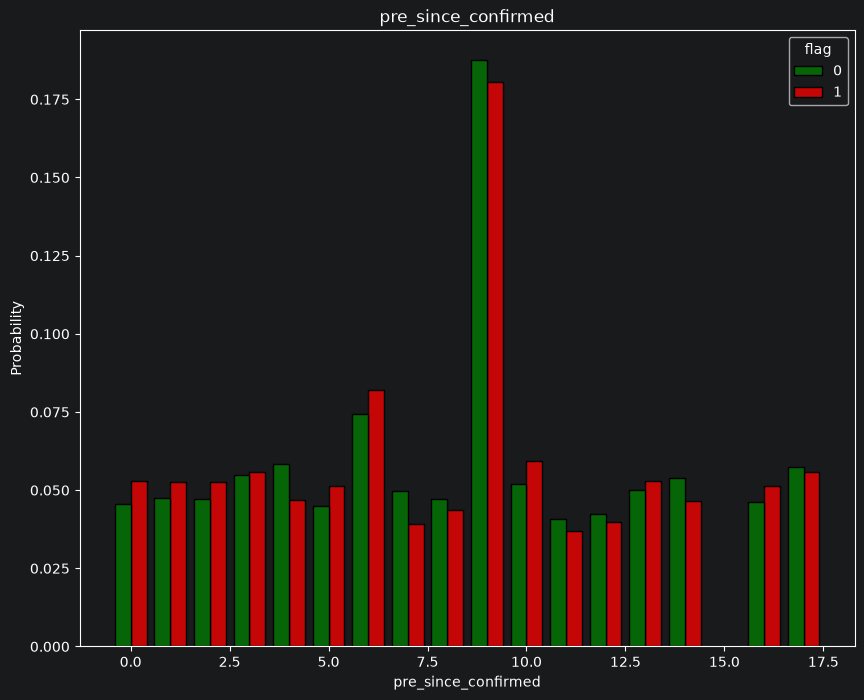

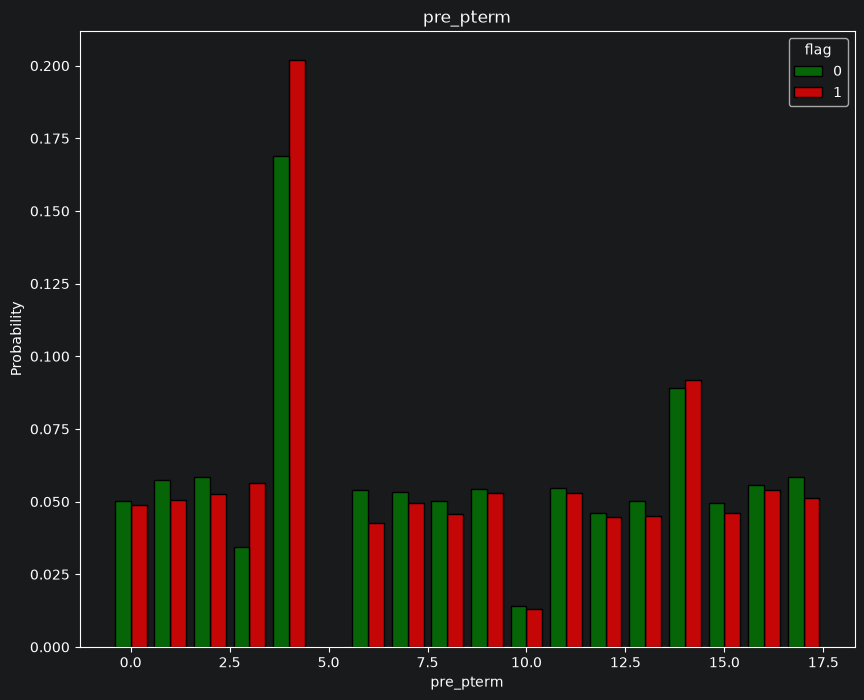

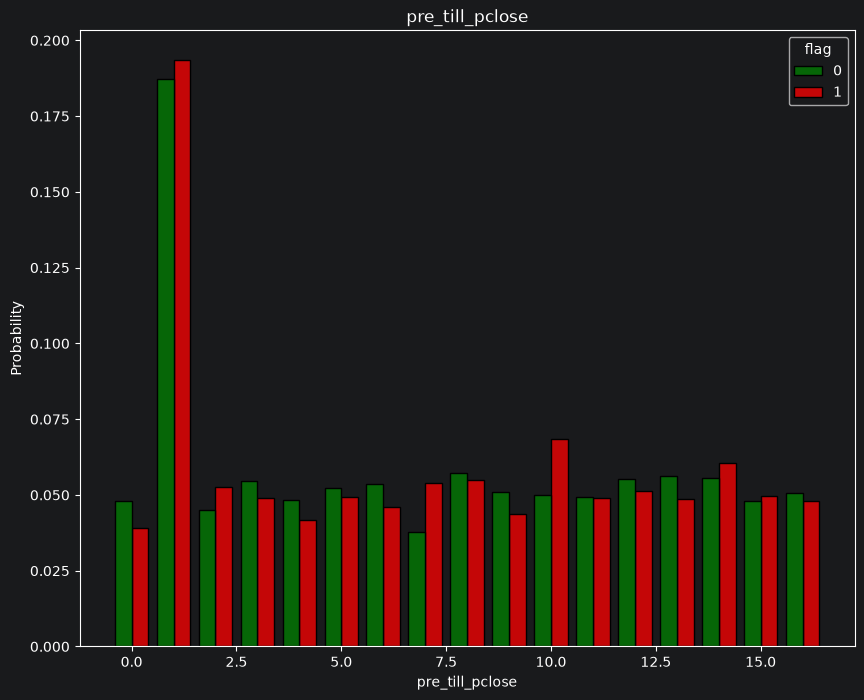

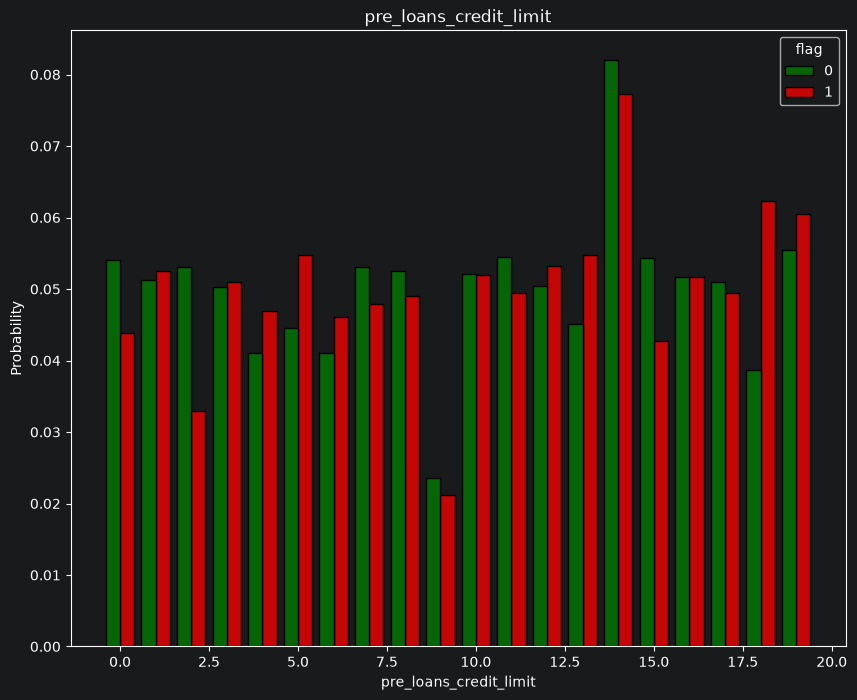

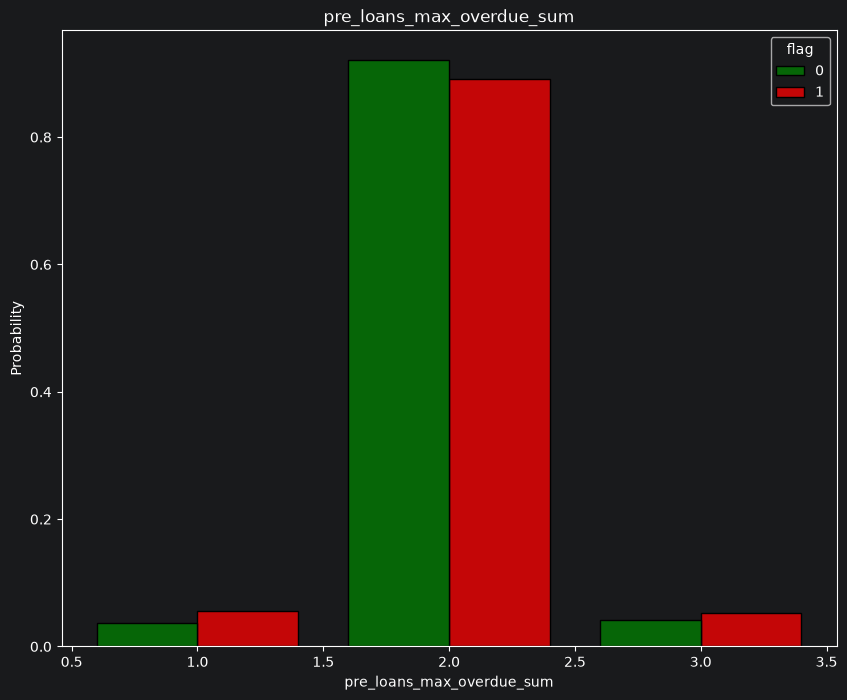

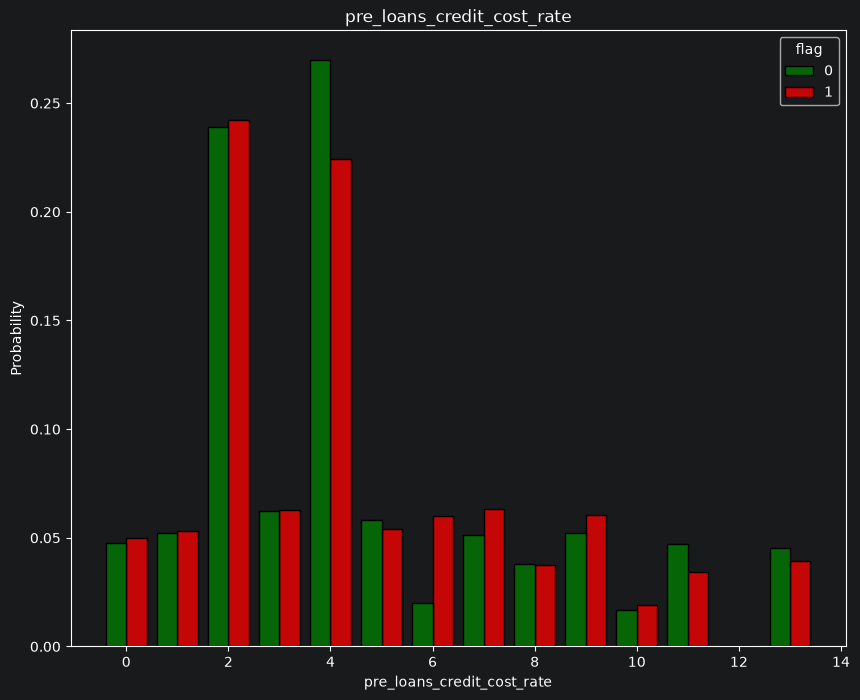

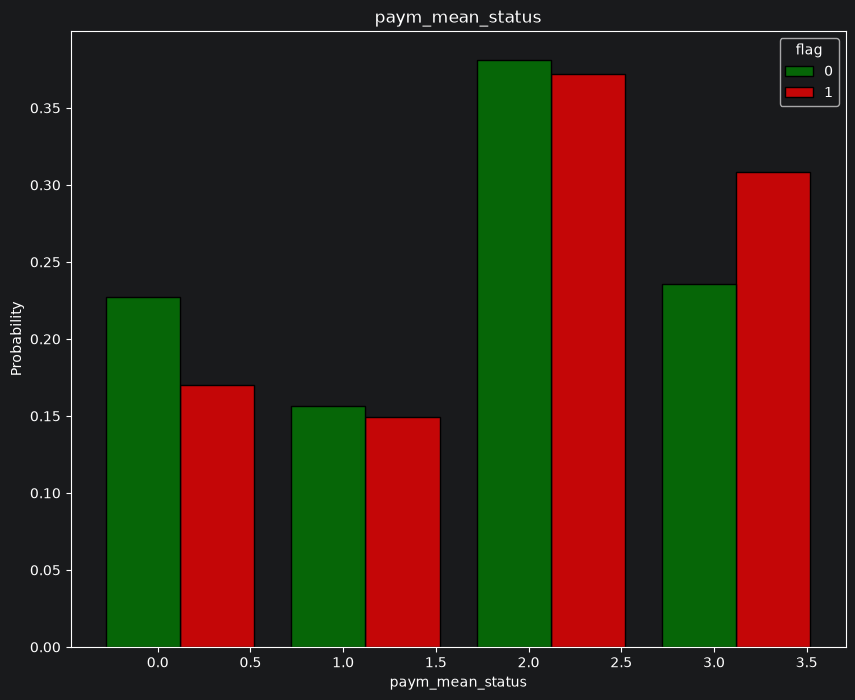

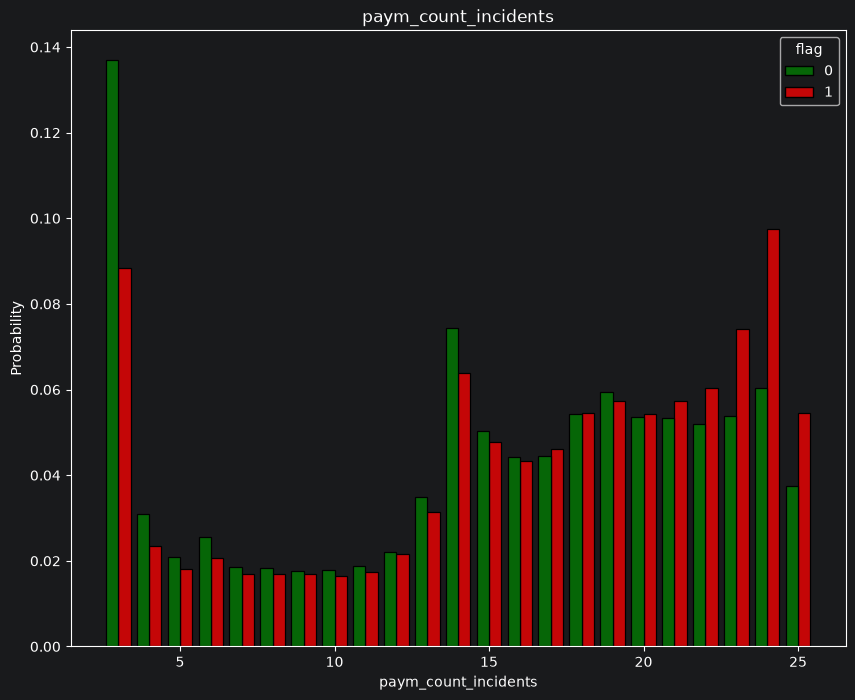

In [23]:
plot_relation_feature_target(df=df_aggregated, categorical=False, features=numerical_features)

The new feature don't seem very different in terms of significance

<Figure size 1000x600 with 0 Axes>

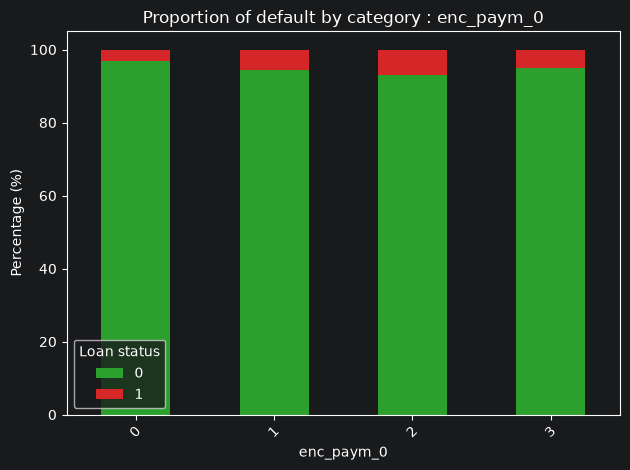

<Figure size 1000x600 with 0 Axes>

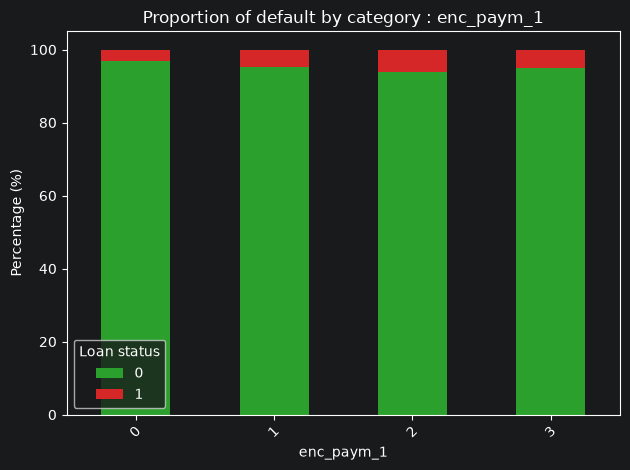

<Figure size 1000x600 with 0 Axes>

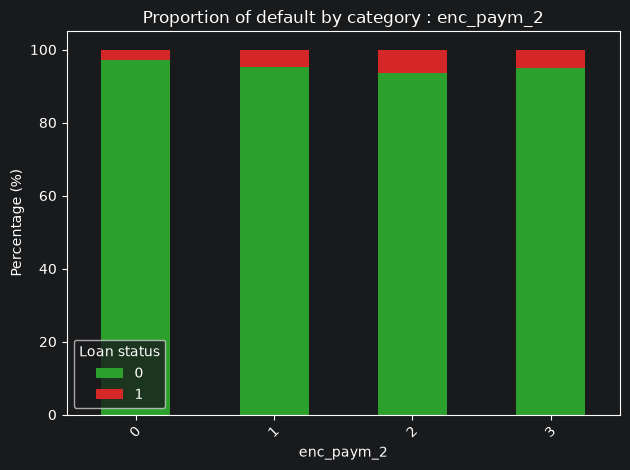

<Figure size 1000x600 with 0 Axes>

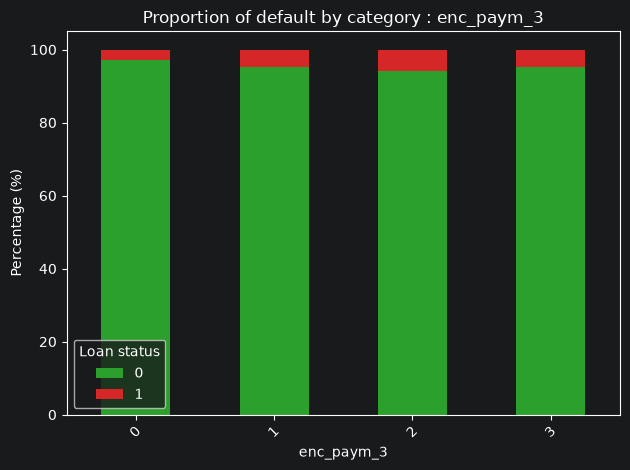

<Figure size 1000x600 with 0 Axes>

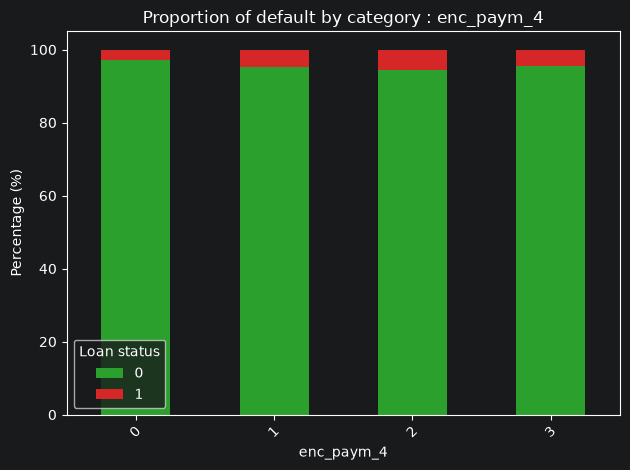

<Figure size 1000x600 with 0 Axes>

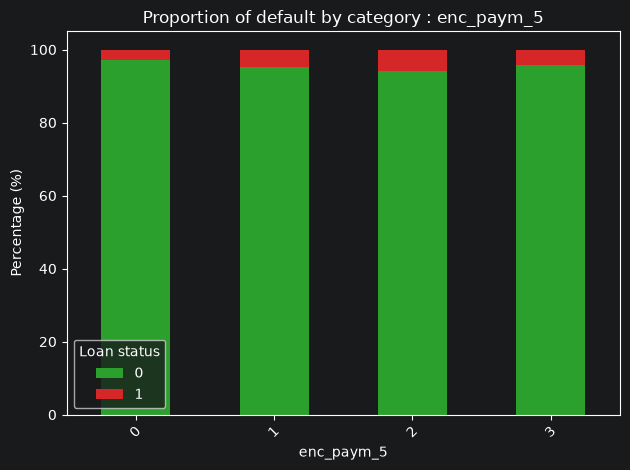

<Figure size 1000x600 with 0 Axes>

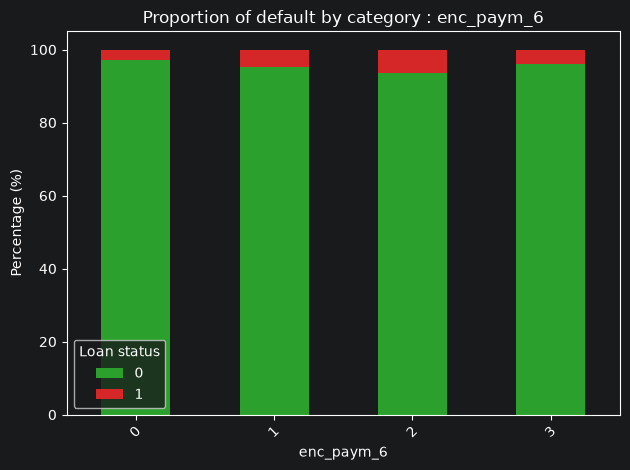

<Figure size 1000x600 with 0 Axes>

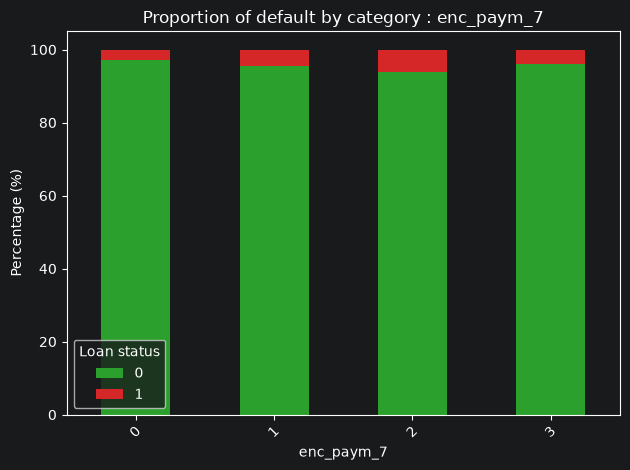

<Figure size 1000x600 with 0 Axes>

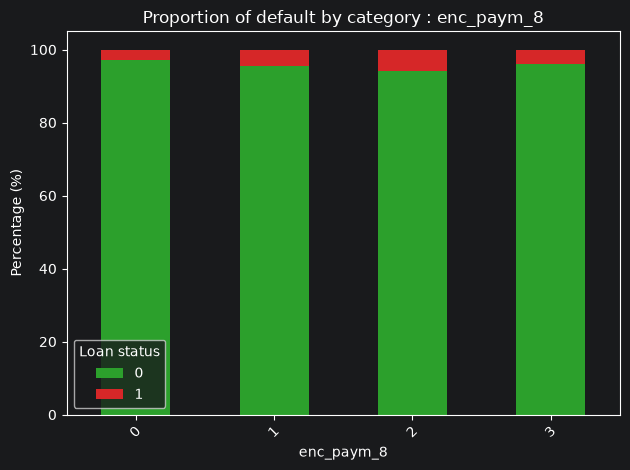

<Figure size 1000x600 with 0 Axes>

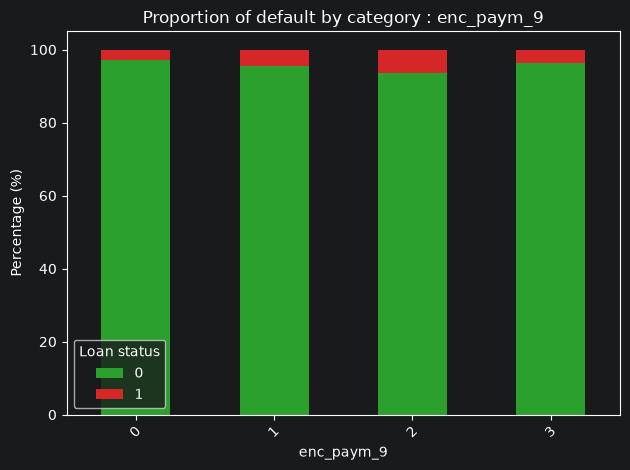

<Figure size 1000x600 with 0 Axes>

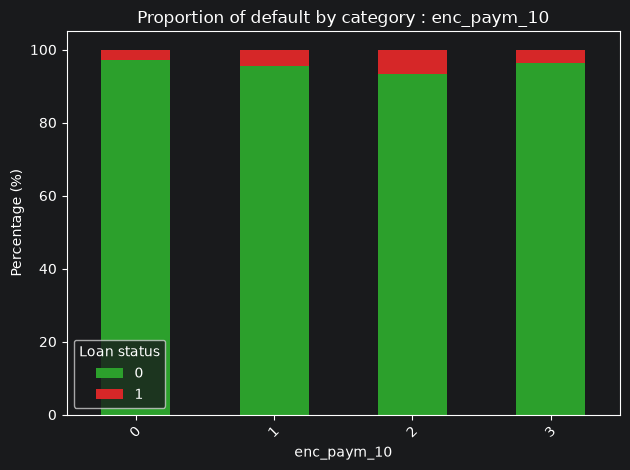

<Figure size 1000x600 with 0 Axes>

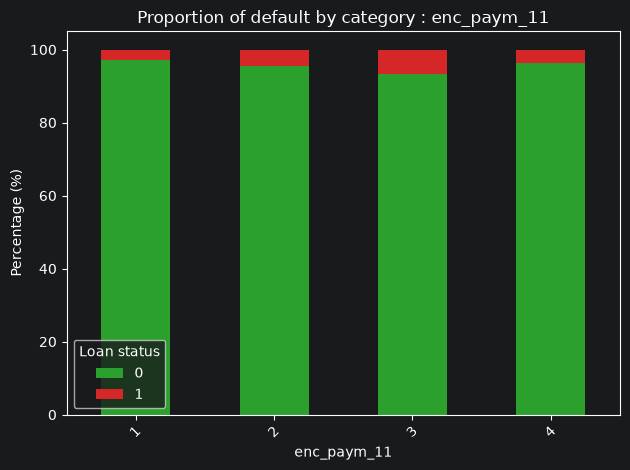

<Figure size 1000x600 with 0 Axes>

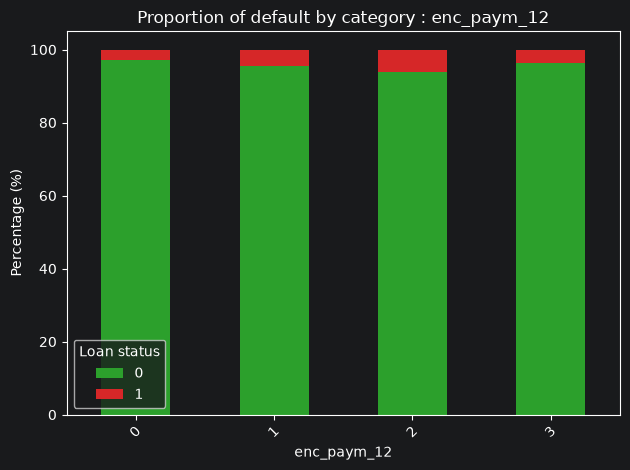

<Figure size 1000x600 with 0 Axes>

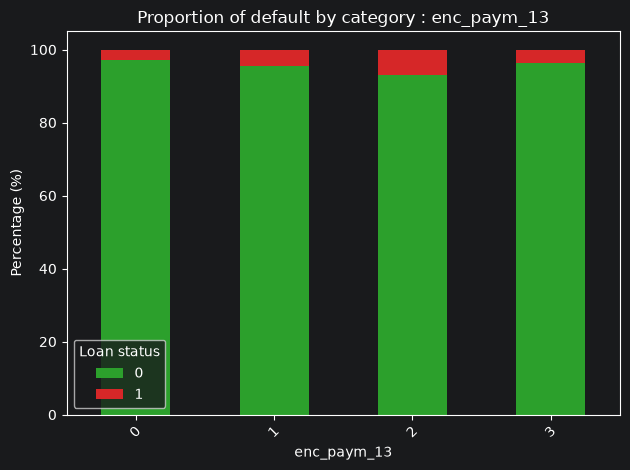

<Figure size 1000x600 with 0 Axes>

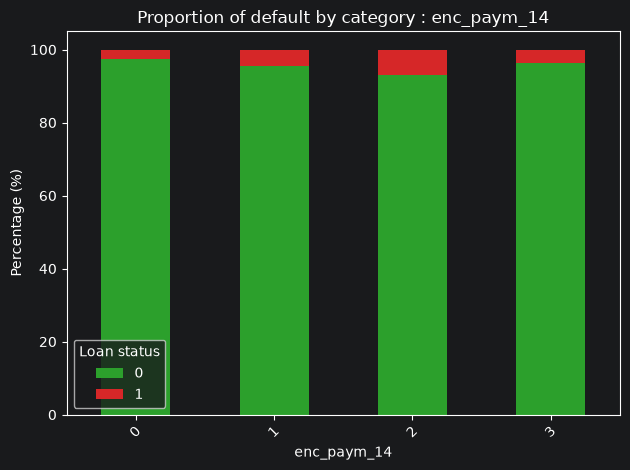

<Figure size 1000x600 with 0 Axes>

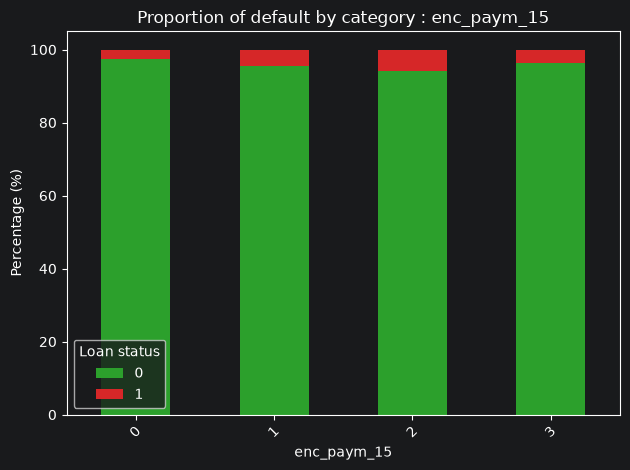

<Figure size 1000x600 with 0 Axes>

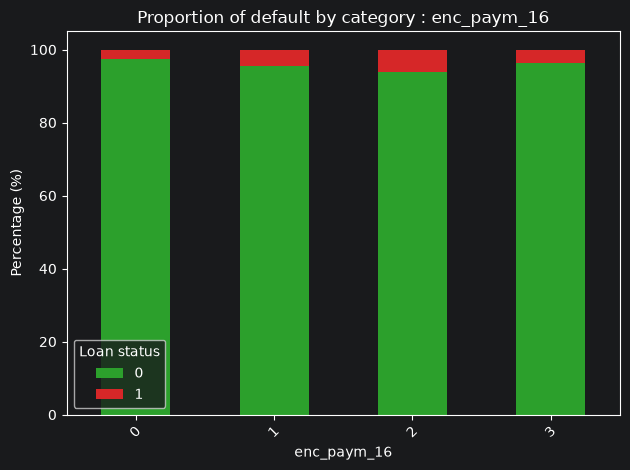

<Figure size 1000x600 with 0 Axes>

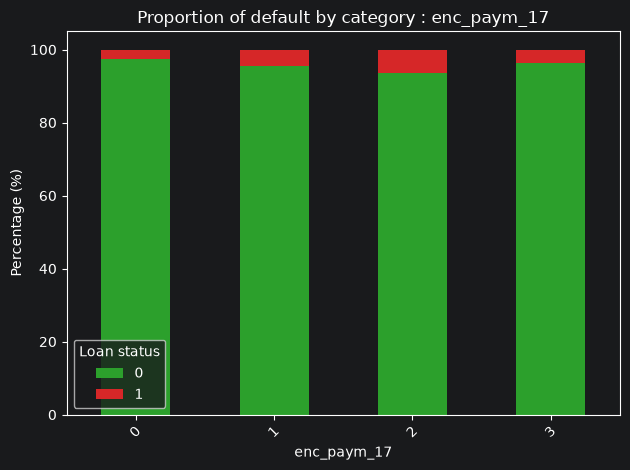

<Figure size 1000x600 with 0 Axes>

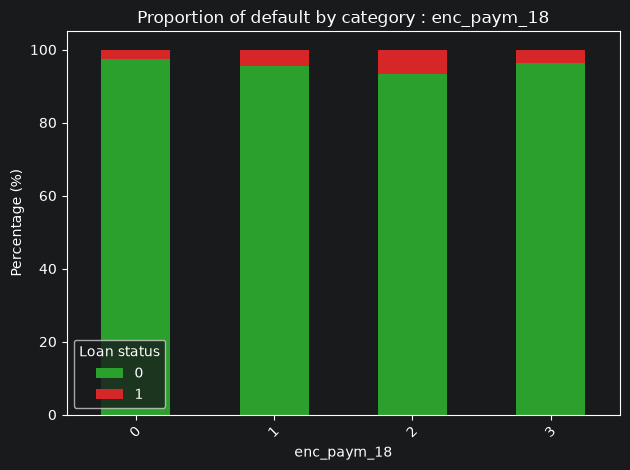

<Figure size 1000x600 with 0 Axes>

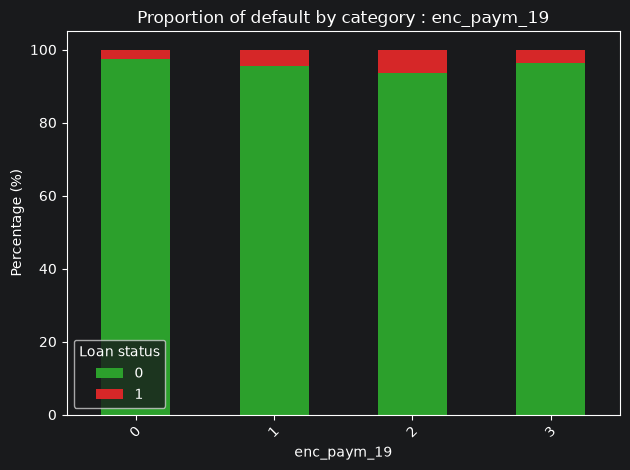

<Figure size 1000x600 with 0 Axes>

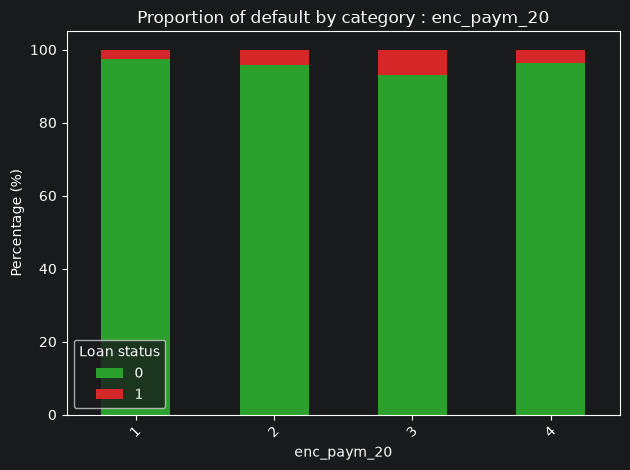

<Figure size 1000x600 with 0 Axes>

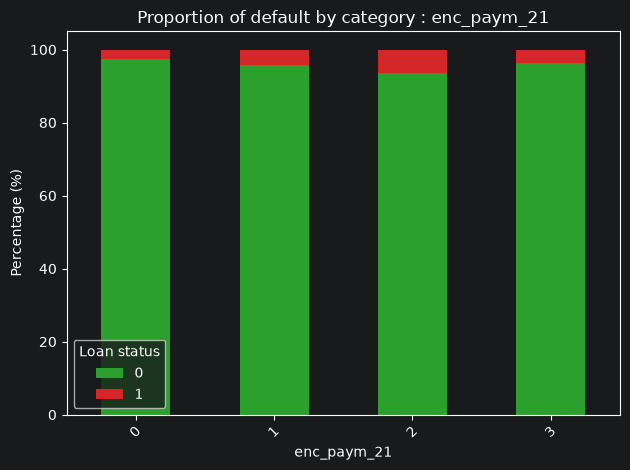

<Figure size 1000x600 with 0 Axes>

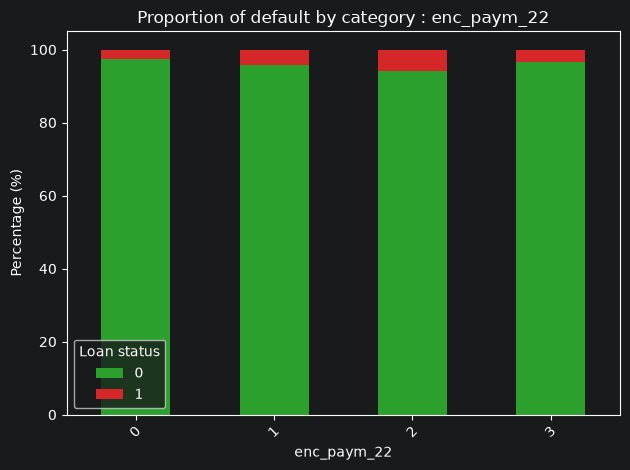

<Figure size 1000x600 with 0 Axes>

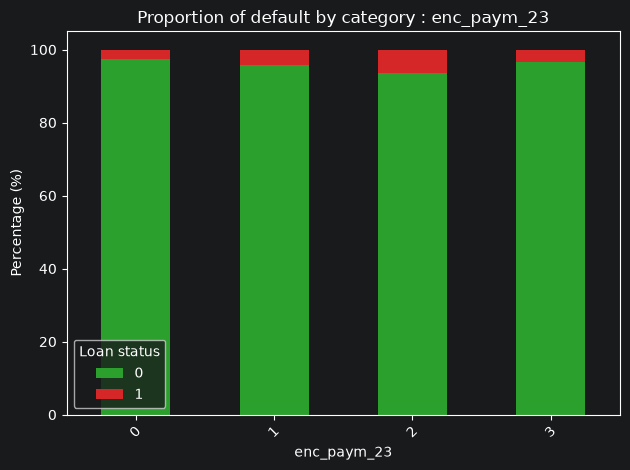

<Figure size 1000x600 with 0 Axes>

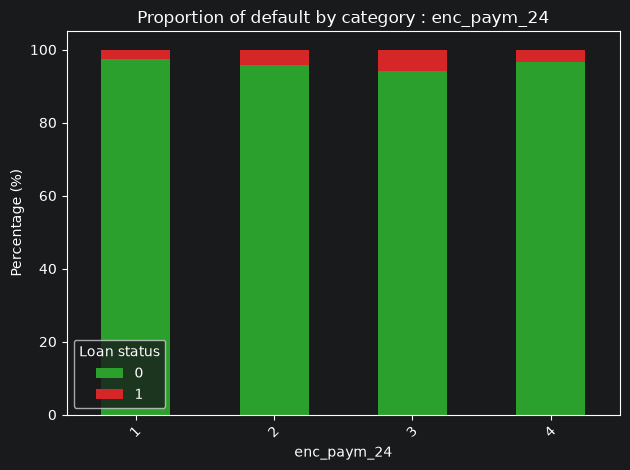

<Figure size 1000x600 with 0 Axes>

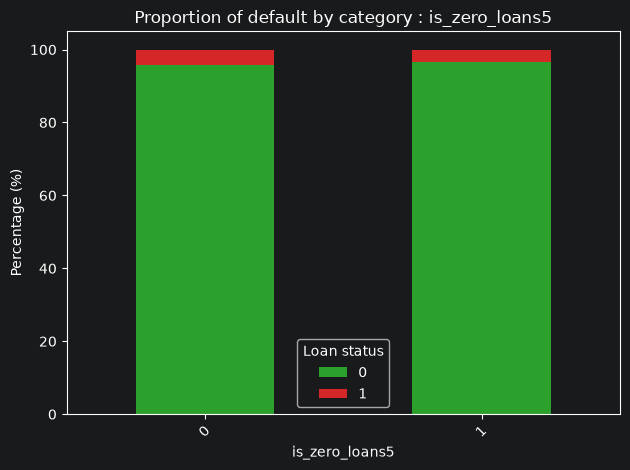

<Figure size 1000x600 with 0 Axes>

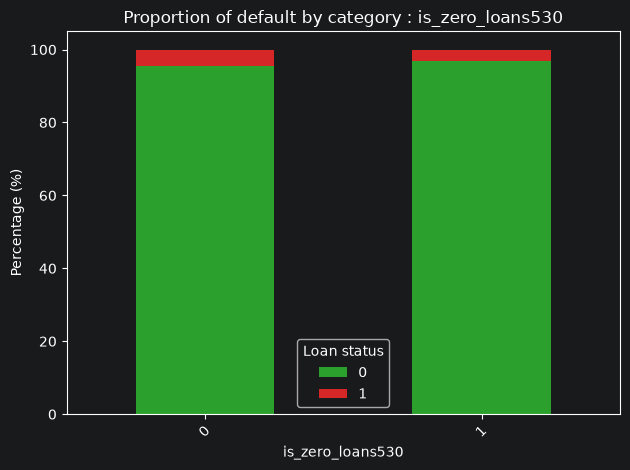

<Figure size 1000x600 with 0 Axes>

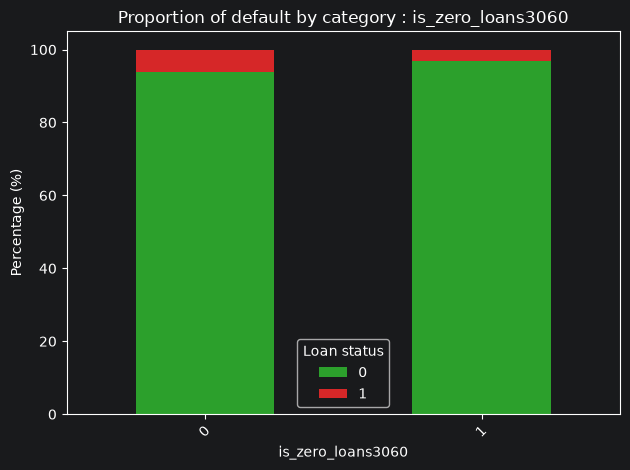

<Figure size 1000x600 with 0 Axes>

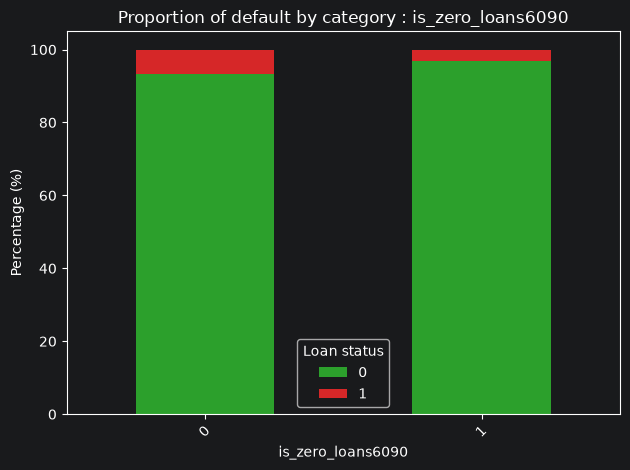

<Figure size 1000x600 with 0 Axes>

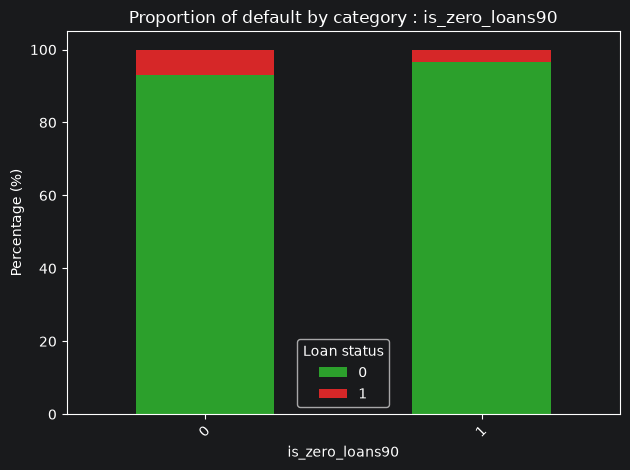

<Figure size 1000x600 with 0 Axes>

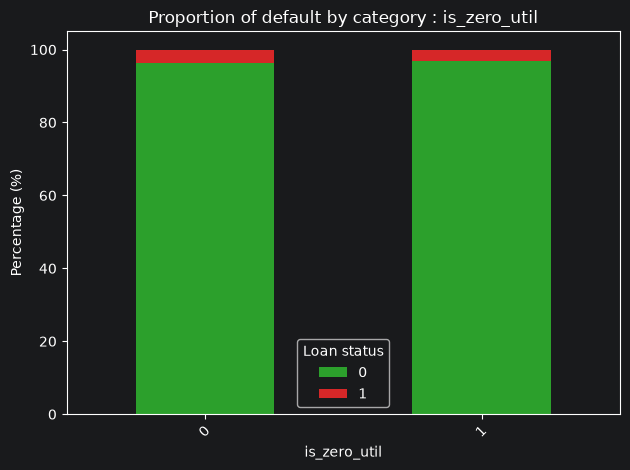

<Figure size 1000x600 with 0 Axes>

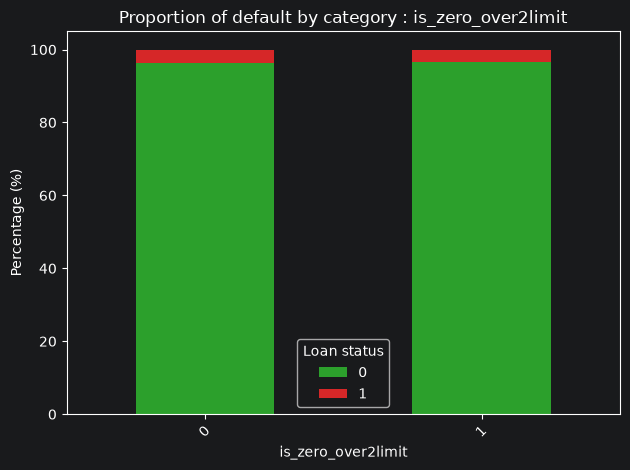

<Figure size 1000x600 with 0 Axes>

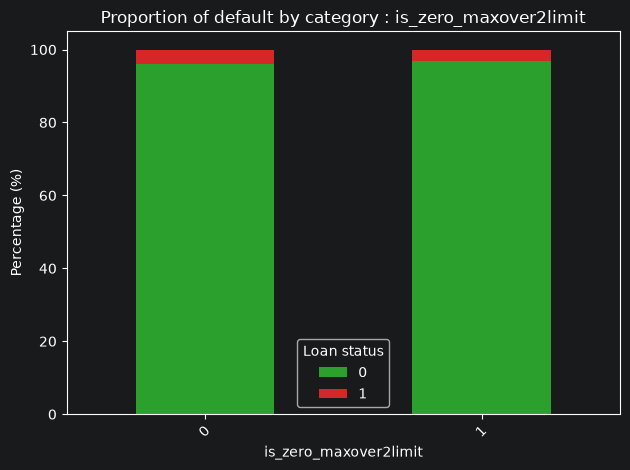

<Figure size 1000x600 with 0 Axes>

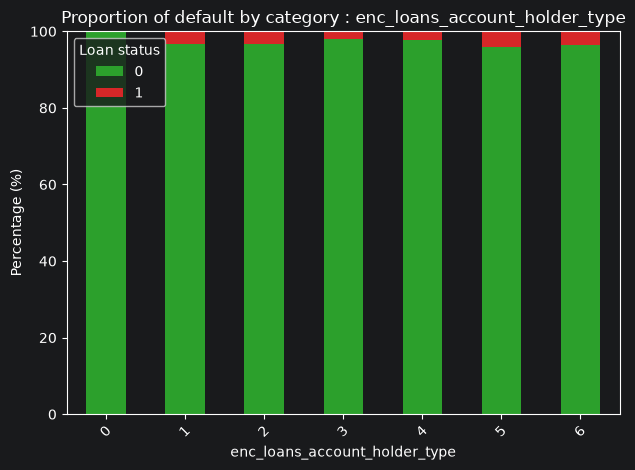

<Figure size 1000x600 with 0 Axes>

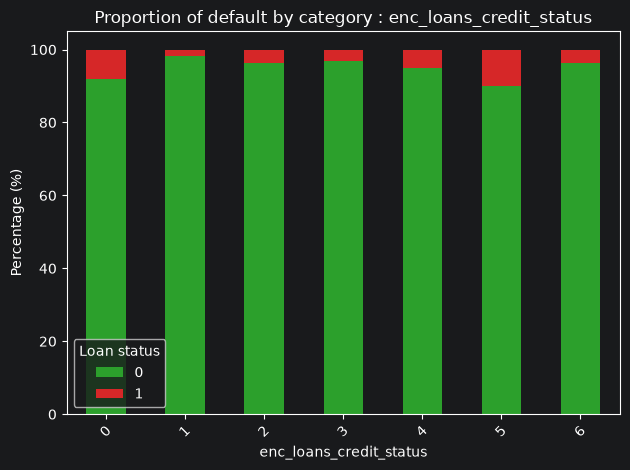

<Figure size 1000x600 with 0 Axes>

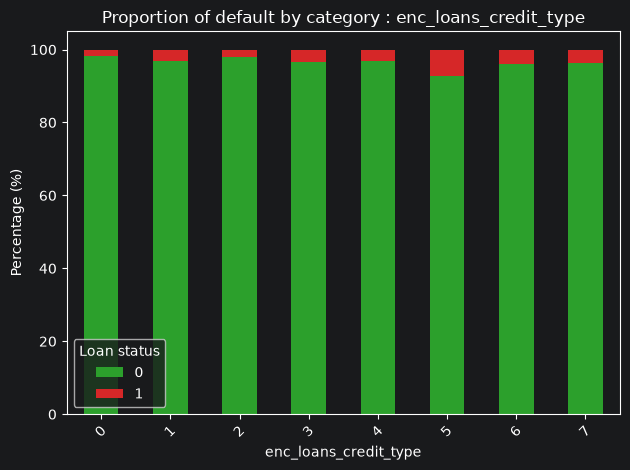

<Figure size 1000x600 with 0 Axes>

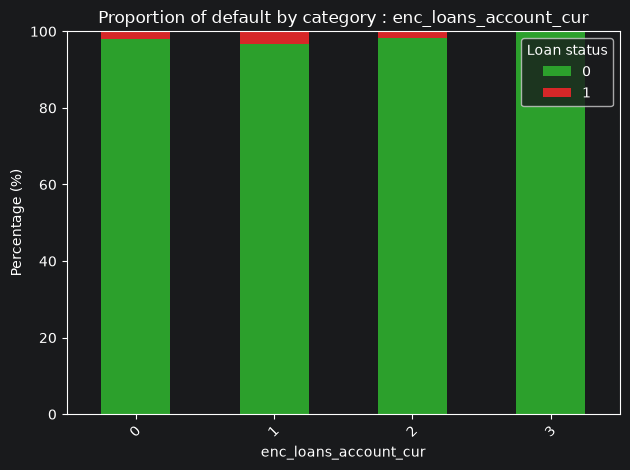

<Figure size 1000x600 with 0 Axes>

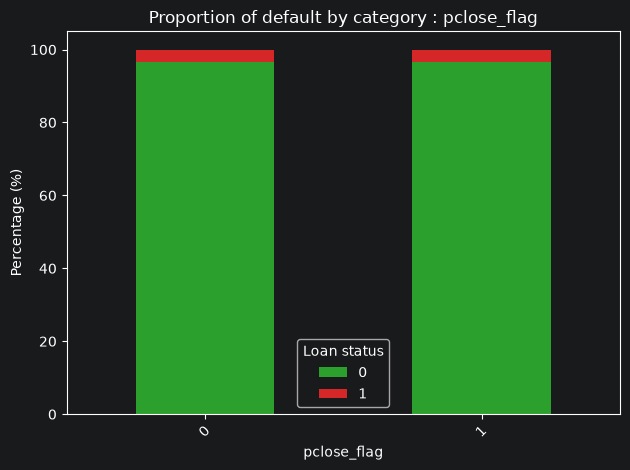

<Figure size 1000x600 with 0 Axes>

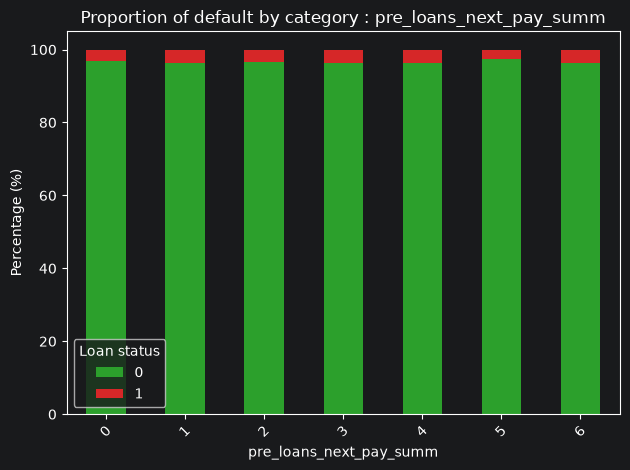

<Figure size 1000x600 with 0 Axes>

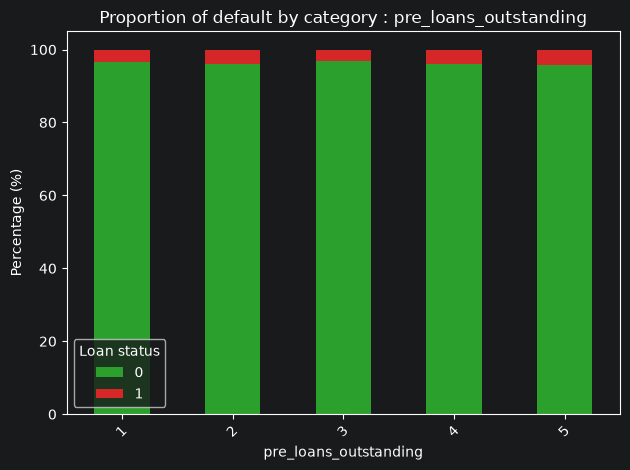

<Figure size 1000x600 with 0 Axes>

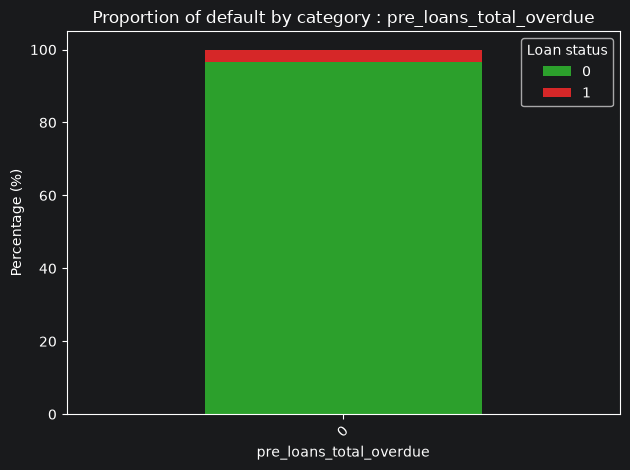

<Figure size 1000x600 with 0 Axes>

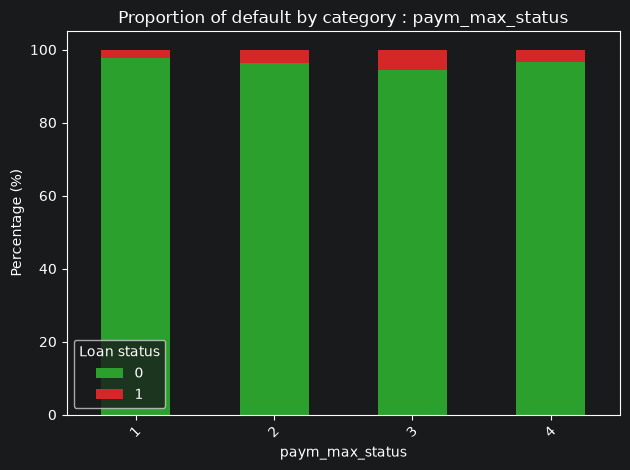

<Figure size 1000x600 with 0 Axes>

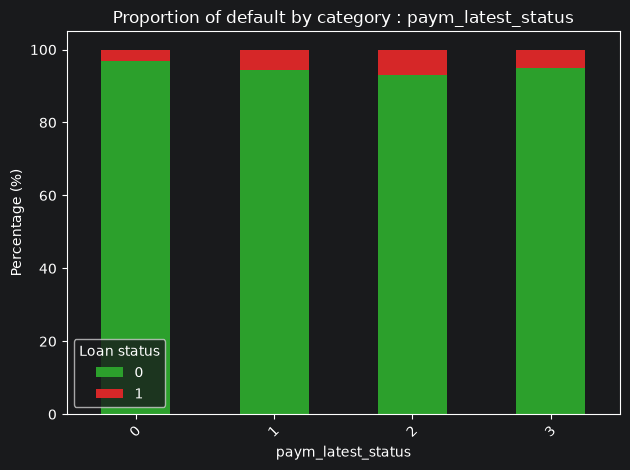

In [24]:
plot_relation_feature_target(df=df_aggregated, categorical=True, features=categorical_features)

## Relations features-features

### Relations numeric-numeric

In [25]:
def pairplot(df: pd.DataFrame, features: list):
    df = df.select(
        pl.col(features)
    ).to_pandas()

    plt.figure(figsize=(10, 7))
    sb.pairplot(data=df)
    plt.show()

<Figure size 1000x700 with 0 Axes>

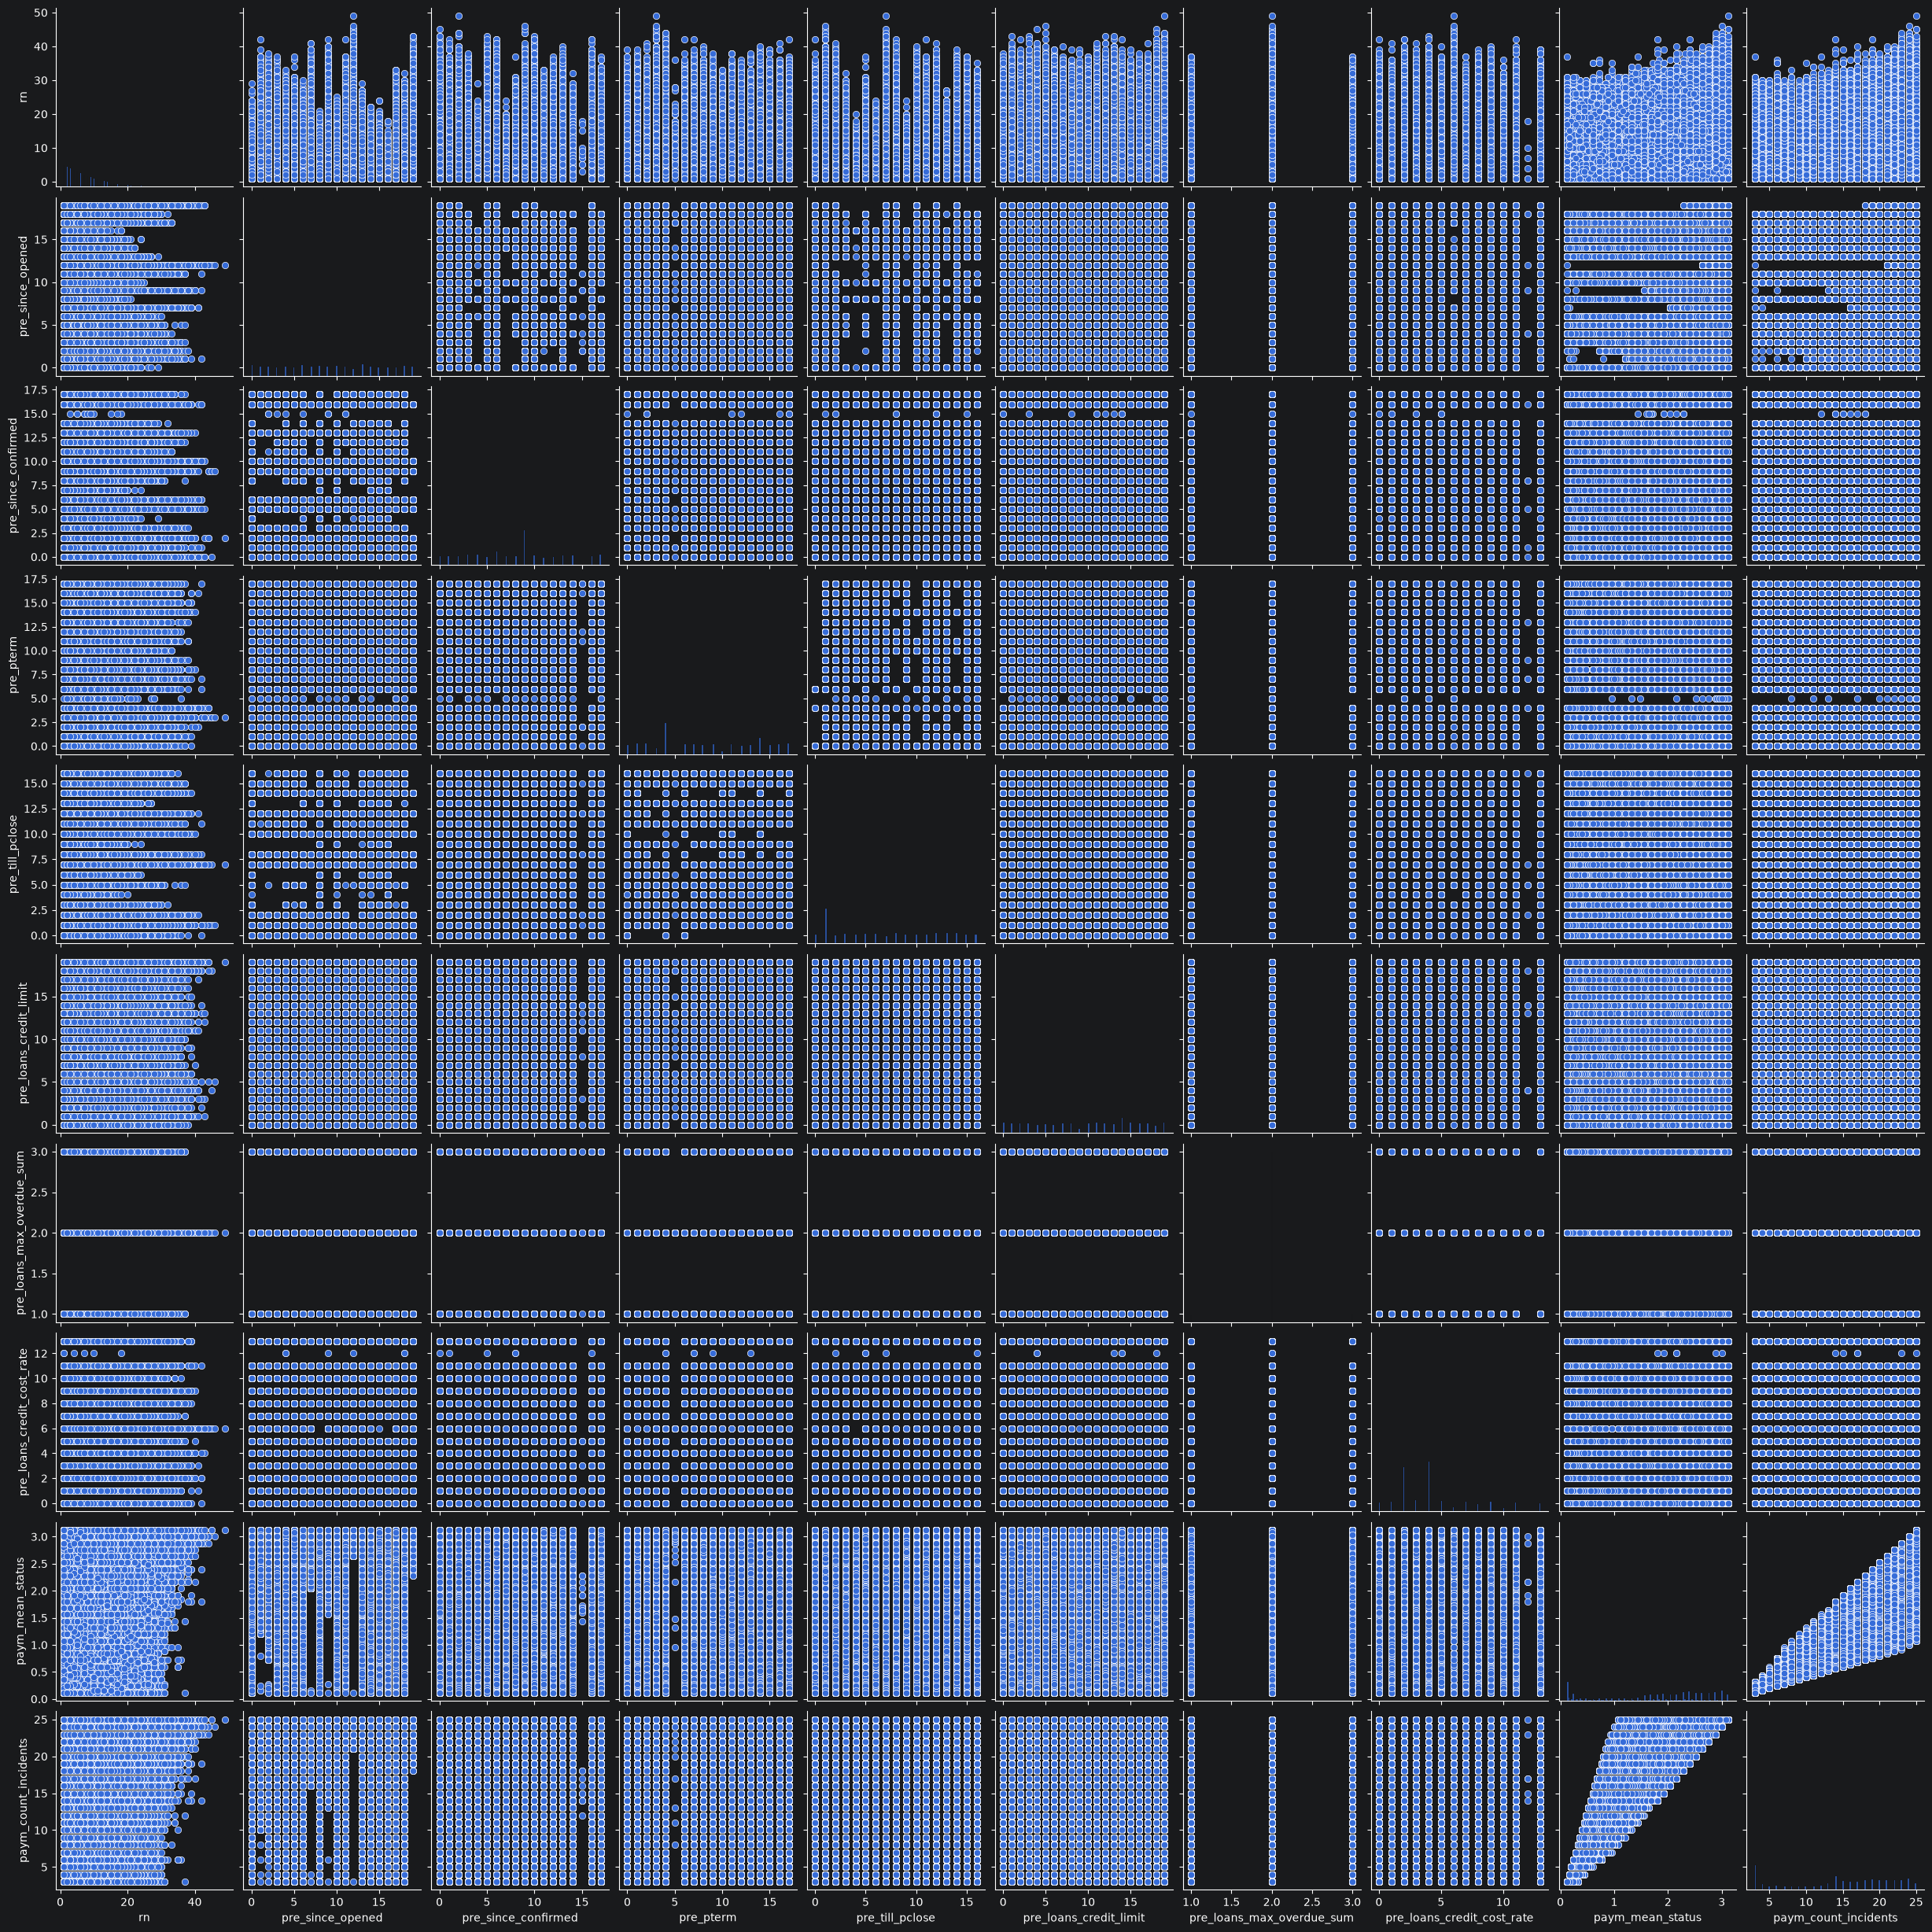

In [26]:
pairplot(df_aggregated, numerical_features)

In [27]:
def plot_correlation(df: pd.DataFrame, features: list):
    df = df.select(
        pl.col(features)
    ).to_pandas()

    plt.figure(figsize=(10, 7))
    sb.heatmap(df.corr(), annot=True)
    plt.show()

- The paym_count_incidents abd the payèmean_status have a big coorelation. Need to treat them

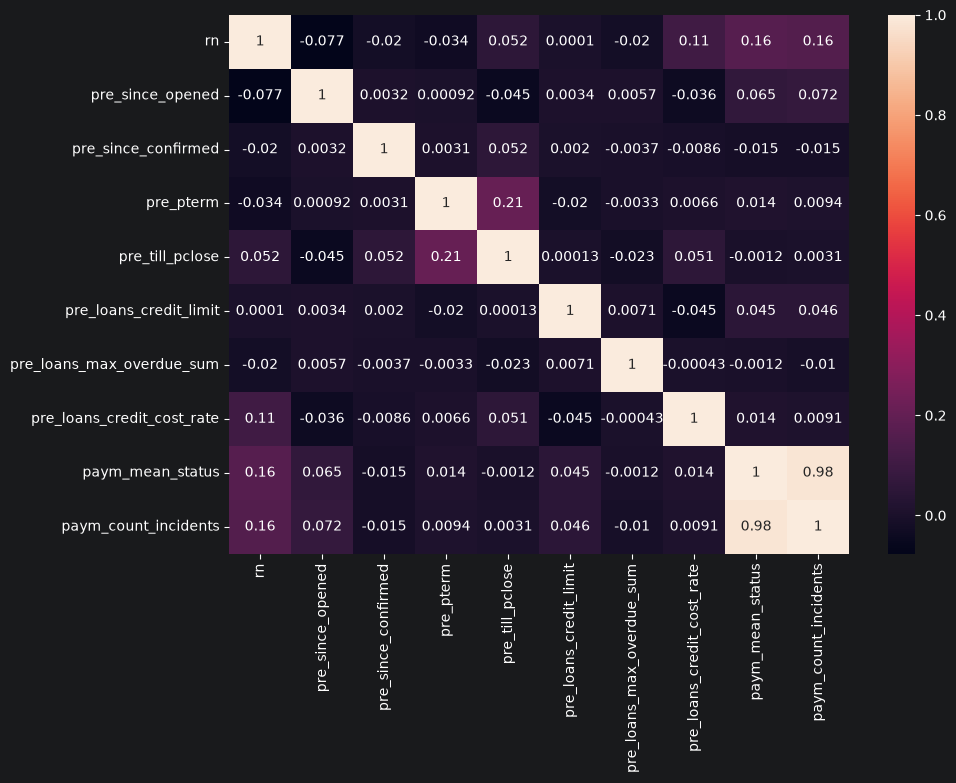

In [28]:
plot_correlation(df_aggregated, numerical_features)

In [29]:
df_new_dataset = df_aggregated.with_columns(
    (pl.col("paym_count_incidents") / pl.col("paym_mean_status")).alias("paym_incidents_over_mean"),
)

In [30]:
numerical_features.append("paym_incidents_over_mean")

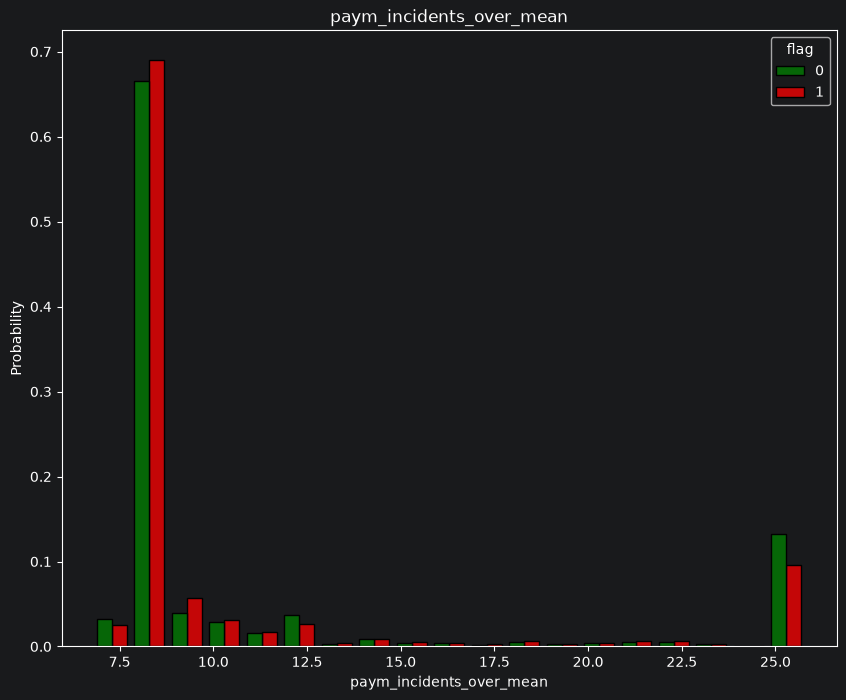

In [31]:
plot_relation_feature_target(df_new_dataset, features=["paym_incidents_over_mean"], categorical=False)

- The new feature has great correlation with the `paym_incidents_over_mean` and `paym_count_incidents`

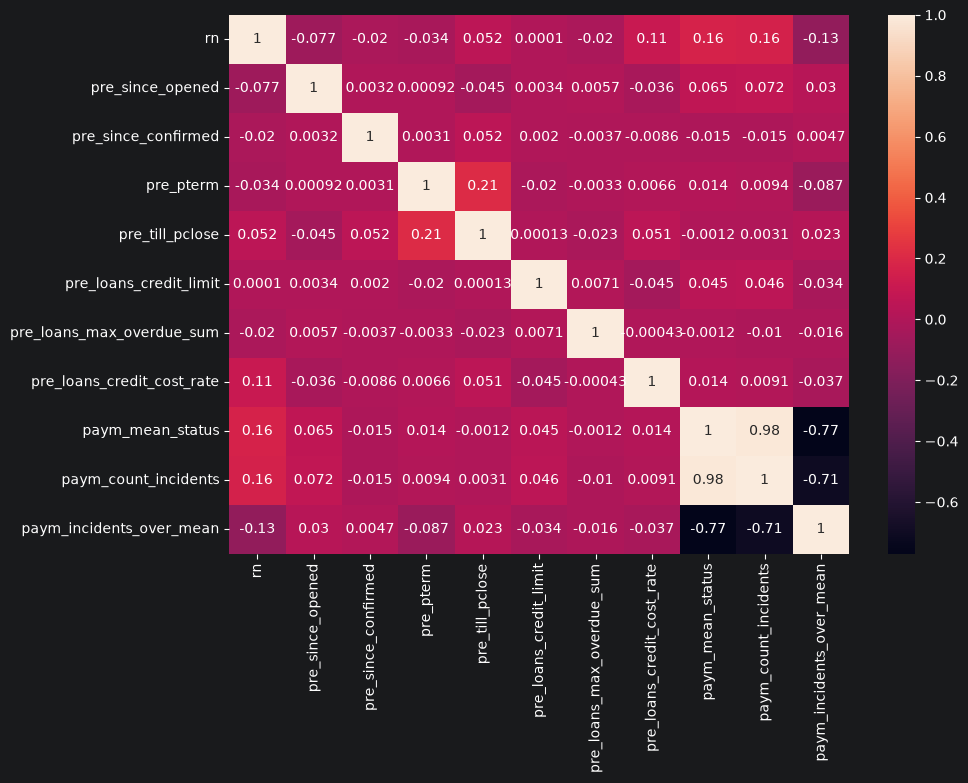

In [32]:
plot_correlation(df=df_new_dataset, features=numerical_features)

### Relations categoric / categoric

In [33]:
def plot_crosstab(df: pl.DataFrame, feature1: str, feature2: str):
    df = df.to_pandas()

    plt.figure(figsize=(10, 5))
    crosstab = pd.crosstab(
            df[feature1],
            df[feature2],
            normalize='all',
            margins=True,
        )
    sb.heatmap(
        crosstab,
        annot=True,
        fmt=".2%",
        cmap='YlGnBu',
        annot_kws={'size': 10}
    )
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f"Crosstab of {feature1} and {feature2}")
    plt.tight_layout()
    plt.show()

In [34]:
from statsmodels.graphics.mosaicplot import mosaic

### Interpretation of overall results
- 92.27% of the loans never exceeded the first level of delinquency (paym_max_status = 0).
- 84.27% of the records are currently in a so-called "healthy" or normalized state (paym_latest_status = 4).
### Key observations by box
- Main segment (77.48%): The (latest = 4, max = 0) bucket accounts for the vast majority of the portfolio. It comprises clients with no significant adverse history who are currently up to date.
- Slight persistent delay (12.73%): The cell (latest = 1, max = 0) represents customers who remained at or returned to a minimal level of delay.
- Partial/total regularization (4.12%): The cell (latest = 4, max = 3) shows that 4.12% of borrowers reached a maximum severity level of 3 (severe deterioration) but managed to return to a healthy current status (4).
- Inconsistency or rare transition ($0.00\%$): The cases (latest = 1, max = 2) or (latest = 1, max = 3) are virtually non-existent ($0.00\%$). A recent status that is more degraded than the maximum status indicates an asynchronous update of the two columns or a specific encoding priority.

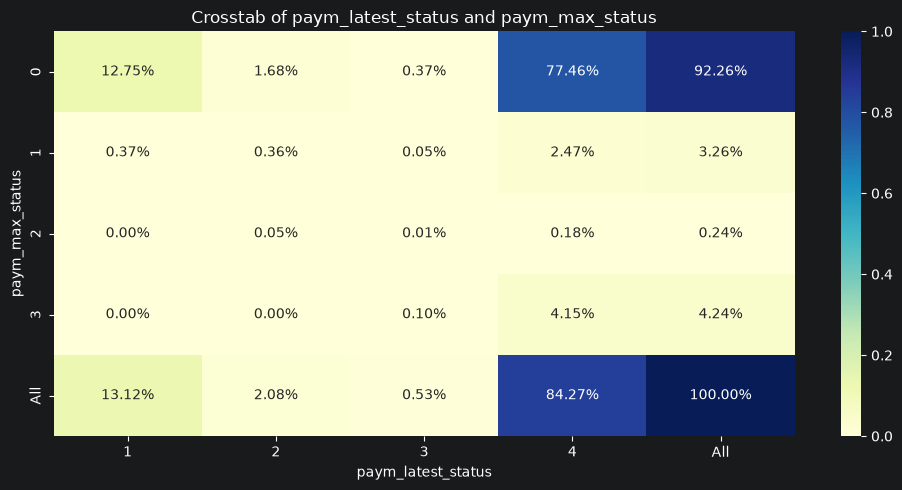

In [35]:
# paym_latest_status x paym_max_status
# Makes it possible to analyze whether customers with a poor recent status (paym_latest_status)
# are consistently those who have experienced significant historical delays (paym_max_status).
plot_crosstab(df_new_dataset, feature1="paym_latest_status", feature2="paym_max_status")

In [36]:
# Analyze whether customers with a poor recent status (paym_latest_status) are consistently
# those who have experienced significant historical delays (paym_max_status).
def plot_mosaic_dynamic(df, feature1: str, feature2: str):
    """Generates a readable mosaic plot with a dynamic palette and automatic hiding of small labels."""
    # 1. Conversion Pandas si nécessaire
    if not isinstance(df, pd.DataFrame):
        df = df.to_pandas()

    # 2. Dynamic generation of a color palette based on feature2 categories
    categories_f2 = df[feature2].astype(str).unique()
    num_colors = len(categories_f2)

    # Use of a viridis or tab10/tab20 palette, depending on the number of categories.
    cmap = plt.get_cmap("tab10" if num_colors <= 10 else "tab20")
    color_map = {
        cat: cmap(i / max(1, num_colors - 1))
        for i, cat in enumerate(categories_f2)
    }

    # 3. Calculation of the minimum size threshold for displaying a label (e.g., > 3% of the total)
    counts = df.groupby([feature1, feature2]).size()
    total_count = len(df)
    threshold = 0.03 * total_count

    def labelizer(key):
        # key is a tuple of values ​​(e.g., ('0', '4'))
        val_f1, val_f2 = str(key[0]), str(key[1])
        # Retrieval of the combination size
        count = counts.get((key[0], key[1]), 0)
        if count == 0:
            # Handling cases where types differ (int vs. str)
            count = counts.get(
                (
                    int(key[0]) if key[0].isdigit() else key[0],
                    int(key[1]) if key[1].isdigit() else key[1],
                ),
                0,
            )

        return f"{val_f1}\n{val_f2}" if count >= threshold else ""

    # 4. Dynamic visual properties
    props = lambda key: {
        "color": color_map.get(str(key[1]), "#888888"),
        "edgecolor": "white",
        "linewidth": 1.2,
    }

    # 5. Graph rendering
    fig, ax = plt.subplots(figsize=(10, 8))

    mosaic(
        df,
        [feature1, feature2],
        title=f"Mosaic Plot : {feature1} vs {feature2}",
        gap=0.015,
        properties=props,
        labelizer=labelizer,
        ax=ax,
    )

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

/home/madeinheaven/PycharmProjects/credit_default_card/.venv/lib/python3.12/site-packages/statsmodels/graphics/mosaicplot.py:901: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


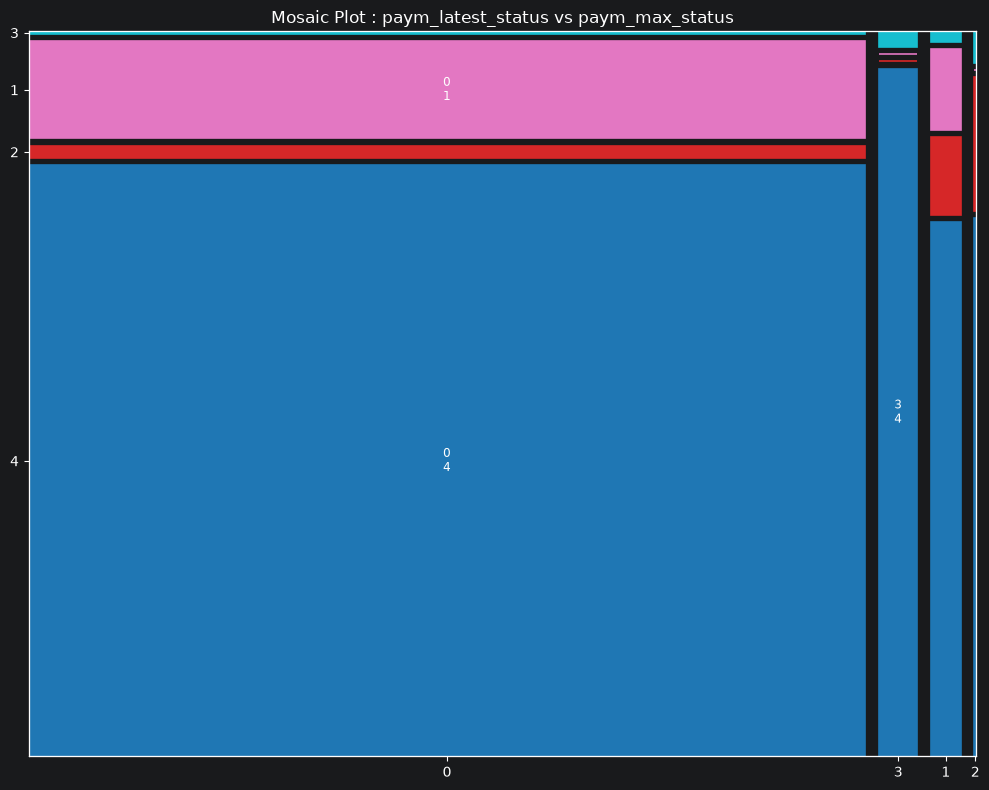

In [37]:
plot_mosaic_dynamic(df=df_new_dataset, feature1="paym_latest_status", feature2="paym_max_status")

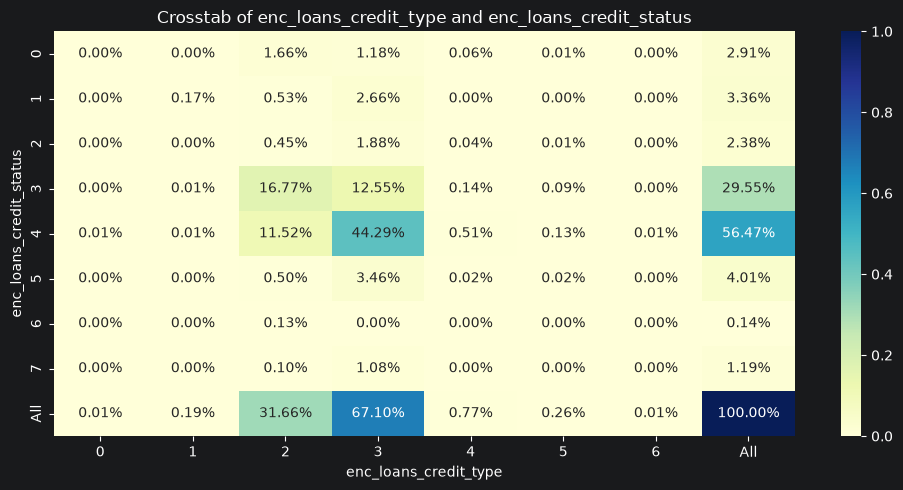

In [38]:
# enc_loans_credit_type x enc_loans_credit_status
# Identify the types of credit (e.g., mortgage, consumer, revolving) that show
# the highest rates of account closure, default, or legal action.

plot_crosstab(df_new_dataset, "enc_loans_credit_type", "enc_loans_credit_status")

/home/madeinheaven/PycharmProjects/credit_default_card/.venv/lib/python3.12/site-packages/statsmodels/graphics/mosaicplot.py:901: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


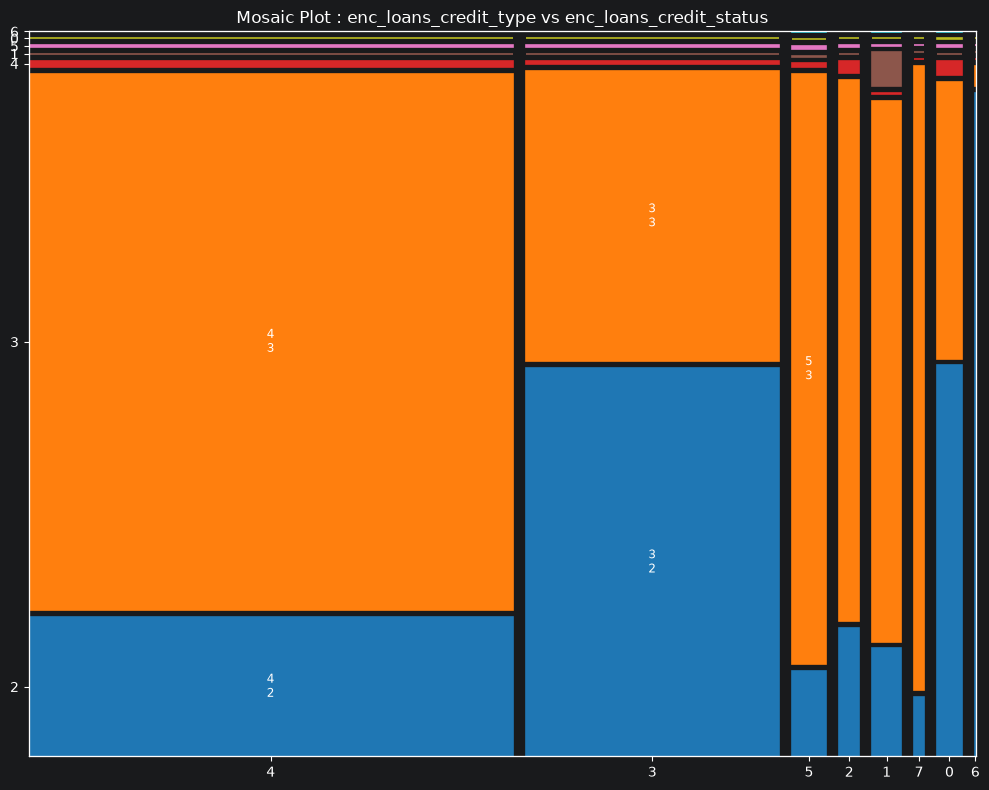

In [39]:
plot_mosaic_dynamic(df_new_dataset, "enc_loans_credit_type", "enc_loans_credit_status")

1. Overall distribution (All rows and columns)
- Dominance of enc_loans_credit_status = 1: 97.61% of the sample has a status of 1. Status 0 applies to only 2.39% of the cases.
- Focus on two modalities of is_zero_loans90:
    - Category 3: 67.12% of the total.
    - Category 2: 31.65% of the total.
    - Other categories ($0, 1, 4, 5, 6$): Together, they represent less than $1.3\%$ of the dataset.
2. Cross-analysis of the two major categories
- Combination (status = 1, is_zero_loans90 = 3): This is the dominant block in the dataset, accounting for 65.42% of the total population (darkest blue area on the heatmap / large orange block on the mosaic plot).
- Combination (status = 1, is_zero_loans90 = 2): Second most significant block, accounting for 31.27% of the population (green area on the heatmap / blue block on the mosaic plot).
3. Statistical and business interpretation
- Absence of a clear separating effect: The distribution of the categories of is_zero_loans90 (primarily split between 2 and 3) is virtually identical, regardless of whether enc_loans_credit_status is 0 or 1.
- Low predictive power: For a classification model, the `is_zero_loans90` variable alone contributes very little variance regarding credit status, as the vast majority of cases (97.61%) fall into the same primary status class.

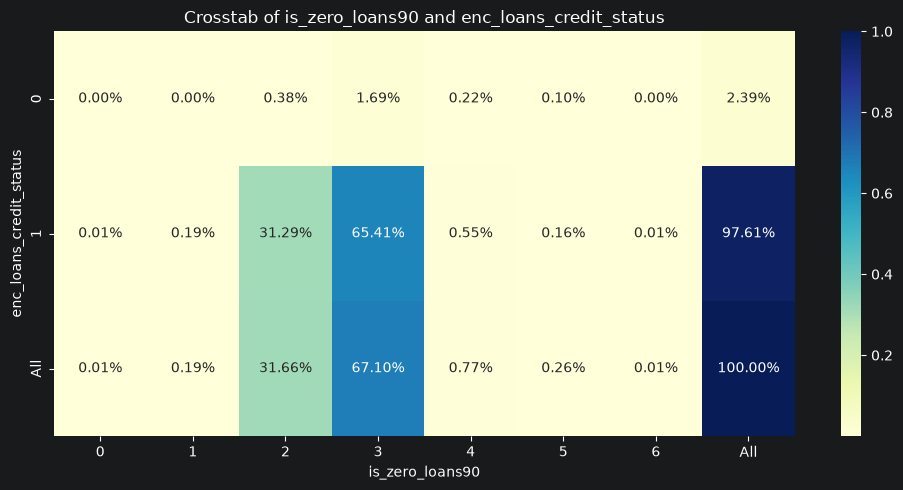

/home/madeinheaven/PycharmProjects/credit_default_card/.venv/lib/python3.12/site-packages/statsmodels/graphics/mosaicplot.py:901: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


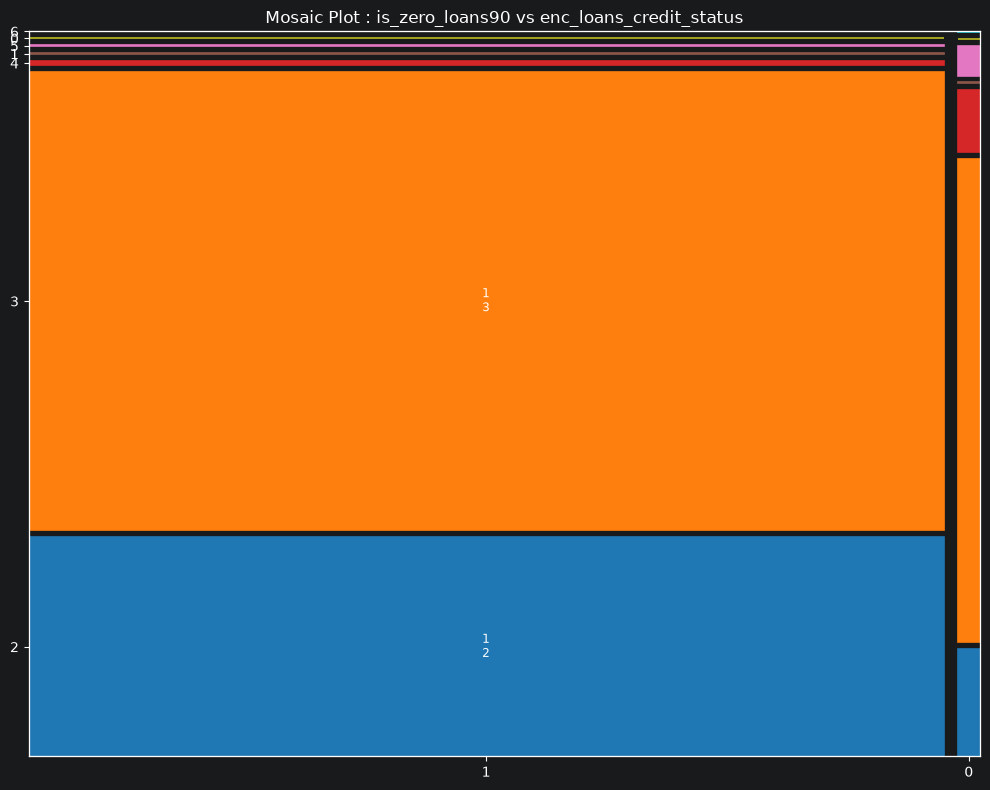

In [40]:
# is_zero_loans90 x enc_loans_credit_status
# Assess the severity: does the absence of delinquencies of 90+ days (is_zero_loans90 = 1) guarantee a healthy credit status?
plot_crosstab(df_new_dataset, "is_zero_loans90", "enc_loans_credit_status")
plot_mosaic_dynamic(df_new_dataset, "is_zero_loans90", "enc_loans_credit_status")

1. Overall distribution (All rows and columns)
- Overwhelming dominance of pclose_flag = 1: 98.66% of the entire dataset is concentrated at the value 1 for pclose_flag (top blue line of the heatmap / giant cyan and blue column on the left of the mosaic plot).
- Breakdown by account type (enc_loans_account_holder_type):
    - Type 0: $85{,}05\%$ of the global population.
    - Type 1: $14{,}95\%$ of the global population.
2. Key findings on the cross-analysis of variables
- Main holding (holder_type = 0, pclose_flag = 1): Represents 84.07% of the total dataset. This is the main block of the portfolio (blue box on the left of the heatmap).
- Second mass (holder_type = 1, pclose_flag = 1): Represents 14.58% of the cases (yellow-green cell in the middle of the heatmap).
- Marginal values ​​of pclose_flag ($0, 2, 3, 4, 5, 6$): All these other aggregated values ​​account for less than $1.34\%$ of the dataset. Only the value 3 stands out slightly at $0.81\%$.
3. Functional interpretation
- Lack of discriminatory power: The distribution between account types 0 (85%) and 1 (15%) remains strictly identical, whether one looks at the `pclose_flag = 1` segment or the other segments.
- Statistical uselessness in its current state: The `pclose_flag` variable is quasi-constant (98.66% in a single class). If used raw in machine learning, it will provide virtually no useful variance to the model.

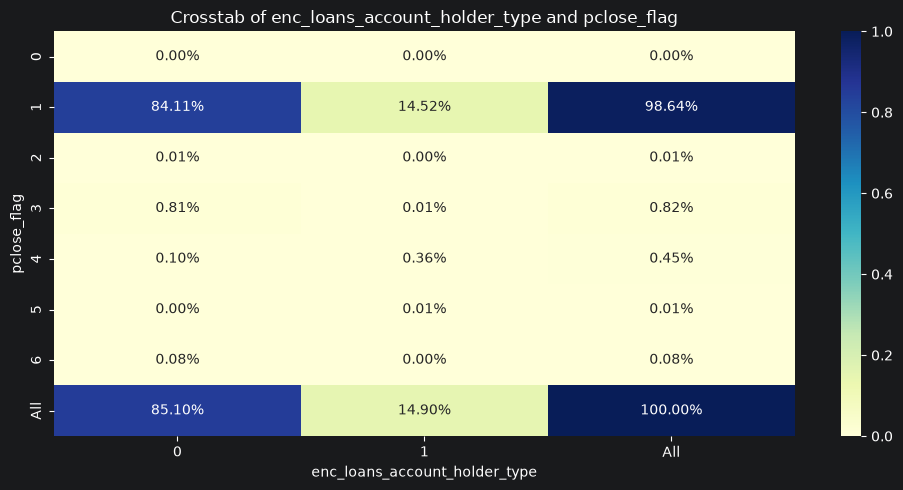

/home/madeinheaven/PycharmProjects/credit_default_card/.venv/lib/python3.12/site-packages/statsmodels/graphics/mosaicplot.py:901: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


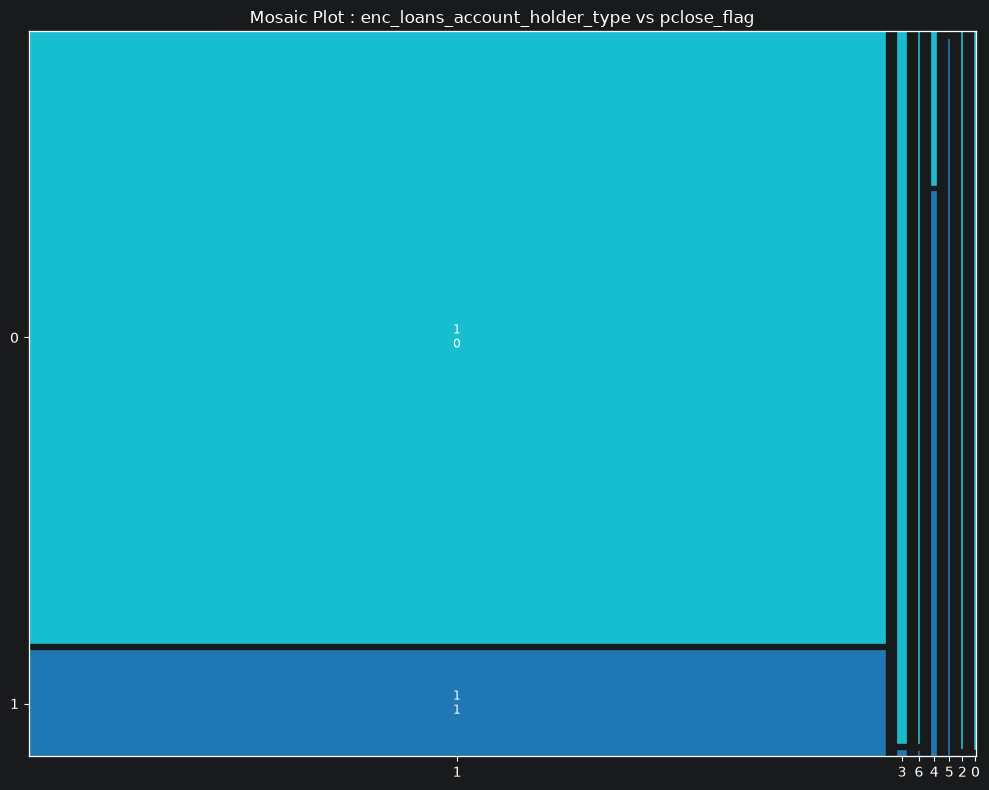

In [41]:
# enc_loans_account_holder_type x pclose_flag
# Compare whether the account type (e.g., primary holder vs. co-borrower/guarantor) influences early loan closure behavior.
plot_crosstab(df_new_dataset, "enc_loans_account_holder_type", "pclose_flag")
plot_mosaic_dynamic(df_new_dataset, "enc_loans_account_holder_type", "pclose_flag")

### Actions to do:
- Delete the pclose_flag:
    - Why?: With 98.66% of values ​​concentrated in category 1, this variable exhibits near-zero variance. In a decision tree or linear model, it offers no discriminative power and simply risks introducing noise or leading to overfitting.

### Feature engineering:
- Manipulate the serie of is_zero_loan:
    - Composite consistency score (Sum/Average):
        - total_zero_loans_count = is_zero_loans30 + is_zero_loans60 + is_zero_loans90 + ...
        - A high score indicates a consistently incident-free profile, capturing the customer's overall behavior in a single metric.
    - Global "Absolute Zero Defect" flag (logical AND):
        - Create a boolean variable `is_perfect_history` = 1 if all `is_zero_loan` variables equal 1 (or 0, depending on the encoding), and 0 otherwise.
    - Maybe a PCA:
        - Since these variables share a very high level of common variance, you can apply Multiple Correspondence Analysis (MCA) or PCA and retain only the first principal component.

In [45]:
import polars as pl
import polars.selectors as cs


def create_zero_loan(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        # 1. Somme horizontale de toutes les colonnes qui commencent par 'is_zero_loan'
        pl.sum_horizontal(cs.starts_with("is_zero_loan")).alias(
            "total_zero_loans_count"
        )
    ).with_columns(
        # 2. Vérification si le total vaut 1 (ou > 0 selon ta logique métier)
        (pl.col("total_zero_loans_count") == 1)
        .cast(pl.Int8)
        .alias("absolute_zero_defect")
    )

    return df

In [47]:
new_dataset = create_zero_loan(df=df_new_dataset)
new_dataset

id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag,paym_max_status,paym_mean_status,paym_count_incidents,paym_latest_status,paym_incidents_over_mean,total_zero_loans_count,absolute_zero_defect
i32,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i8,i16,f64,u32,i16,f64,i16,i8
514515,9,19,9,4,1,6,1,3,0,2,1,6,16,5,4,8,1,1,1,1,1,12,2,17,0,1,1,0,0,0,0,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,0,4,2.64,21,0,7.954545,5,0
719549,8,17,13,16,11,1,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,3,1,0,0,4,3.0,24,0,8.0,5,0
540373,12,19,9,4,1,14,5,4,0,2,5,6,16,5,4,8,1,1,1,1,1,4,2,17,0,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,1,0,4,2.88,23,0,7.986111,5,0
141438,11,1,9,2,12,8,4,2,0,2,0,6,16,5,4,8,1,1,1,1,1,0,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,4,1.8,14,0,7.777778,5,0
1013450,3,0,10,0,12,11,0,5,0,2,7,6,13,5,4,8,1,0,0,1,1,6,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2,1,0,0,0,1,0,1,1,1,0,1,1,2,3,1,0,0,2,0.36,8,0,22.222222,3,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2858884,8,12,16,4,1,4,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,6,1,1,0,4,2.88,23,0,7.986111,5,0
440795,6,7,9,4,1,12,2,3,0,1,7,6,16,5,4,8,1,0,1,1,1,16,2,0,1,1,0,0,0,1,1,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,0,4,2.36,20,0,8.474576,4,0
1361955,19,1,9,14,10,14,3,5,0,2,4,6,16,5,4,8,1,1,1,1,1,18,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,4,1.92,15,0,7.8125,5,0


#### total_zero_loans_count

- Monotonically decreasing risk relationship: As the total number of zero-balance loans increases (from 0 to 5), the proportion of defaults (red section) steadily decreases.
- Minimum default rate for category 5: Customers with a value of 5 show the highest repayment proportion (green) and the lowest default rate.

#### Implications for the machine learning model

- Discriminatory power (IV/Predictive Power): The variable possesses a relevant predictive signal, as the distribution of the target varies progressively across the categories.
- Encoding / Feature Engineering: Given the observed strict monotonicity, this variable can be used directly as an ordinal or continuous numerical variable without requiring complex binning.

#### absolute_zero_defect

- Reversal of the trend: Contrary to what might be expected if the variable targeted low-risk profiles, Category 1 shows a higher default rate (red)—approximately 7–8%—than Category 0 (approximately 3–4%).
- Discriminatory signal: Even though it is a simple binary indicator, the roughly twofold difference in default rates provides clear discriminatory power for the model.

#### ML Recommendation

- Redondance / Colinéarité : Comme cette variable est une transformation directe de total_zero_loans_count, elle risque d'être fortement corrélée avec elle. Si tu utilises des modèles linéaires ou logistiques, conserve uniquement celle qui a le meilleur Information Value (IV). Les modèles d'arbres (XGBoost, LightGBM) géreront mieux les deux, mais la garder n'apporte que très peu d'information supplémentaire.

<Figure size 1000x600 with 0 Axes>

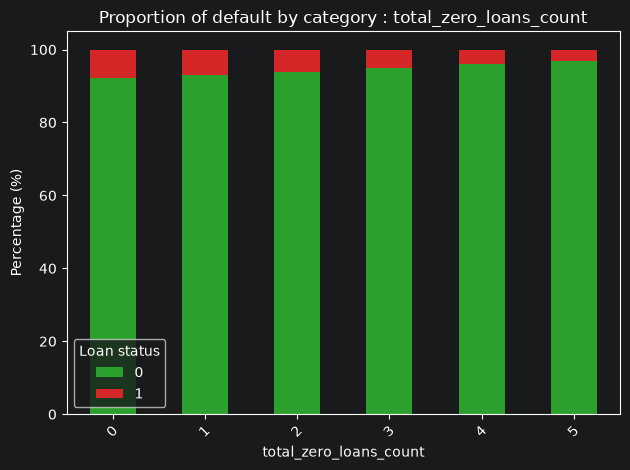

<Figure size 1000x600 with 0 Axes>

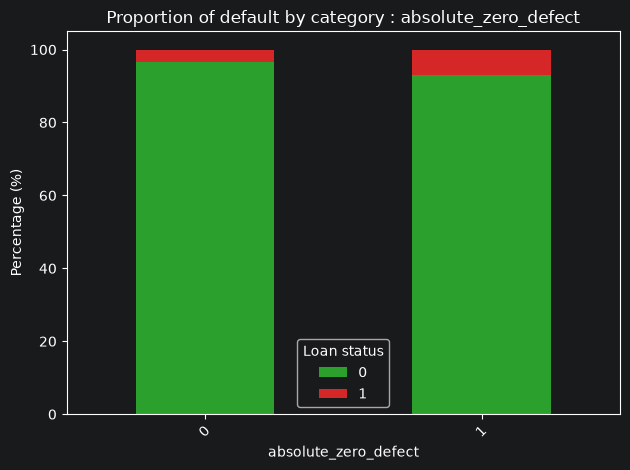

In [49]:
plot_relation_feature_target(df=new_dataset, features=["total_zero_loans_count", "absolute_zero_defect"], categorical=True)

In [50]:
new_dataset.columns

['id',
 'rn',
 'pre_since_opened',
 'pre_since_confirmed',
 'pre_pterm',
 'pre_till_pclose',
 'pre_loans_credit_limit',
 'pre_loans_next_pay_summ',
 'pre_loans_outstanding',
 'pre_loans_total_overdue',
 'pre_loans_max_overdue_sum',
 'pre_loans_credit_cost_rate',
 'pre_loans5',
 'pre_loans530',
 'pre_loans3060',
 'pre_loans6090',
 'pre_loans90',
 'is_zero_loans5',
 'is_zero_loans530',
 'is_zero_loans3060',
 'is_zero_loans6090',
 'is_zero_loans90',
 'pre_util',
 'pre_over2limit',
 'pre_maxover2limit',
 'is_zero_util',
 'is_zero_over2limit',
 'is_zero_maxover2limit',
 'enc_paym_0',
 'enc_paym_1',
 'enc_paym_2',
 'enc_paym_3',
 'enc_paym_4',
 'enc_paym_5',
 'enc_paym_6',
 'enc_paym_7',
 'enc_paym_8',
 'enc_paym_9',
 'enc_paym_10',
 'enc_paym_11',
 'enc_paym_12',
 'enc_paym_13',
 'enc_paym_14',
 'enc_paym_15',
 'enc_paym_16',
 'enc_paym_17',
 'enc_paym_18',
 'enc_paym_19',
 'enc_paym_20',
 'enc_paym_21',
 'enc_paym_22',
 'enc_paym_23',
 'enc_paym_24',
 'enc_loans_account_holder_type',
 'enc

In [52]:
numerical_features.append("total_zero_loans_count")

In [58]:
def drop_useless_columns(df: pl.DataFrame) -> pl.DataFrame:
    df = df.drop(selectors.starts_with("is_zero_loan"))
    df = df.drop(pl.col("pre_loans_total_overdue"))
    df = df.drop(pl.col("absolute_zero_defect"))
    return  df

In [59]:
data = drop_useless_columns(df=new_dataset)

### Feature engineering for enc_payment
- Total count / frequency of each status: Count how many times the customer held status 0, 1, 2, or 3 over the 24-month period.
- Most recent status vs. history: Retain the status from the last month (enc_paym_0) and calculate the average or maximum for the remainder (enc_paym_1 to 23).
- Trend (Deterioration/Improvement): Calculate the difference between the average of the last 3 months and the average of the last 12 months.

In [62]:
import polars as pl


def add_paym_features(df: pl.DataFrame) -> pl.DataFrame:
    cols_24m = [f"enc_paym_{i}" for i in range(24) if f"enc_paym_{i}" in df.columns]
    cols_1_to_23 = [
        f"enc_paym_{i}" for i in range(1, 24) if f"enc_paym_{i}" in df.columns
    ]
    cols_3m = [f"enc_paym_{i}" for i in range(3) if f"enc_paym_{i}" in df.columns]
    cols_12m = [f"enc_paym_{i}" for i in range(12) if f"enc_paym_{i}" in df.columns]

    df = df.with_columns(
        # 1. Frequency of each status (0, 1, 2, 3) over the 24 months
        *[
            pl.sum_horizontal(
                [(pl.col(c) == status).cast(pl.Int16) for c in cols_24m]
            ).alias(f"count_paym_status_{status}_24m")
            for status in [0, 1, 2, 3]
        ],
       # 2. Most recent status vs. Historical data (Average and Max over months 1 to 23)
        pl.concat_list([pl.col(c) for c in cols_1_to_23])
        .list.mean()
        .alias("paym_hist_mean_1_23"),
        pl.concat_list([pl.col(c) for c in cols_1_to_23])
        .list.max()
        .alias("paym_hist_max_1_23"),
        # 3. Trend (3-Month Average vs. 12-Month Average)
        (
            pl.concat_list([pl.col(c) for c in cols_3m]).list.mean()
            - pl.concat_list([pl.col(c) for c in cols_12m]).list.mean()
        ).alias("paym_trend_3m_vs_12m"),
    )

    return df

- Status counting: sum_horizontal sums the boolean flags (col == status) across all columns to return count_paym_status_0_24m, count_paym_status_1_24m, etc.
- Historical Average / Max: `concat_list().list.mean()` allows you to calculate the row-wise average or maximum for the subset of columns from 1 to 23 without affecting `enc_paym_0`.
- Trend ($3M – $12M): A positive value indicates a recent deterioration in payment behavior (status worsening over the last 3 months), while a negative value indicates an improvement.

In [63]:
new_dataset = add_paym_features(new_dataset)

In [64]:
new_dataset

id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_till_pclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,flag,paym_max_status,paym_mean_status,paym_count_incidents,paym_latest_status,paym_incidents_over_mean,total_zero_loans_count,absolute_zero_defect,count_paym_status_0_24m,count_paym_status_1_24m,count_paym_status_2_24m,count_paym_status_3_24m,paym_hist_mean_1_23,paym_hist_max_1_23,paym_trend_3m_vs_12m
i32,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i16,i8,i16,f64,u32,i16,f64,i16,i8,i16,i16,i16,i16,f64,i16,f64
514515,9,19,9,4,1,6,1,3,0,2,1,6,16,5,4,8,1,1,1,1,1,12,2,17,0,1,1,0,0,0,0,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,0,4,2.64,21,0,7.954545,5,0,4,0,0,18,2.695652,4,-2.083333
719549,8,17,13,16,11,1,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,3,1,0,0,4,3.0,24,0,8.0,5,0,1,0,0,21,3.086957,4,-0.833333
540373,12,19,9,4,1,14,5,4,0,2,5,6,16,5,4,8,1,1,1,1,1,4,2,17,0,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,1,0,4,2.88,23,0,7.986111,5,0,2,0,0,20,2.956522,4,-1.583333
141438,11,1,9,2,12,8,4,2,0,2,0,6,16,5,4,8,1,1,1,1,1,0,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,4,1.8,14,0,7.777778,5,0,11,0,0,11,1.782609,4,-0.333333
1013450,3,0,10,0,12,11,0,5,0,2,7,6,13,5,4,8,1,0,0,1,1,6,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2,1,0,0,0,1,0,1,1,1,0,1,1,2,3,1,0,0,2,0.36,8,0,22.222222,3,0,17,6,1,0,0.347826,2,-0.083333
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2858884,8,12,16,4,1,4,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,6,1,1,0,4,2.88,23,0,7.986111,5,0,2,0,0,20,2.956522,4,-1.583333
440795,6,7,9,4,1,12,2,3,0,1,7,6,16,5,4,8,1,0,1,1,1,16,2,0,1,1,0,0,0,1,1,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,0,4,2.36,20,0,8.474576,4,0,5,2,0,15,2.391304,4,-1.166667
1361955,19,1,9,14,10,14,3,5,0,2,4,6,16,5,4,8,1,1,1,1,1,18,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,4,1.92,15,0,7.8125,5,0,10,0,0,12,1.913043,4,-0.583333


In [66]:
for i in range(4):
    categorical_features.append(f"count_paym_status_{i}_24m")
categorical_features.append("paym_hist_max_1_23")

In [70]:
count_paym_list = [f"count_paym_status_{i}_24m" for i in range(4)]

#### Excellent

<Figure size 1000x600 with 0 Axes>

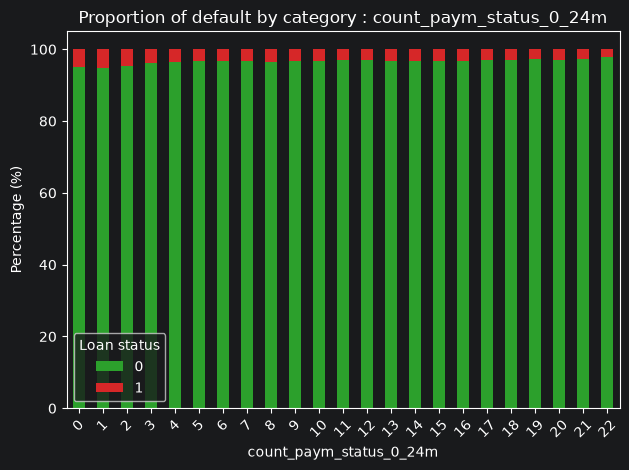

<Figure size 1000x600 with 0 Axes>

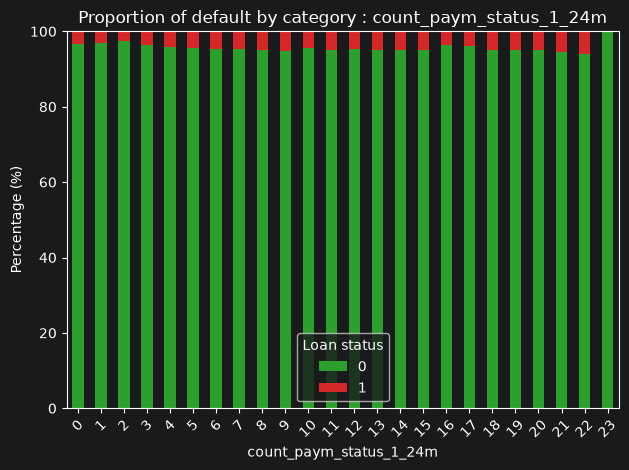

<Figure size 1000x600 with 0 Axes>

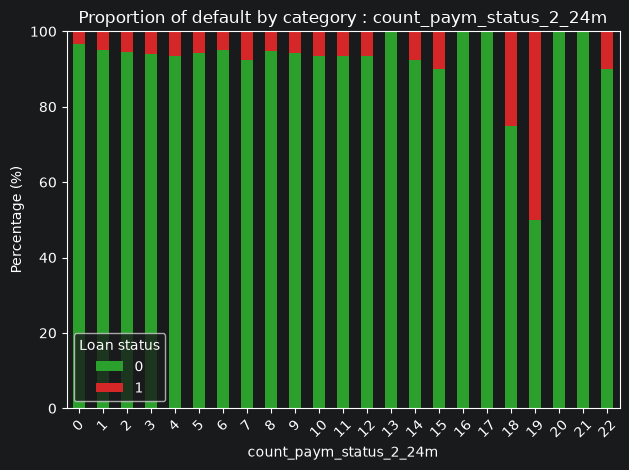

<Figure size 1000x600 with 0 Axes>

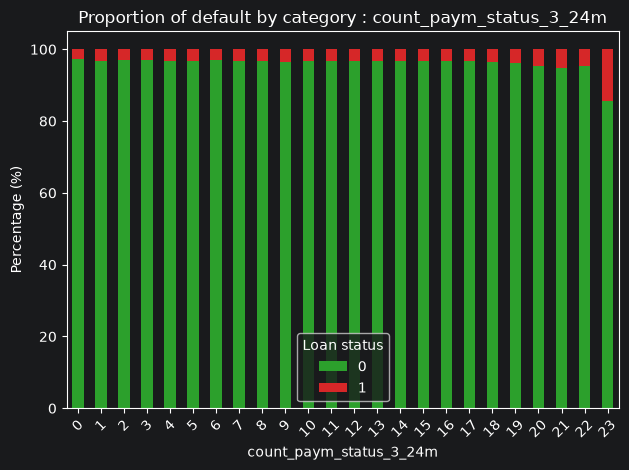

In [71]:
plot_relation_feature_target(df=new_dataset, features=count_paym_list, categorical=True)

In [72]:
for i in range(24):
    categorical_features.remove(f"enc_paym_{i}")

In [77]:
numerical_features.append("paym_trend_3m_vs_12m")
numerical_features.append("paym_hist_mean_1_23")

In [74]:
categorical_features

['enc_paym_24',
 'is_zero_loans5',
 'is_zero_loans530',
 'is_zero_loans3060',
 'is_zero_loans6090',
 'is_zero_loans90',
 'is_zero_util',
 'is_zero_over2limit',
 'is_zero_maxover2limit',
 'enc_loans_account_holder_type',
 'enc_loans_credit_status',
 'enc_loans_credit_type',
 'enc_loans_account_cur',
 'pclose_flag',
 'pre_loans_next_pay_summ',
 'pre_loans_outstanding',
 'pre_loans_total_overdue',
 'paym_max_status',
 'paym_latest_status',
 'count_paym_status_0_24m',
 'count_paym_status_1_24m',
 'count_paym_status_2_24m',
 'count_paym_status_3_24m',
 'count_paym_status_0_24m',
 'count_paym_status_1_24m',
 'count_paym_status_2_24m',
 'count_paym_status_3_24m',
 'paym_hist_max_1_23']

In [78]:
numerical_features

['rn',
 'pre_since_opened',
 'pre_since_confirmed',
 'pre_pterm',
 'pre_till_pclose',
 'pre_loans_credit_limit',
 'pre_loans_max_overdue_sum',
 'pre_loans_credit_cost_rate',
 'paym_mean_status',
 'paym_count_incidents',
 'paym_incidents_over_mean',
 'total_zero_loans_count',
 'paym_trend_3m_vs_12m',
 'paym_hist_mean_1_23']

In [81]:
import math
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns


def plot_all_cat_num_distributions(
    df: pl.DataFrame, pairs: list[tuple[str, str]] = None
):

    if pairs is None:
        pairs = [
            ("enc_loans_credit_type", "pre_loans_credit_limit"),
            ("enc_loans_credit_status", "pre_loans_total_overdue"),
            ("paym_latest_status", "paym_trend_3m_vs_12m"),
            ("pclose_flag", "pre_till_pclose"),
            ("pclose_flag", "total_zero_loans_count"),
            ("enc_loans_credit_status", "paym_count_incidents"),
            ("enc_loans_account_holder_type", "pre_loans_credit_cost_rate"),
            ("paym_max_status", "paym_hist_mean_1_23"),
        ]

    valid_pairs = [
        (cat, num)
        for cat, num in pairs
        if cat in df.columns and num in df.columns
    ]

    if not valid_pairs:
        print("No valid pair found in the DataFrame columns.")
        return

    n_pairs = len(valid_pairs)
    cols = 2
    rows = math.ceil(n_pairs / cols)

    pdf = df.select(
        list({col for pair in valid_pairs for col in pair})
    ).to_pandas()

    plt.style.use("dark_background")
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten() if n_pairs > 1 else [axes]

    for i, (cat_col, num_col) in enumerate(valid_pairs):
        ax = axes[i]
        sns.boxplot(
            data=pdf,
            x=cat_col,
            y=num_col,
            hue=cat_col,
            legend=False,
            ax=ax,
            palette="Set2",
            showfliers=False,
        )
        ax.set_title(
            f"{num_col} par {cat_col}", fontsize=12, fontweight="bold", pad=10
        )
        ax.set_xlabel(cat_col, fontsize=10)
        ax.set_ylabel(num_col, fontsize=10)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, linestyle="--", alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

- pre_loans_credit_limit by enc_loans_credit_type: Credit limits vary significantly depending on the loan type. Type 5 has the highest median (~13), whereas Type 0 is virtually flat at the bottom (limit close to 0).
- pre_loans_total_overdue by enc_loans_credit_status: Visual anomaly / Constant value. The variable is stuck at 0 across all categories. This indicates that it is either overwhelmingly zero in your sample or masked by the fact that outliers are not being displayed (showfliers=False).
- paym_trend_3m_vs_12m by paym_latest_status: A very strong signal. As the recent status worsens ($0 \rightarrow 1 \rightarrow 2$), the trend median rises (shifting from below 0 to above 0), confirming a rapid deterioration in payment behavior.
- pre_till_pclose par pclose_flag : Cohérence métier parfaite. Pour pclose_flag = 1 (prêt clôturé), le temps restant avant clôture est quasi nul (médiane à 1), alors qu'il s'étale jusqu'à 16 pour 0.
- `pre_till_pclose` by `pclose_flag`: Perfect business logic consistency. For `pclose_flag = 1` (loan closed), the time remaining until closure is virtually zero (median of 1), whereas it extends up to 16 for `0`.`pre_till_pclose` by `pclose_flag`: Perfect business logic consistency. For `pclose_flag = 1` (loan closed), the time remaining until closure is virtually zero (median of 1), whereas it extends up to 16 for `0`.
- total_zero_loans_count by pclose_flag: The distribution is identical for 0 and 1 (boxes centered between 4 and 5). This variable has no discriminatory power with respect to pclose_flag.
- paym_count_incidents by enc_loans_credit_status: Credit statuses 4, 5, and 6 show a significantly higher median number of incidents (~20–22) than statuses 0 or 2 (~14–15).
- pre_loans_credit_cost_rate by enc_loans_account_holder_type: Holder type 3 clearly stands out with a much higher average credit cost (median of 11 vs. 3–4 for the others).
- paym_hist_mean_1_23 vs. paym_max_status: A strictly monotonic positive relationship. The higher the worst status reached in the past (paym_max_status), the higher the historical average of delinquencies.

#### Recommendations for your pipeline
- del `pre_loans_total_overdue`
- Feature Importance: The variables `paym_trend_3m_vs_12m` and `paym_hist_mean_1_23` demonstrate excellent discriminative power and will be very useful for your risk models.

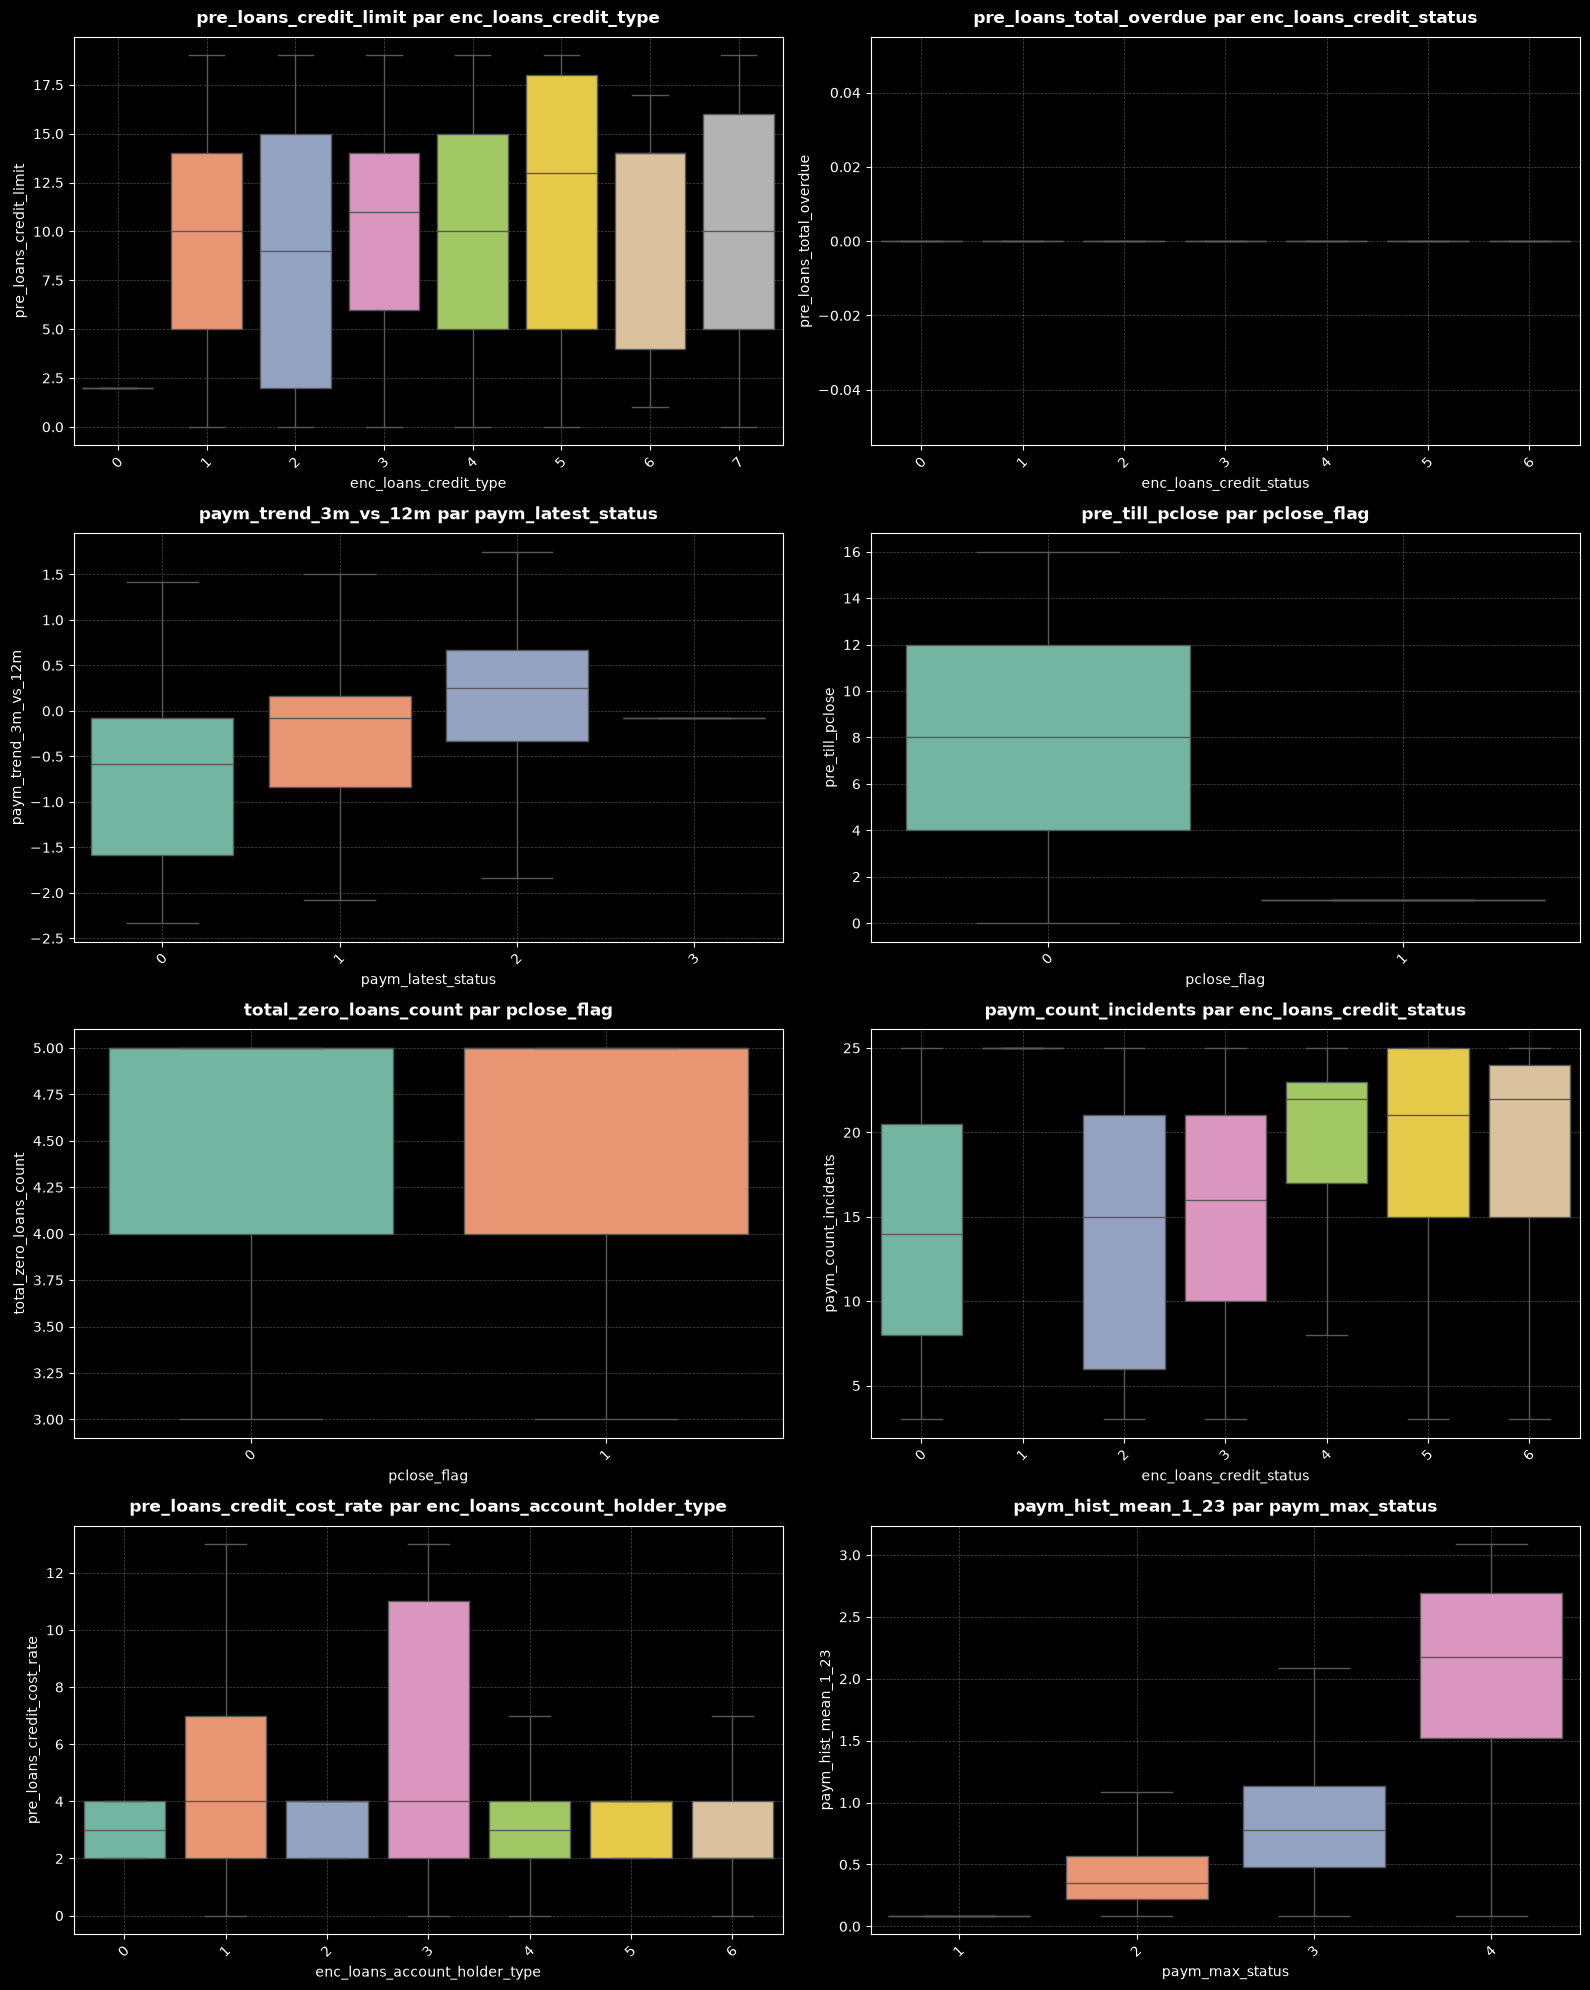

In [82]:
plot_all_cat_num_distributions(new_dataset)

In [86]:
new_dataset.columns

['id',
 'rn',
 'pre_since_opened',
 'pre_since_confirmed',
 'pre_pterm',
 'pre_till_pclose',
 'pre_loans_credit_limit',
 'pre_loans_next_pay_summ',
 'pre_loans_outstanding',
 'pre_loans_total_overdue',
 'pre_loans_max_overdue_sum',
 'pre_loans_credit_cost_rate',
 'pre_loans5',
 'pre_loans530',
 'pre_loans3060',
 'pre_loans6090',
 'pre_loans90',
 'is_zero_loans5',
 'is_zero_loans530',
 'is_zero_loans3060',
 'is_zero_loans6090',
 'is_zero_loans90',
 'pre_util',
 'pre_over2limit',
 'pre_maxover2limit',
 'is_zero_util',
 'is_zero_over2limit',
 'is_zero_maxover2limit',
 'enc_paym_0',
 'enc_paym_1',
 'enc_paym_2',
 'enc_paym_3',
 'enc_paym_4',
 'enc_paym_5',
 'enc_paym_6',
 'enc_paym_7',
 'enc_paym_8',
 'enc_paym_9',
 'enc_paym_10',
 'enc_paym_11',
 'enc_paym_12',
 'enc_paym_13',
 'enc_paym_14',
 'enc_paym_15',
 'enc_paym_16',
 'enc_paym_17',
 'enc_paym_18',
 'enc_paym_19',
 'enc_paym_20',
 'enc_paym_21',
 'enc_paym_22',
 'enc_paym_23',
 'enc_paym_24',
 'enc_loans_account_holder_type',
 'enc

In [87]:
enc_paym = [f"enc_paym_{i}" for i in range(24)]
new_dataset = new_dataset.drop(pl.col(enc_paym))

In [89]:
new_dataset = new_dataset.drop(pl.col("pre_loans_total_overdue"))

In [90]:
is_zero_loan_list = [
    'is_zero_loans5',
 'is_zero_loans530',
 'is_zero_loans3060',
 'is_zero_loans6090',
 'is_zero_loans90'
]

In [91]:
new_dataset = new_dataset.drop(pl.col(is_zero_loan_list))

<Figure size 1000x600 with 0 Axes>

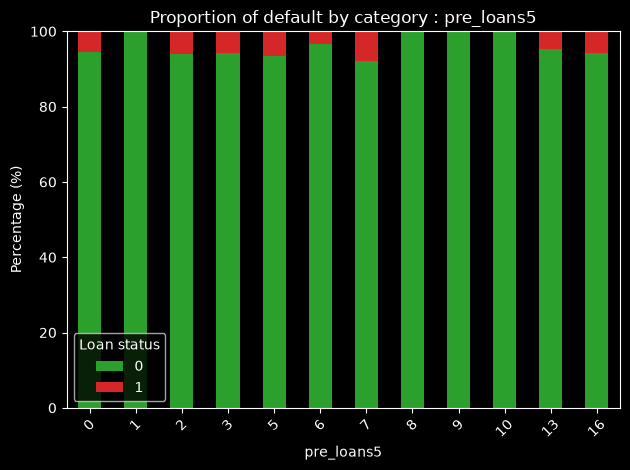

<Figure size 1000x600 with 0 Axes>

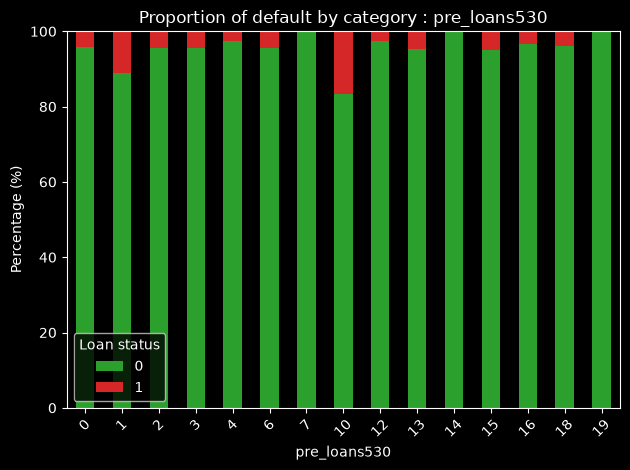

<Figure size 1000x600 with 0 Axes>

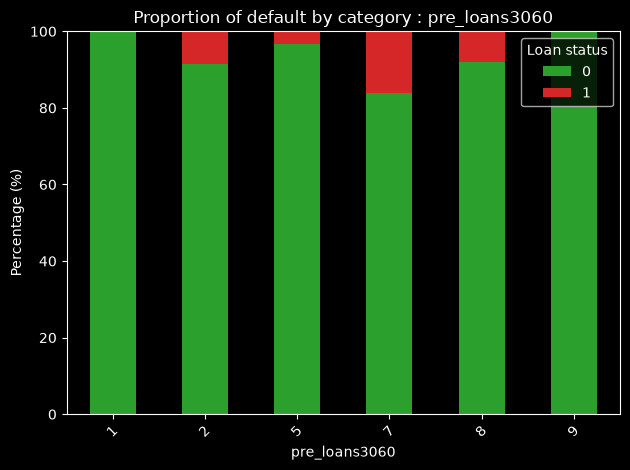

<Figure size 1000x600 with 0 Axes>

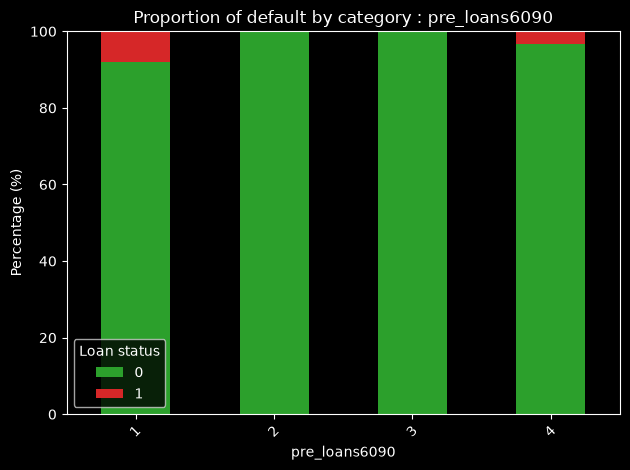

<Figure size 1000x600 with 0 Axes>

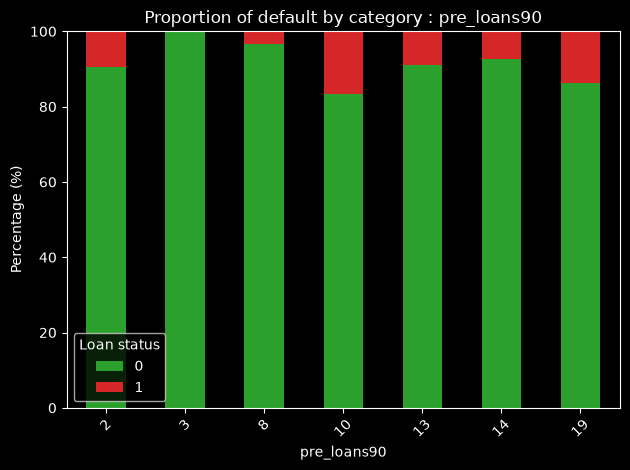

In [88]:
pre_loans_data = ['pre_loans5',
 'pre_loans530',
 'pre_loans3060',
 'pre_loans6090',
 'pre_loans90']

plot_relation_feature_target(df=new_dataset, features=pre_loans_data, categorical=True)

In [92]:
new_dataset = new_dataset.with_columns(
    (
        pl.col("pre_loans5")
        + pl.col("pre_loans530")
        + pl.col("pre_loans3060")
        + pl.col("pre_loans6090")
        + pl.col("pre_loans90")
    ).alias("total_delinquency_score")
)

In [93]:
new_dataset = new_dataset.drop(pl.col(pre_loans_data))

In [96]:
numerical_features.append("total_delinquency_score")

### Outliers visualization

In [99]:
def plot_outliers(df: pl.DataFrame, features: list):
    for feature in features:
        if feature not in df.columns:
            continue

        feature_data = df[feature].to_pandas()

        plt.figure(figsize=(8, 4))
        sb.boxplot(y=feature_data, color="skyblue")

        plt.title(f"Distribution & Outliers : {feature}", fontsize=12)
        plt.ylabel(feature)
        plt.grid(True, linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

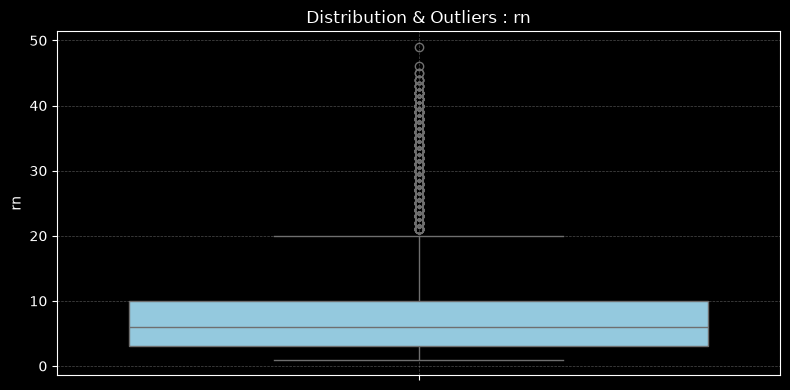

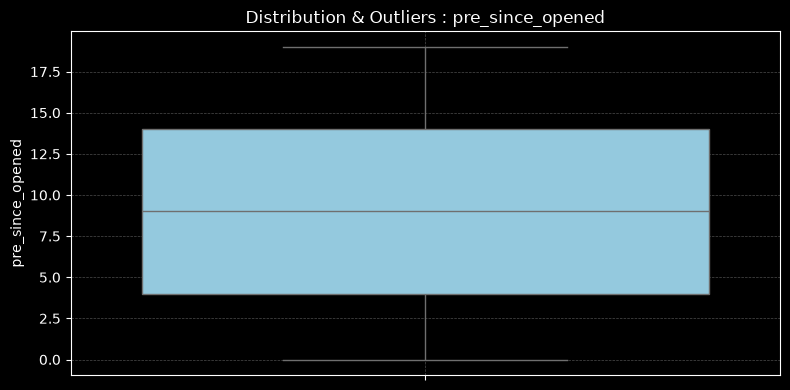

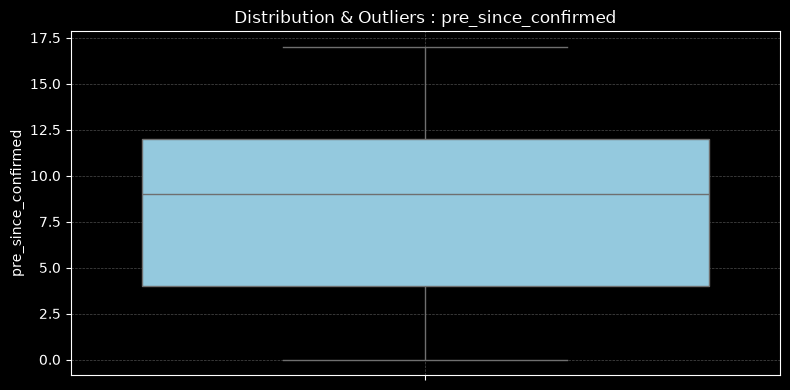

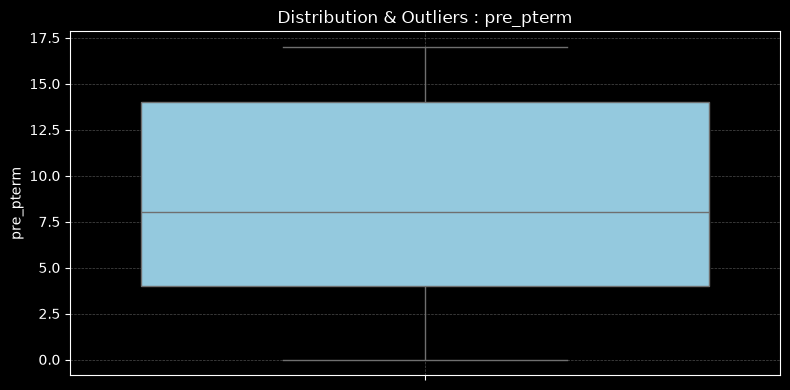

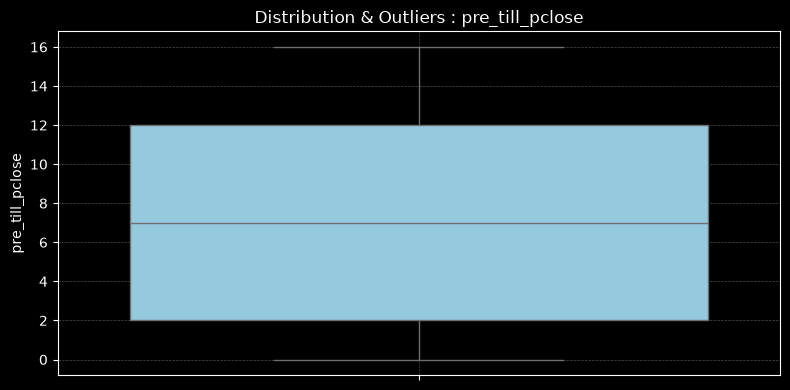

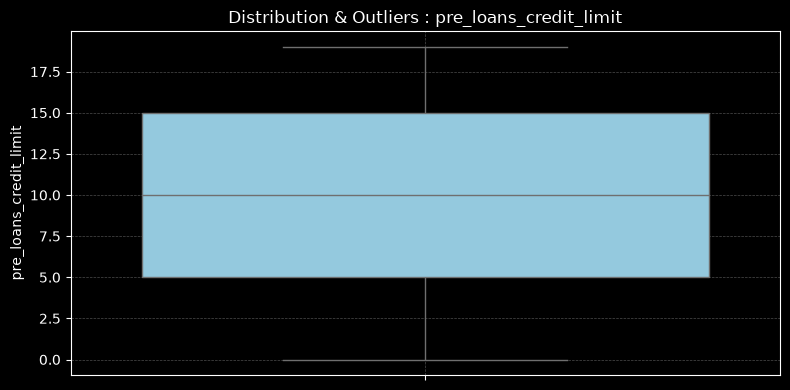

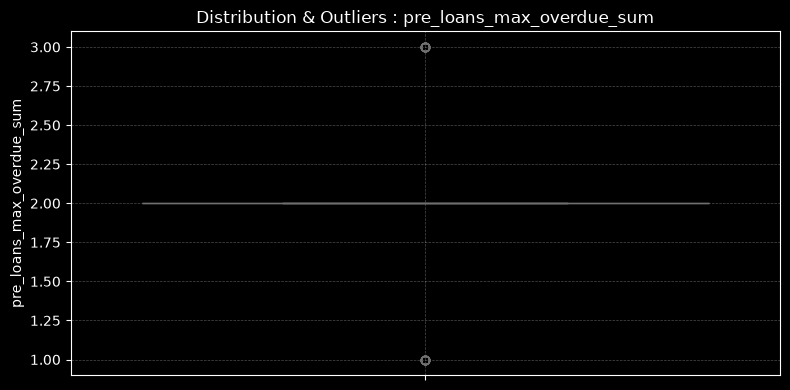

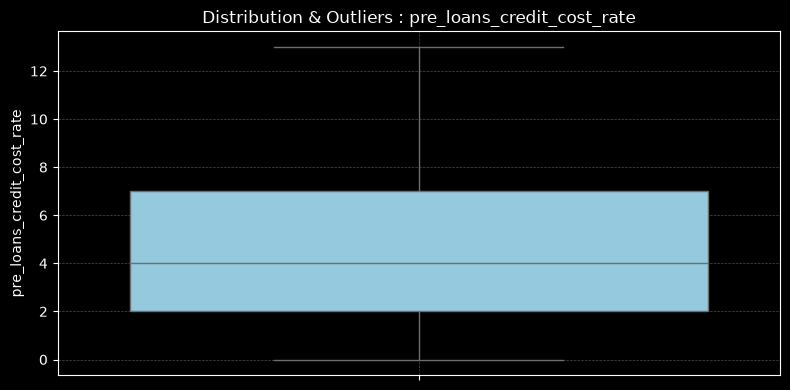

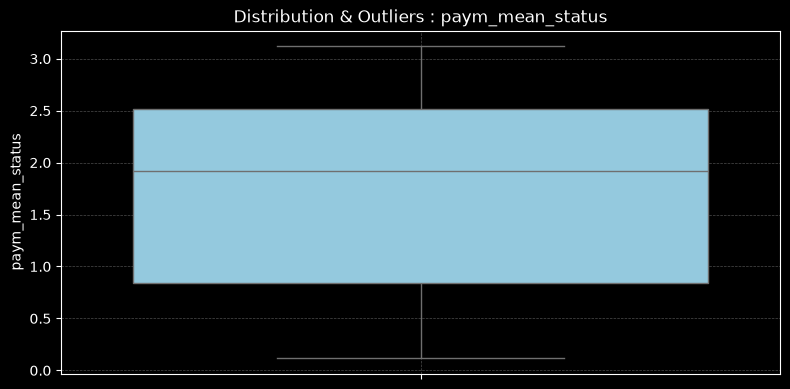

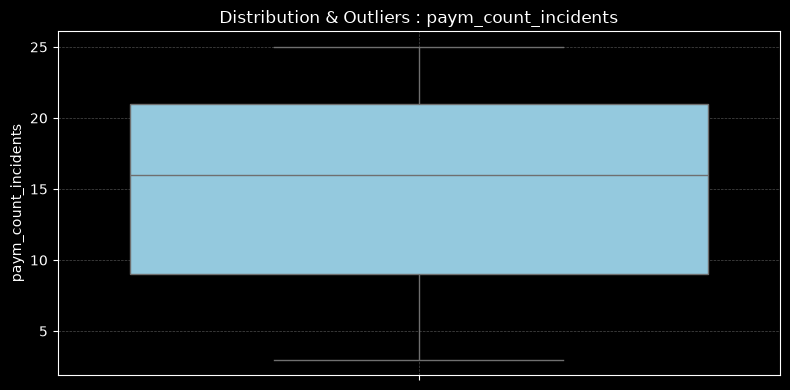

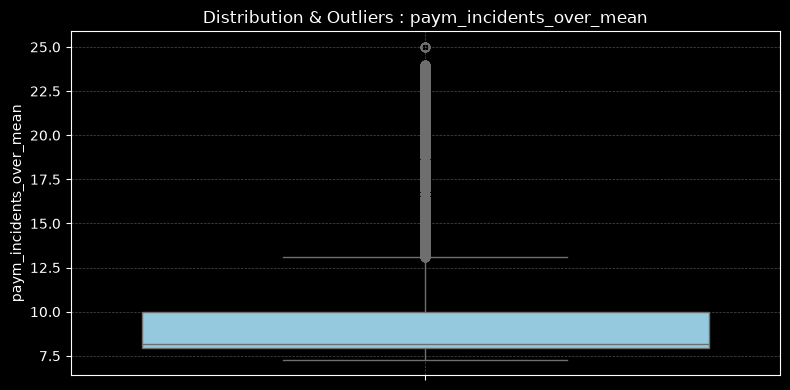

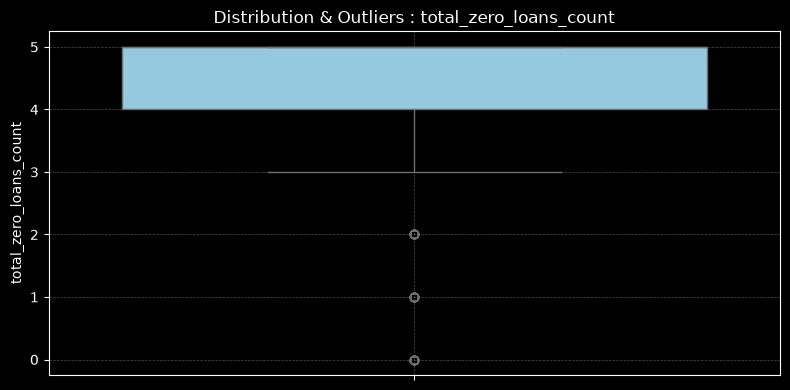

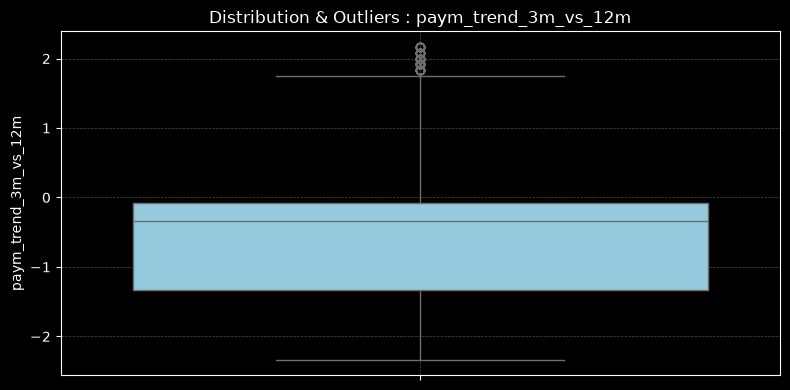

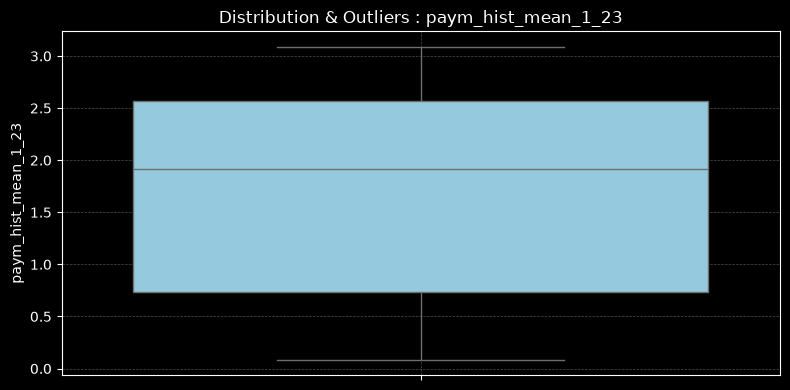

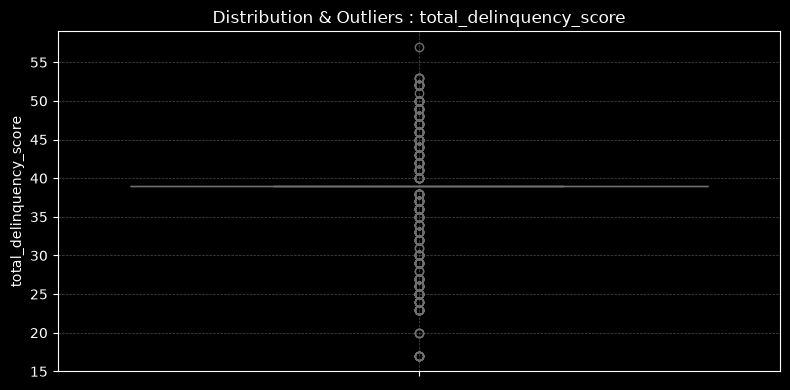

In [100]:
plot_outliers(df=new_dataset, features=numerical_features)

In [106]:
# numerical_features.remove("pre_loans_max_overdue_sum")
numerical_features.remove("pre_loans_next_pay_summ")
numerical_features.remove("pre_loans_oustanding")

ValueError: list.remove(x): x not in list

In [105]:
numerical_features

['rn',
 'pre_since_opened',
 'pre_since_confirmed',
 'pre_pterm',
 'pre_till_pclose',
 'pre_loans_credit_limit',
 'pre_loans_credit_cost_rate',
 'paym_mean_status',
 'paym_count_incidents',
 'paym_incidents_over_mean',
 'total_zero_loans_count',
 'paym_trend_3m_vs_12m',
 'paym_hist_mean_1_23',
 'total_delinquency_score']

In [107]:
categorical_features.extend(["pre_loans_max_overdue_sum", "pre_loans_next_pay_summ", "pre_loans_oustanding"])

#### HYPOTHESIS